## Задача 1: предсказание уровня удовлетворённости сотрудника

**Оприсание задачи**

**Цель 1** — построить модель, которая сможет предсказать уровень удовлетворённости сотрудника на основе данных заказчика.

**Цель 2** — построить модель, которая сможет на основе данных заказчика предсказать то, что сотрудник уволится из компании.

**Описание данных**

id — уникальный идентификатор сотрудника;

dept — отдел, в котором работает сотрудник;

level — уровень занимаемой должности;

workload — уровень загруженности сотрудника;

employment_years — длительность работы в компании (в годах);

last_year_promo — показывает, было ли повышение за последний год;

last_year_violations — показывает, нарушал ли сотрудник трудовой договор за последний год;

supervisor_evaluation — оценка качества работы сотрудника, которую дал руководитель;

salary — ежемесячная зарплата сотрудника;

job_satisfaction_rate — уровень удовлетворённости сотрудника работой в компании, целевой признак.

In [1]:
!pip install phik

In [2]:
!pip install scikit-learn -U

In [3]:
# Импорт
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sn
import phik
import seaborn as sns
from phik.report import plot_correlation_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint, uniform
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder,
                                  StandardScaler, PowerTransformer)
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report


from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import get_scorer

from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.metrics import make_scorer
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import copy

### Загрузка данных

In [4]:
train_job_satisfaction_rate = pd.read_csv('https://code.s3.yandex.net/datasets/train_job_satisfaction_rate.csv', index_col=0)
train_job_satisfaction_rate.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76


In [5]:
test_features = pd.read_csv('https://code.s3.yandex.net/datasets/test_features.csv', index_col=0)
test_features.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000


In [6]:
test_target_job_satisfaction_rate= pd.read_csv('https://code.s3.yandex.net/datasets/test_target_job_satisfaction_rate.csv', index_col=0)
test_target_job_satisfaction_rate.head(2)

,job_satisfaction_rate
id,
130604,0.74
825977,0.75


### Предобработка данных

#### Предобработка данных train_job_satisfaction_rate

In [7]:
# Поиск явных дубликатов
train_job_satisfaction_rate.duplicated().sum()

245

In [8]:
# Поиск не явных дубликатов
train_job_satisfaction_rate['dept'].unique()

array(['sales', 'hr', 'technology', 'purchasing', 'marketing', nan],
      dtype=object)

In [9]:
# Поиск не явных дубликатов
train_job_satisfaction_rate['level'].unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [10]:
train_job_satisfaction_rate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 155278 to 338347
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dept                   3994 non-null   object 
 1   level                  3996 non-null   object 
 2   workload               4000 non-null   object 
 3   employment_years       4000 non-null   int64  
 4   last_year_promo        4000 non-null   object 
 5   last_year_violations   4000 non-null   object 
 6   supervisor_evaluation  4000 non-null   int64  
 7   salary                 4000 non-null   int64  
 8   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 312.5+ KB


In [11]:
train_job_satisfaction_rate[train_job_satisfaction_rate['level'].isna()].sum()


dept                      salessalessalessales
level                                        0
workload                 mediumlowmediummedium
employment_years                             4
last_year_promo                       nononono
last_year_violations                  nononono
supervisor_evaluation                       17
salary                                   99600
job_satisfaction_rate                      2.4
dtype: object

In [12]:
# Проверяем, есть ли строковые 'nan'
print("Строковые 'nan':", train_job_satisfaction_rate['dept'].eq('nan').any())
print("Строковые 'nan':", train_job_satisfaction_rate['level'].eq('nan').any())

# Проверяем настоящие пропуски
print("Настоящие пропуски:", train_job_satisfaction_rate['dept'].isna().any())
print("Настоящие пропуски:", train_job_satisfaction_rate['level'].isna().any())

Строковые 'nan': False
Строковые 'nan': False
Настоящие пропуски: True
Настоящие пропуски: True


In [13]:
# Поиск не явных дубликатов
train_job_satisfaction_rate['workload'].unique()

array(['medium', 'high', 'low'], dtype=object)

In [14]:
train_job_satisfaction_rate['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [15]:
train_job_satisfaction_rate['last_year_violations'].unique()

array(['no', 'yes'], dtype=object)

In [16]:
# Поиск пропусков
display(train_job_satisfaction_rate.isna().sum())

dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64

In [17]:
train_job_satisfaction_rate.shape[0]

4000

**В датафрэйм 10 пропусков относительно 4000 строк. Займемся ими далее - или удалим, или заменим наиболее часто встречающимися значениями.**

In [18]:
train_job_satisfaction_rate.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76


In [19]:
# Общая информация о датасете
train_job_satisfaction_rate.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 155278 to 338347
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dept                   3994 non-null   object 
 1   level                  3996 non-null   object 
 2   workload               4000 non-null   object 
 3   employment_years       4000 non-null   int64  
 4   last_year_promo        4000 non-null   object 
 5   last_year_violations   4000 non-null   object 
 6   supervisor_evaluation  4000 non-null   int64  
 7   salary                 4000 non-null   int64  
 8   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(3), object(5)
memory usage: 312.5+ KB


In [20]:
train_1 = train_job_satisfaction_rate.copy()
train_1.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20


In [21]:
train_1['dept'].unique()

array(['sales', 'hr', 'technology', 'purchasing', 'marketing', nan],
      dtype=object)

In [22]:
train_1['workload'].unique()

array(['medium', 'high', 'low'], dtype=object)

In [23]:
train_1.loc[train_1['level'] == 'sinior', 'level'] = 'senior'
train_1.head(10)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76
184592,sales,junior,low,1,no,no,2,12000,0.11
171431,technology,junior,low,4,no,no,2,18000,0.37
693419,hr,junior,medium,1,no,no,3,22800,0.20
405448,hr,middle,low,7,no,no,4,30000,0.78
857135,sales,senior,medium,9,no,no,3,56400,0.56
400657,purchasing,middle,high,9,no,no,3,52800,0.44
198846,hr,junior,low,1,no,no,2,13200,0.14


In [24]:
display(train_1.isna().sum())

dept                     6
level                    4
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
dtype: int64

**Вывод по предобработке train_job_satisfaction_rate**
- дубликаты явные и неявные отсутствуют
- пропусков 10. пока знаем о них и обработаем или здесь, или заменим наиболее частыми значениями далее.
- типы данных соответстуют отображаемым в таблице.
- оформление соответствует змеиному языку.
- опечатки исправлены.

#### Предобработка данных test_features

In [25]:
test_features.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000


In [26]:
X_test_1 = test_features

In [27]:
# Поиск не явных дубликатов
X_test_1['dept'].unique()

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan, ' '],
      dtype=object)

In [28]:
# Поиск не явных дубликатов
X_test_1['level'].unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [29]:
X_test_1[X_test_1['level'].isna()].sum()

dept                     sales
level                        0
workload                   low
employment_years             1
last_year_promo             no
last_year_violations        no
supervisor_evaluation        3
salary                   12000
dtype: object

In [30]:
X_test_1['workload'].unique()

array(['medium', 'low', 'high', ' '], dtype=object)

In [31]:
display(X_test_1.isna().sum())


dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

In [32]:
X_test_1.shape[0]


2000

In [33]:
# Общая информация о датасете
X_test_1.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 485046 to 771859
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   1998 non-null   object
 1   level                  1999 non-null   object
 2   workload               2000 non-null   object
 3   employment_years       2000 non-null   int64 
 4   last_year_promo        2000 non-null   object
 5   last_year_violations   2000 non-null   object
 6   supervisor_evaluation  2000 non-null   int64 
 7   salary                 2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 140.6+ KB


In [34]:
X_test_1.loc[X_test_1['dept'] == ' ', 'dept'] = np.nan
X_test_1.loc[X_test_1['workload'] == ' ', 'workload'] = np.nan
X_test_1.loc[X_test_1['level'] == 'sinior', 'level'] = 'senior'
X_test_1.head(10)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000
467458,sales,middle,low,5,no,no,4,19200
418655,sales,middle,low,6,no,no,4,19200
789145,hr,middle,medium,5,no,no,5,40800
429973,purchasing,middle,medium,6,no,no,3,42000
850699,technology,junior,medium,3,no,no,3,26400
500791,sales,middle,high,9,no,no,4,49200
767867,marketing,middle,high,3,no,yes,4,62400


In [35]:
display(X_test_1.isna().sum())

dept                     3
level                    1
workload                 1
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

**Вывод по предобработке test_features**
- дубликаты явные и неявные отсутствуют
- пропусков 5. пока знаем о них и обработаем или здесь, или заменим наиболее частыми значениями далее.
- типы данных соответстуют отображаемым в таблице.
- оформление соответствует змеиному языку.
- опечатки исправлены.

#### Предобработка данных test_target_job_satisfaction_rate

In [36]:
y_test_1 = test_target_job_satisfaction_rate
y_test_1.head()

,job_satisfaction_rate
id,
130604,0.74
825977,0.75
418490,0.60
555320,0.72
826430,0.08


In [37]:
# Поиск явных дубликатов
y_test_1.duplicated().sum()

1902

In [38]:
y_test_1[y_test_1['job_satisfaction_rate'].isna()].sum()


job_satisfaction_rate    0.0
dtype: float64

In [39]:
y_test_1.shape[0]


2000

In [40]:
# Общая информация о датасете
y_test_1.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 130604 to 648995
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   job_satisfaction_rate  2000 non-null   float64
dtypes: float64(1)
memory usage: 31.2 KB


In [41]:
y_test_1.head(2)

,job_satisfaction_rate
id,
130604,0.74
825977,0.75


**Вывод по предобработке test_target_job_satisfaction_rate**
- дубликаты явные и неявные отсутствуют
- пропусков нет.
- типы данных соответстуют отображаемым в таблице.
- оформление соответствует змеиному языку.
- опечатки отсутствуют.

In [42]:
#Выведем результат предобработки данных
train_1.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76


In [43]:
#Выведем результат предобработки данных
X_test_1.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000


In [44]:
#Выведем результат предобработки данных
y_test_1.head()

,job_satisfaction_rate
id,
130604,0.74
825977,0.75
418490,0.60
555320,0.72
826430,0.08


**Вывод по предобработке данных во всех датасетах**
- дубликаты явные и неявные отсутствуют
- пропусков 10+5. пока знаем о них и обработаем или здесь, или заменим наиболее частыми значениями далее.
- типы данных соответстуют отображаемым в таблице.
- оформление соответствует змеиному языку.
- опечатки исправлены.

### Исследовательский анализ данных

In [45]:
train_1.describe().round(2)

,employment_years,supervisor_evaluation,salary,job_satisfaction_rate
count,4000.00,4000.00,4000.0,4000.00
mean,3.72,3.48,33926.7,0.53
std,2.54,1.01,14900.7,0.23
min,1.00,1.00,12000.0,0.03
25%,2.00,3.00,22800.0,0.36
50%,3.00,4.00,30000.0,0.56
75%,6.00,4.00,43200.0,0.71
max,10.00,5.00,98400.0,1.00


In [46]:
X_test_1.describe()

,employment_years,supervisor_evaluation,salary
count,2000.000000,2000.000000,2000.000000
mean,3.666500,3.526500,34066.800000
std,2.537222,0.996892,15398.436729
min,1.000000,1.000000,12000.000000
25%,1.000000,3.000000,22800.000000
50%,3.000000,4.000000,30000.000000
75%,6.000000,4.000000,43200.000000
max,10.000000,5.000000,96000.000000


In [47]:
y_test_1.head(2)

,job_satisfaction_rate
id,
130604,0.74
825977,0.75


In [48]:
train_1.head(1)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58


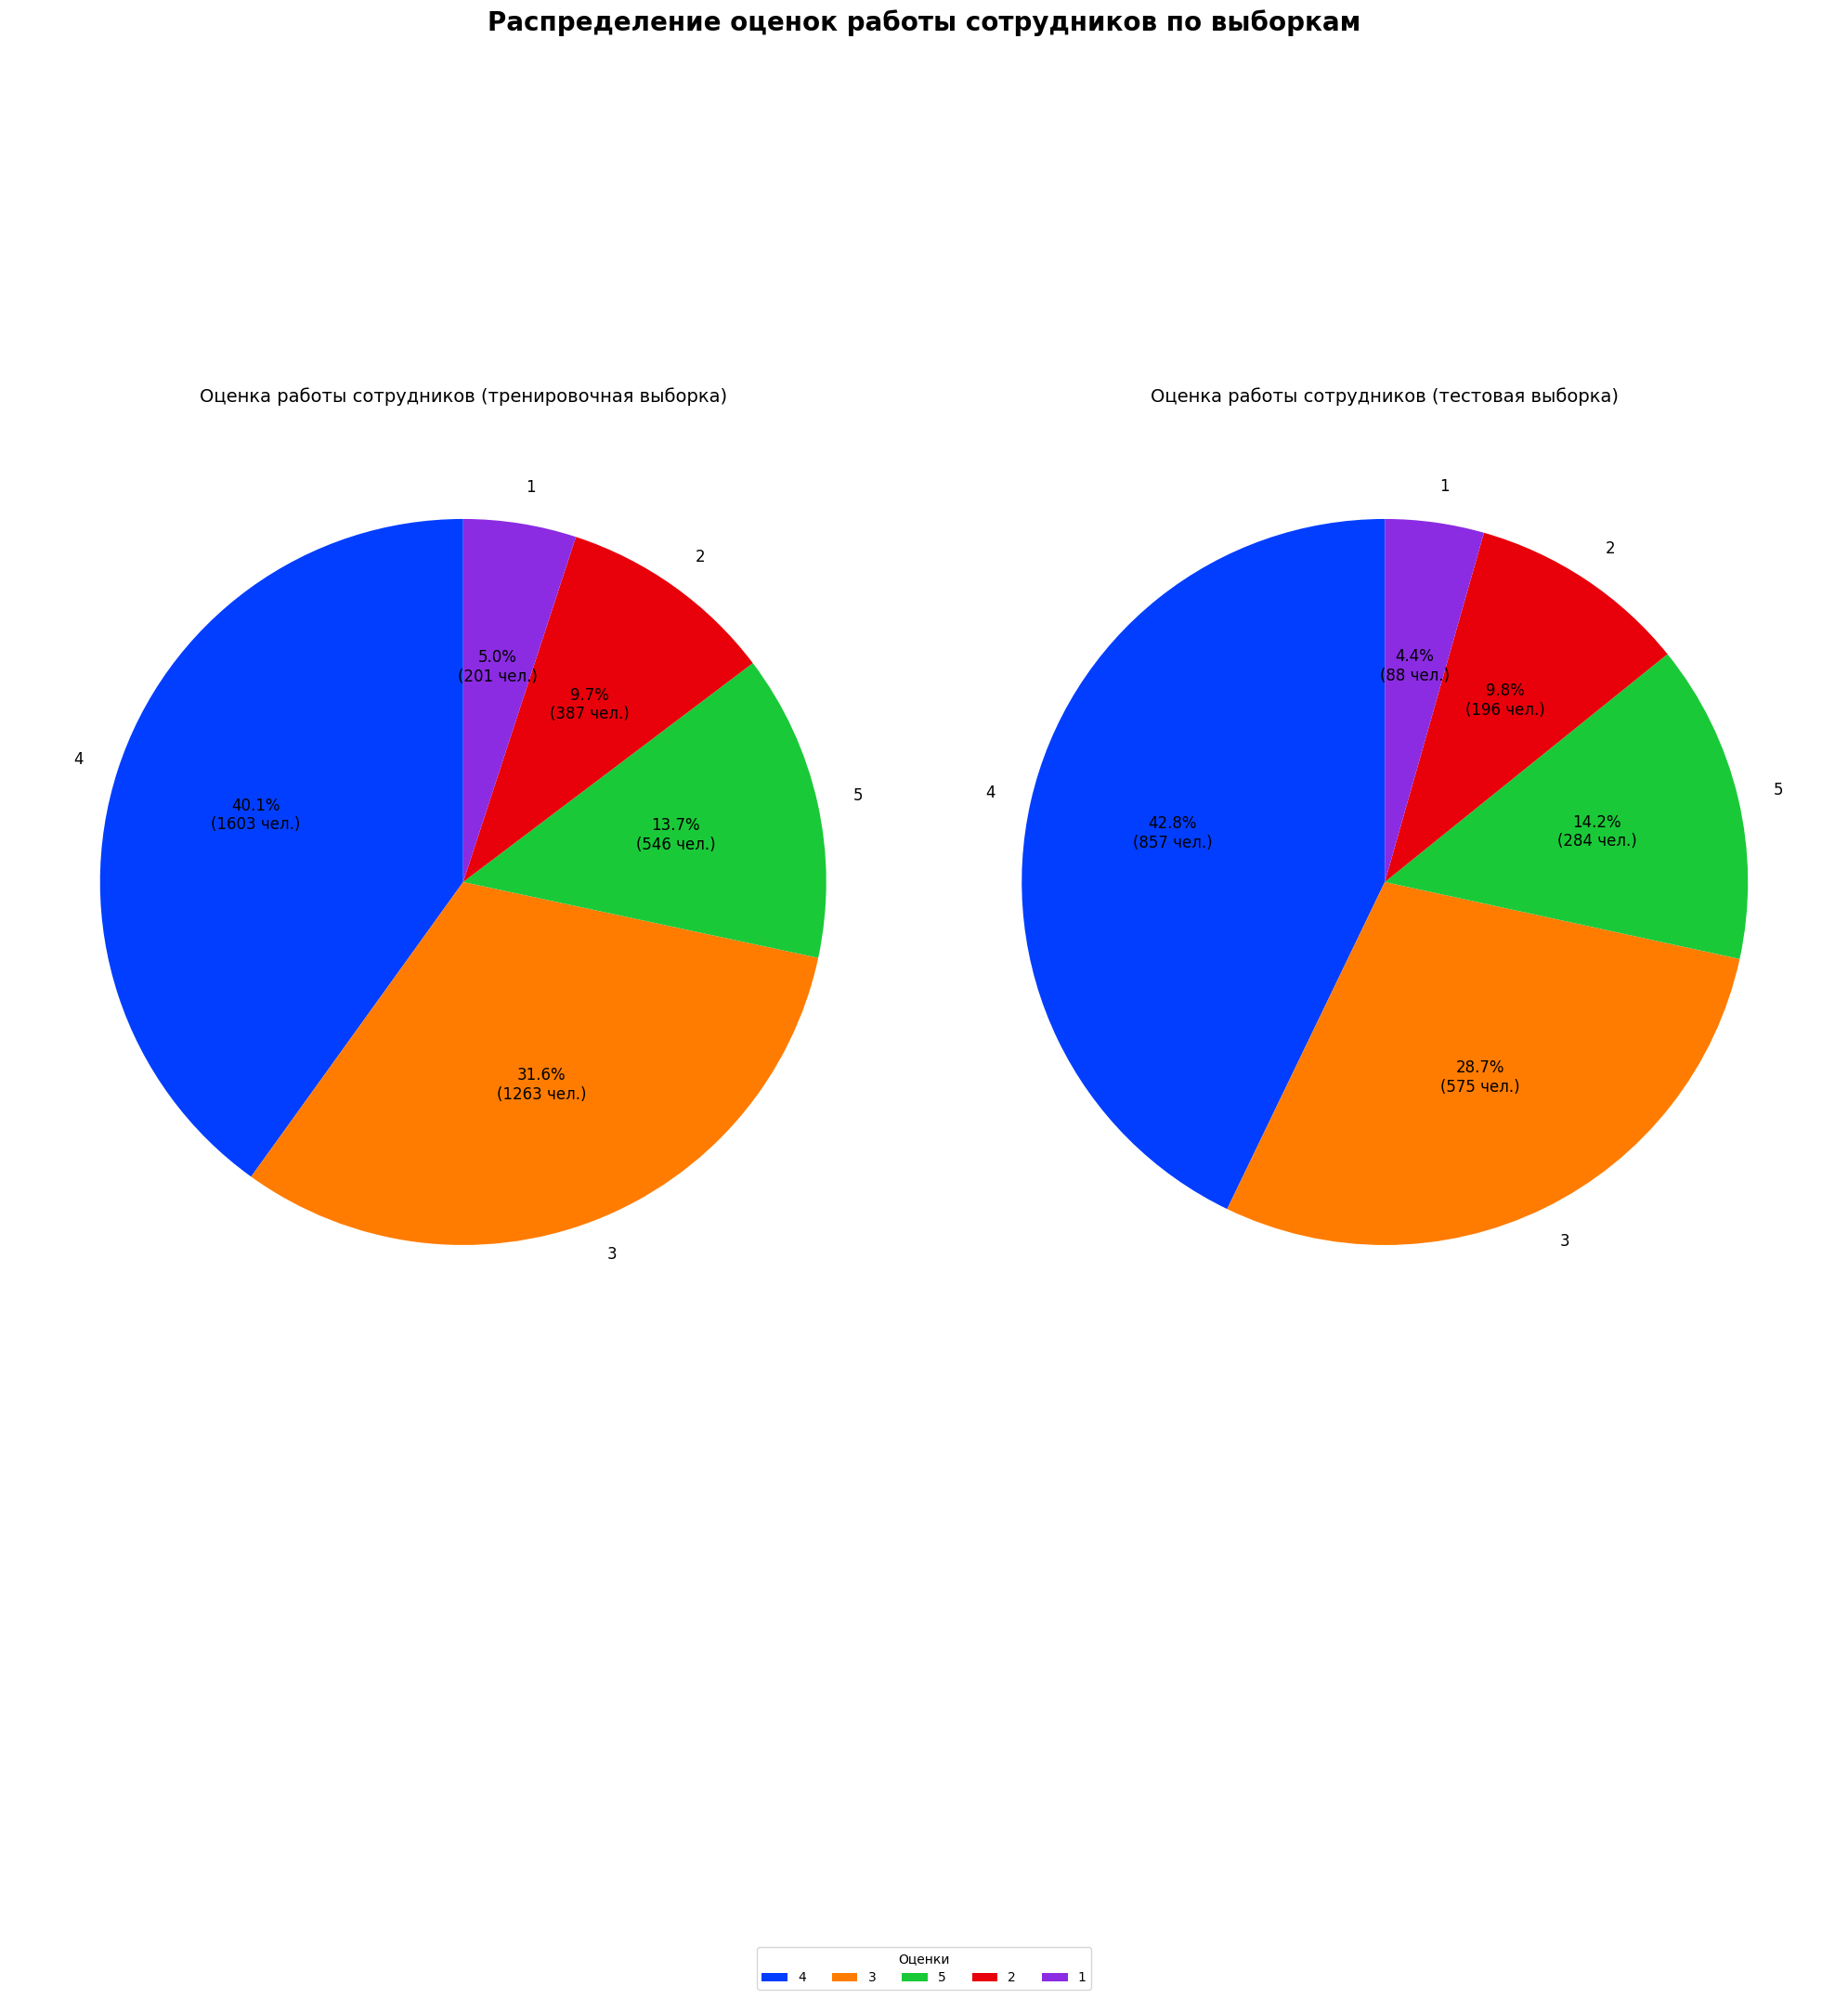

In [49]:
# Создаем фигуру с двумя subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 20))

# Цветовая палитра
palette_color = sns.color_palette('bright')

# Первая диаграмма (тренировочные данные)
train_counts = train_1['supervisor_evaluation'].value_counts()
ax1.pie(train_counts,
        labels=train_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(train_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax1.set_title('Оценка работы сотрудников (тренировочная выборка)', pad=20, fontsize=14)

# Вторая диаграмма (тестовая выборка)
test_counts = X_test_1['supervisor_evaluation'].value_counts()
ax2.pie(test_counts,
        labels=test_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(test_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax2.set_title('Оценка работы сотрудников (тестовая выборка)', pad=20, fontsize=14)

# Общий заголовок
plt.suptitle('Распределение оценок работы сотрудников по выборкам', y=1.02, fontsize=20, weight='bold')

# Добавляем легенду
fig.legend(train_counts.index,
           title='Оценки',
           loc='lower center',
           ncol=len(train_counts),
           bbox_to_anchor=(0.5, -0.05))

# Настройка отступов
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.25)
plt.show()


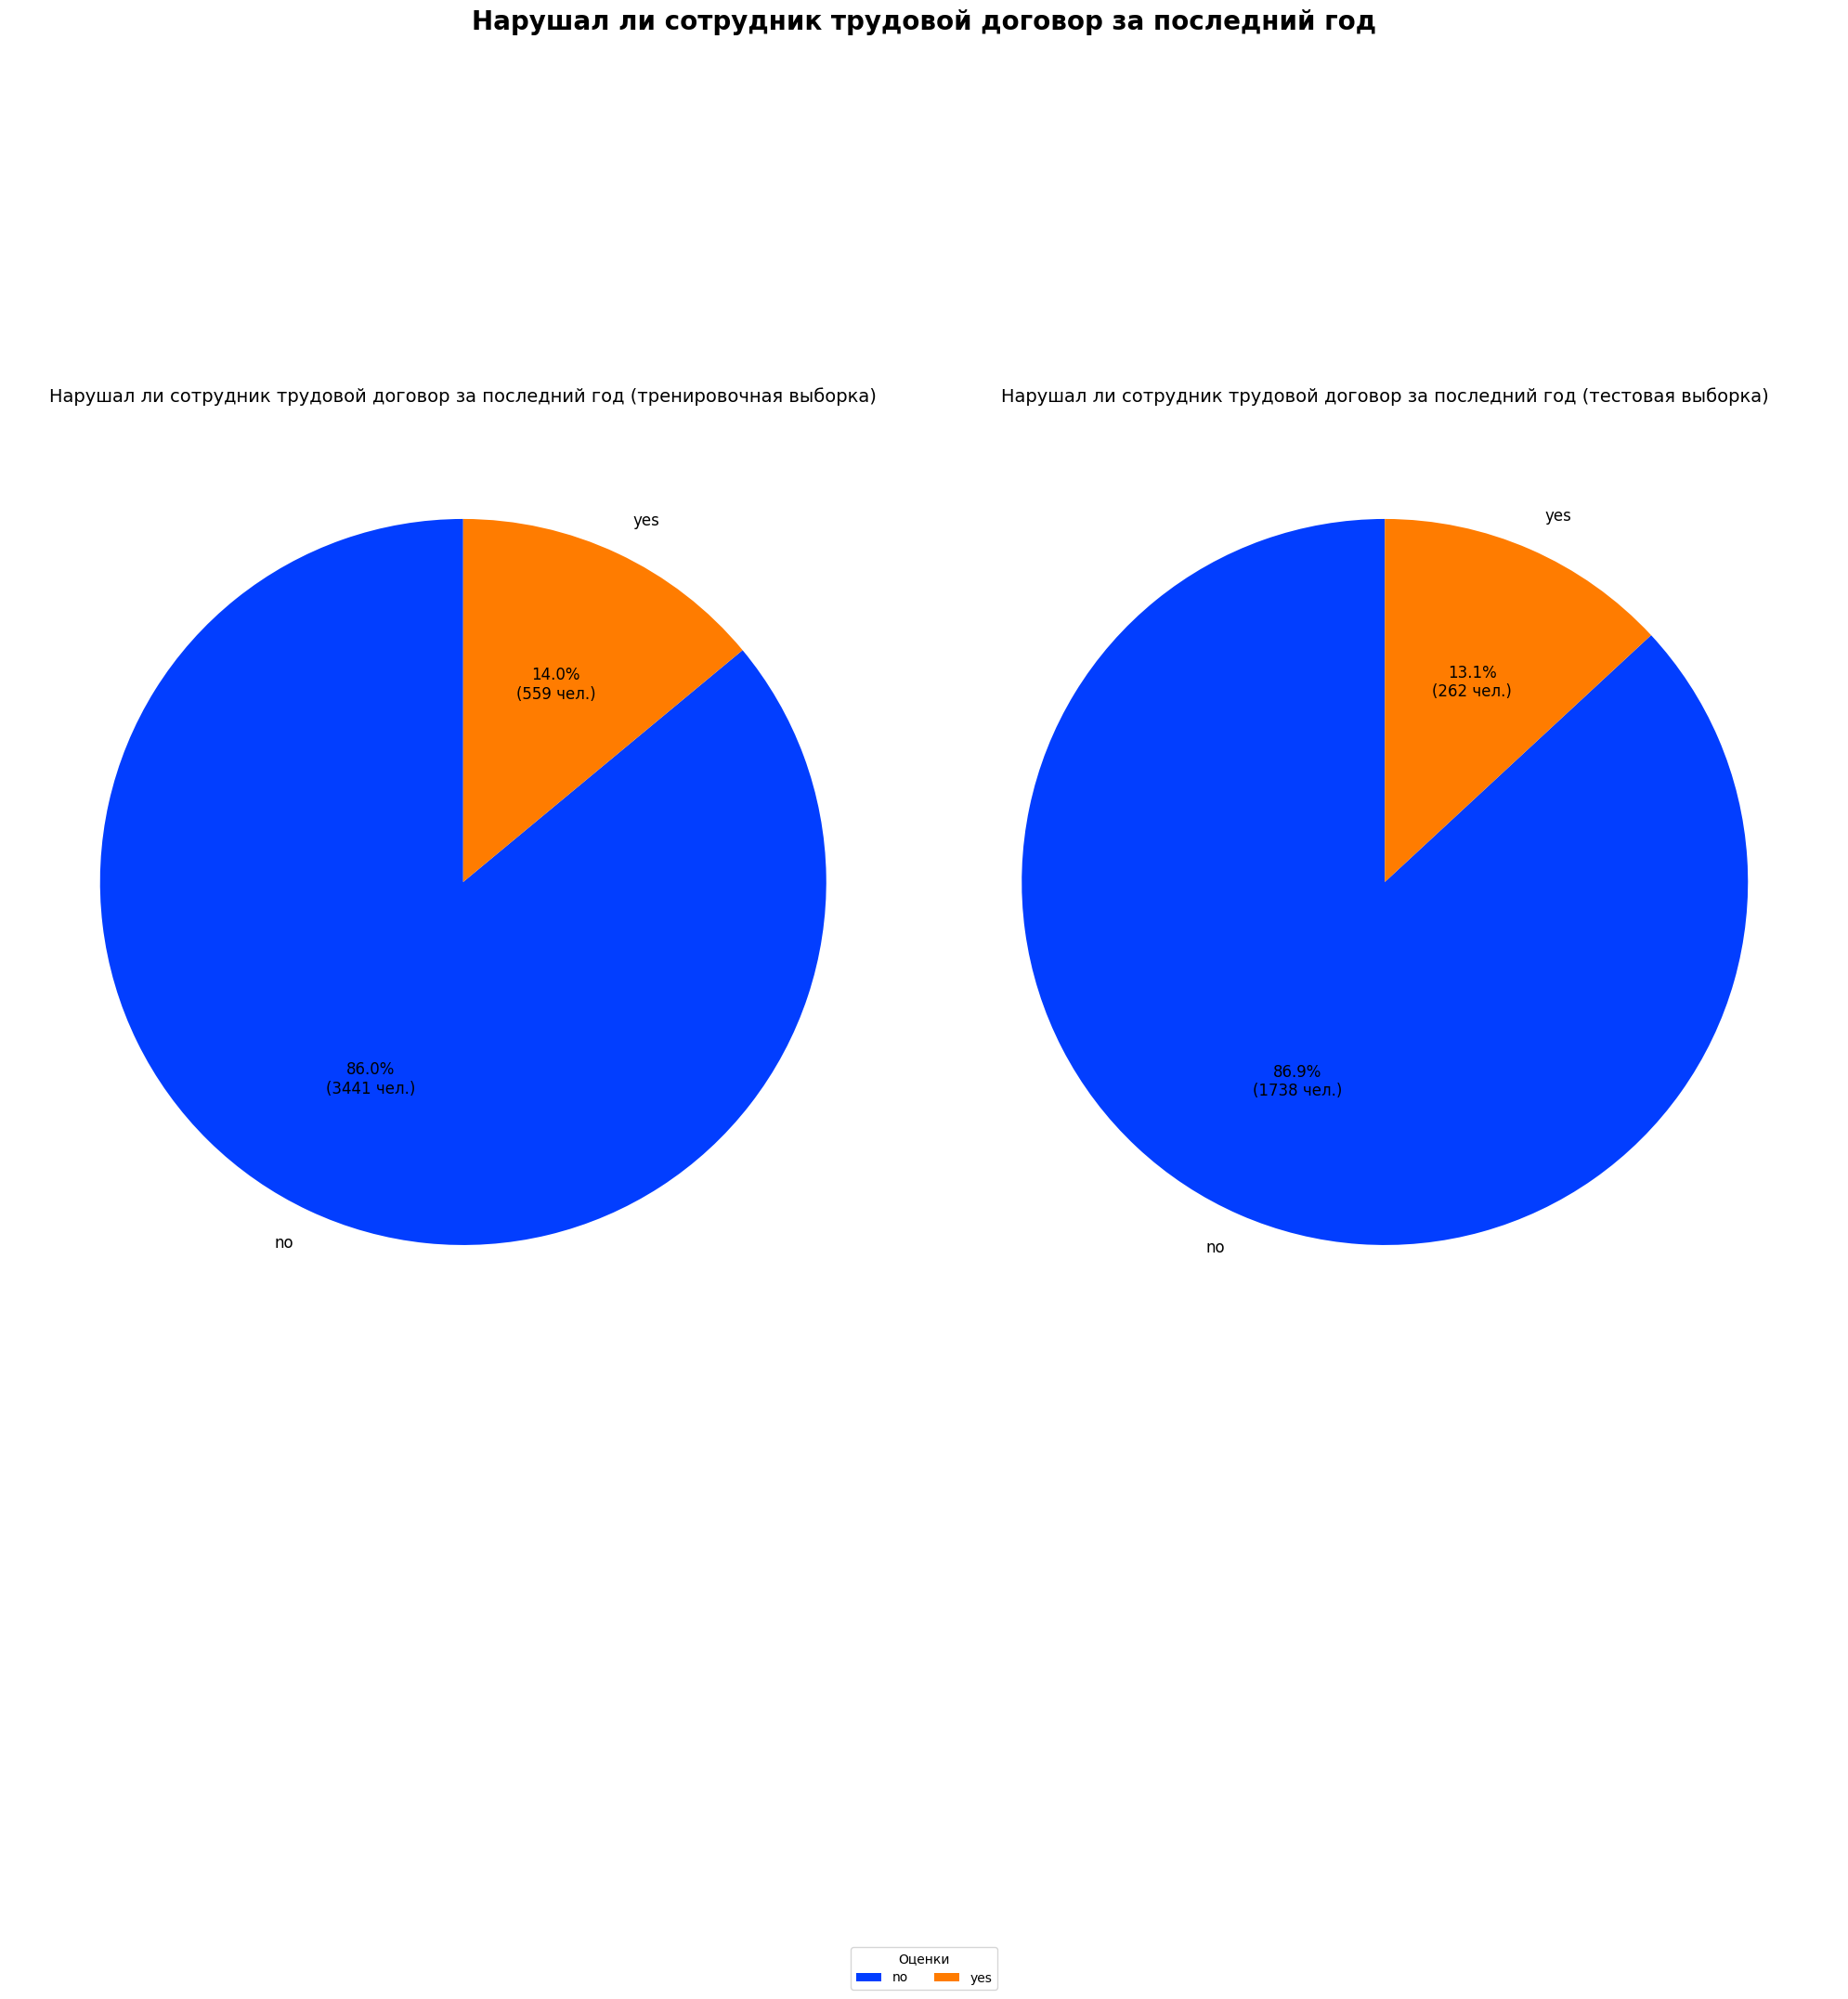

In [50]:

# Создаем фигуру с двумя subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 20))

# Цветовая палитра
palette_color = sns.color_palette('bright')

# Первая диаграмма (тренировочные данные)
train_counts = train_1['last_year_violations'].value_counts()
ax1.pie(train_counts,
        labels=train_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(train_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax1.set_title('Нарушал ли сотрудник трудовой договор за последний год (тренировочная выборка)', pad=20, fontsize=14)

# Вторая диаграмма (тестовая выборка)
test_counts = X_test_1['last_year_violations'].value_counts()
ax2.pie(test_counts,
        labels=test_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(test_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax2.set_title('Нарушал ли сотрудник трудовой договор за последний год (тестовая выборка)', pad=20, fontsize=14)

# Общий заголовок
plt.suptitle('Нарушал ли сотрудник трудовой договор за последний год', y=1.02, fontsize=20, weight='bold')

# Добавляем легенду
fig.legend(train_counts.index,
           title='Оценки',
           loc='lower center',
           ncol=len(train_counts),
           bbox_to_anchor=(0.5, -0.05))

# Настройка отступов
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.25)
plt.show()


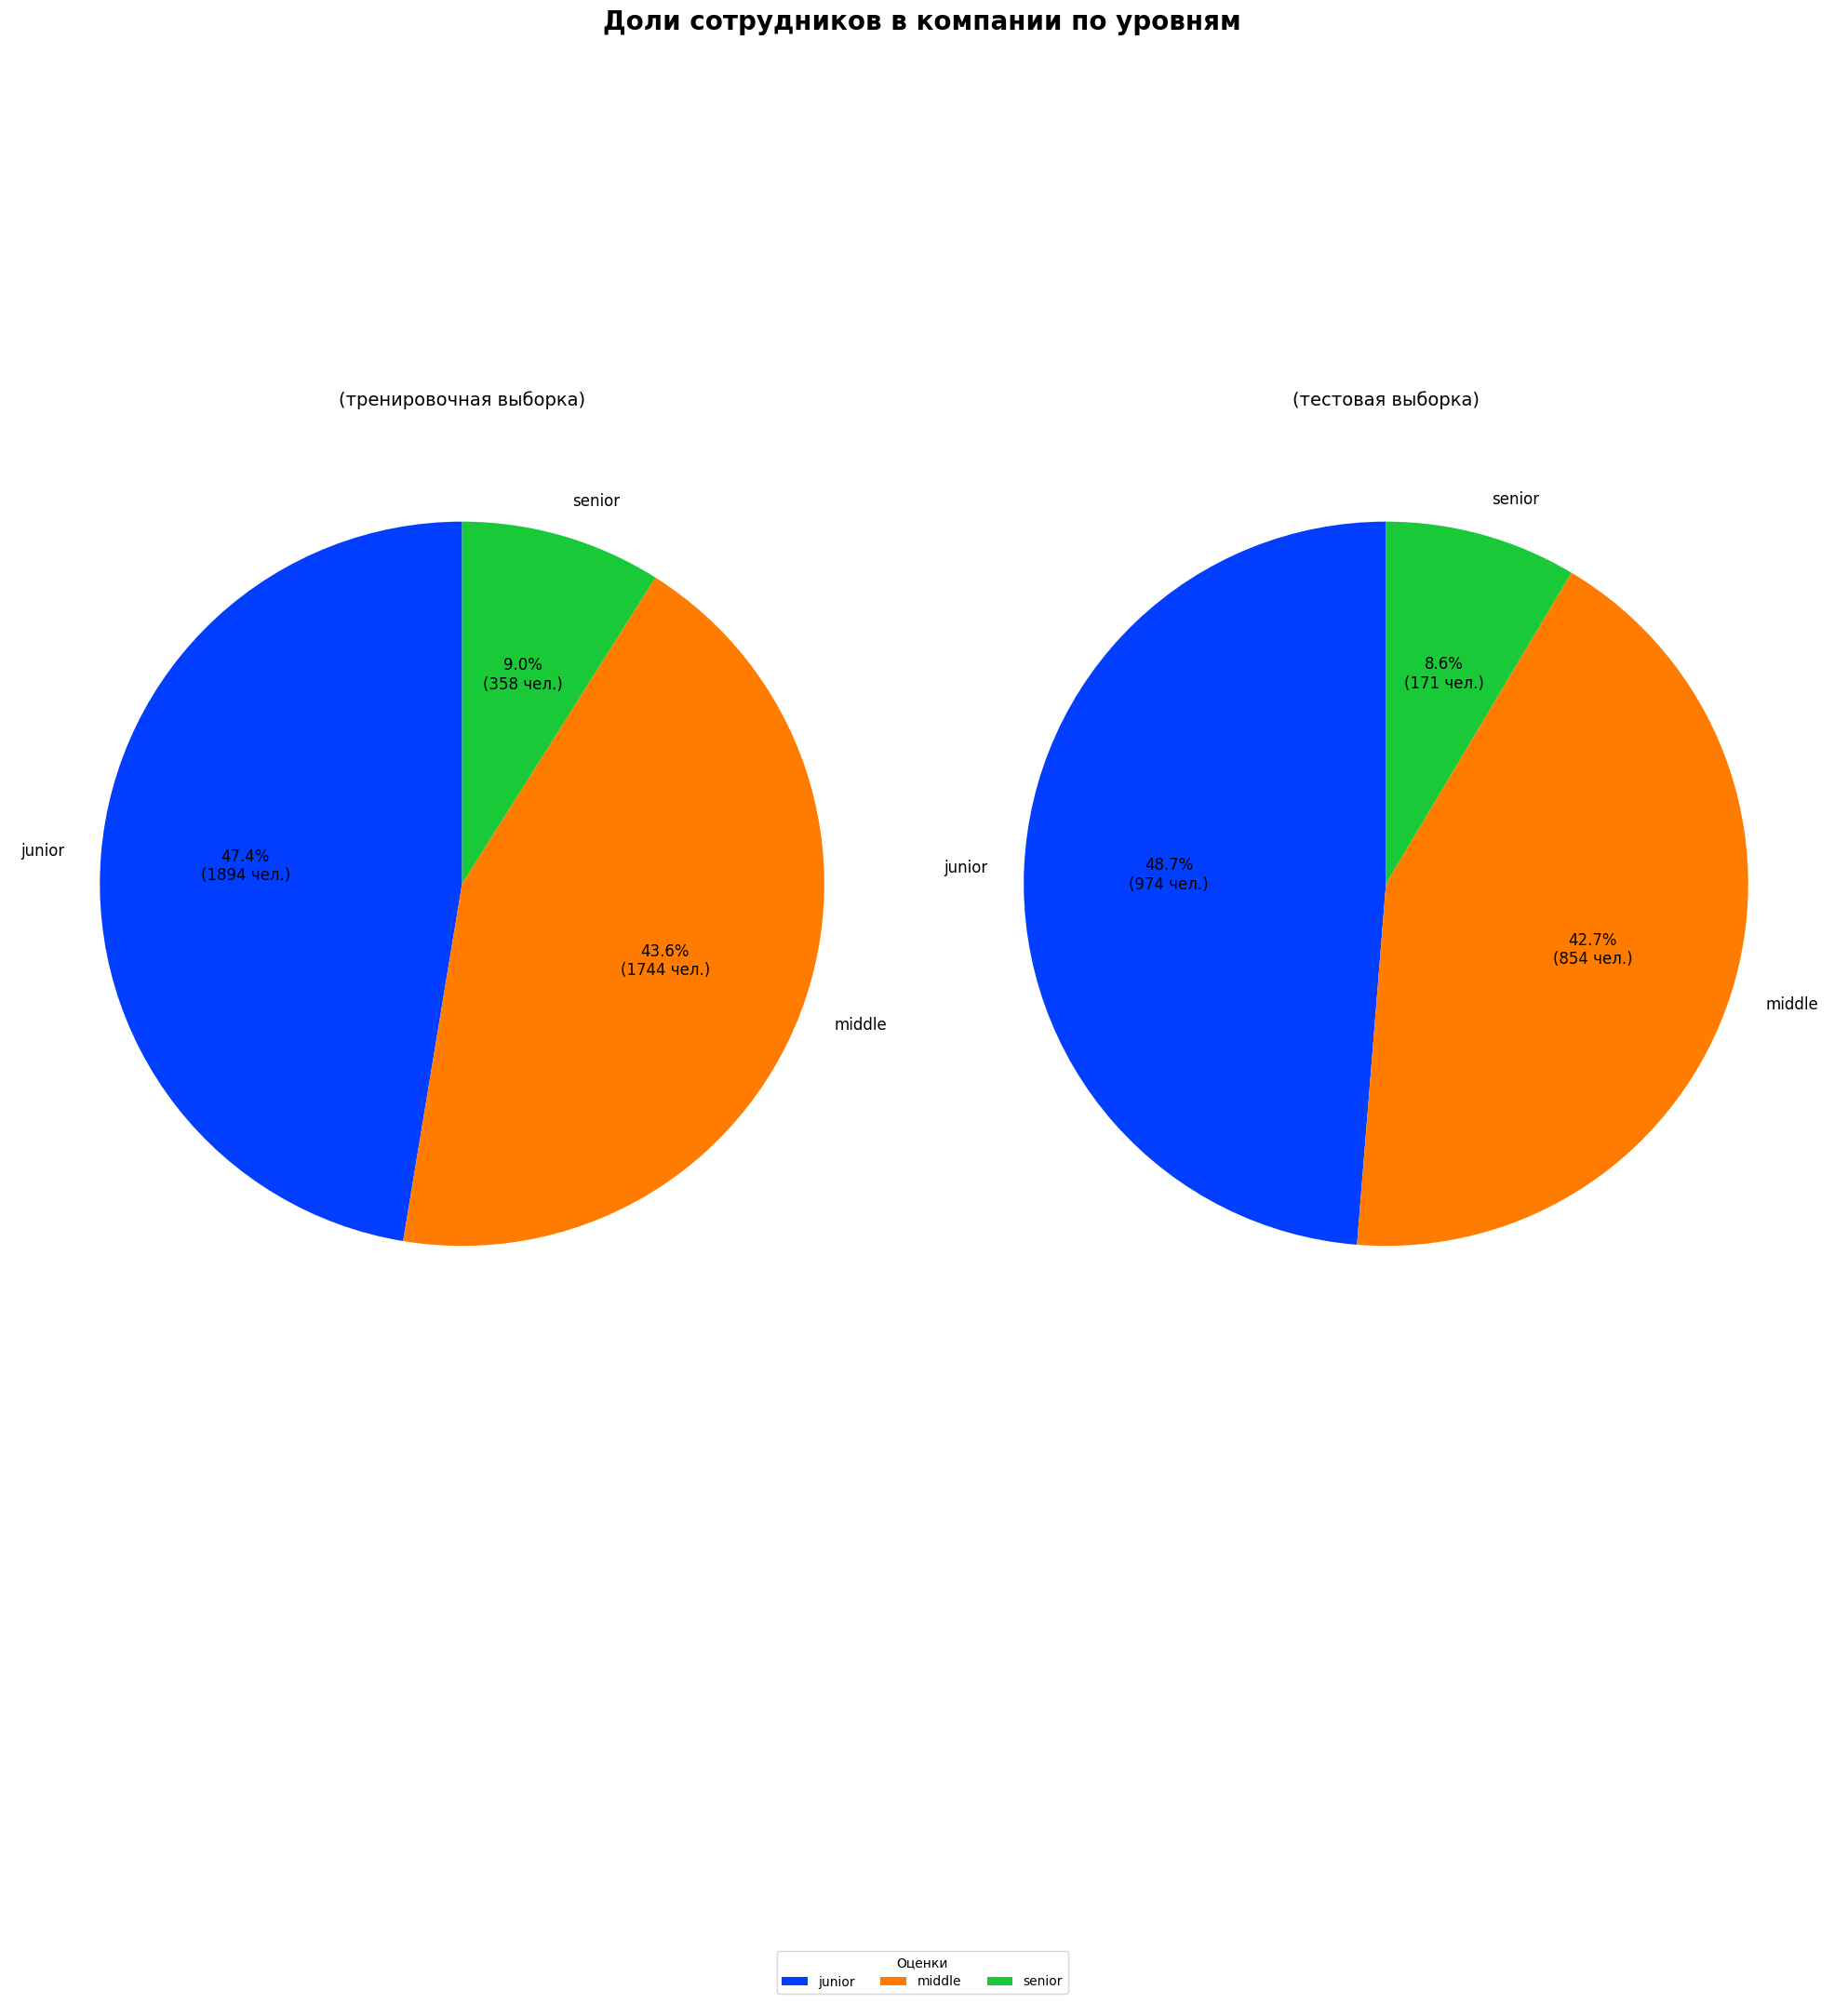

In [51]:
# Создаем фигуру с двумя subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 20))

# Цветовая палитра
palette_color = sns.color_palette('bright')

# Первая диаграмма (тренировочные данные)
train_counts = train_1['level'].value_counts()
ax1.pie(train_counts,
        labels=train_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(train_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax1.set_title('(тренировочная выборка)', pad=20, fontsize=14)

# Вторая диаграмма (тестовая выборка)
test_counts = X_test_1['level'].value_counts()
ax2.pie(test_counts,
        labels=test_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(test_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax2.set_title('(тестовая выборка)', pad=20, fontsize=14)

# Общий заголовок
plt.suptitle('Доли сотрудников в компании по уровням', y=1.02, fontsize=20, weight='bold')

# Добавляем легенду
fig.legend(train_counts.index,
           title='Оценки',
           loc='lower center',
           ncol=len(train_counts),
           bbox_to_anchor=(0.5, -0.05))

# Настройка отступов
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.25)
plt.show()


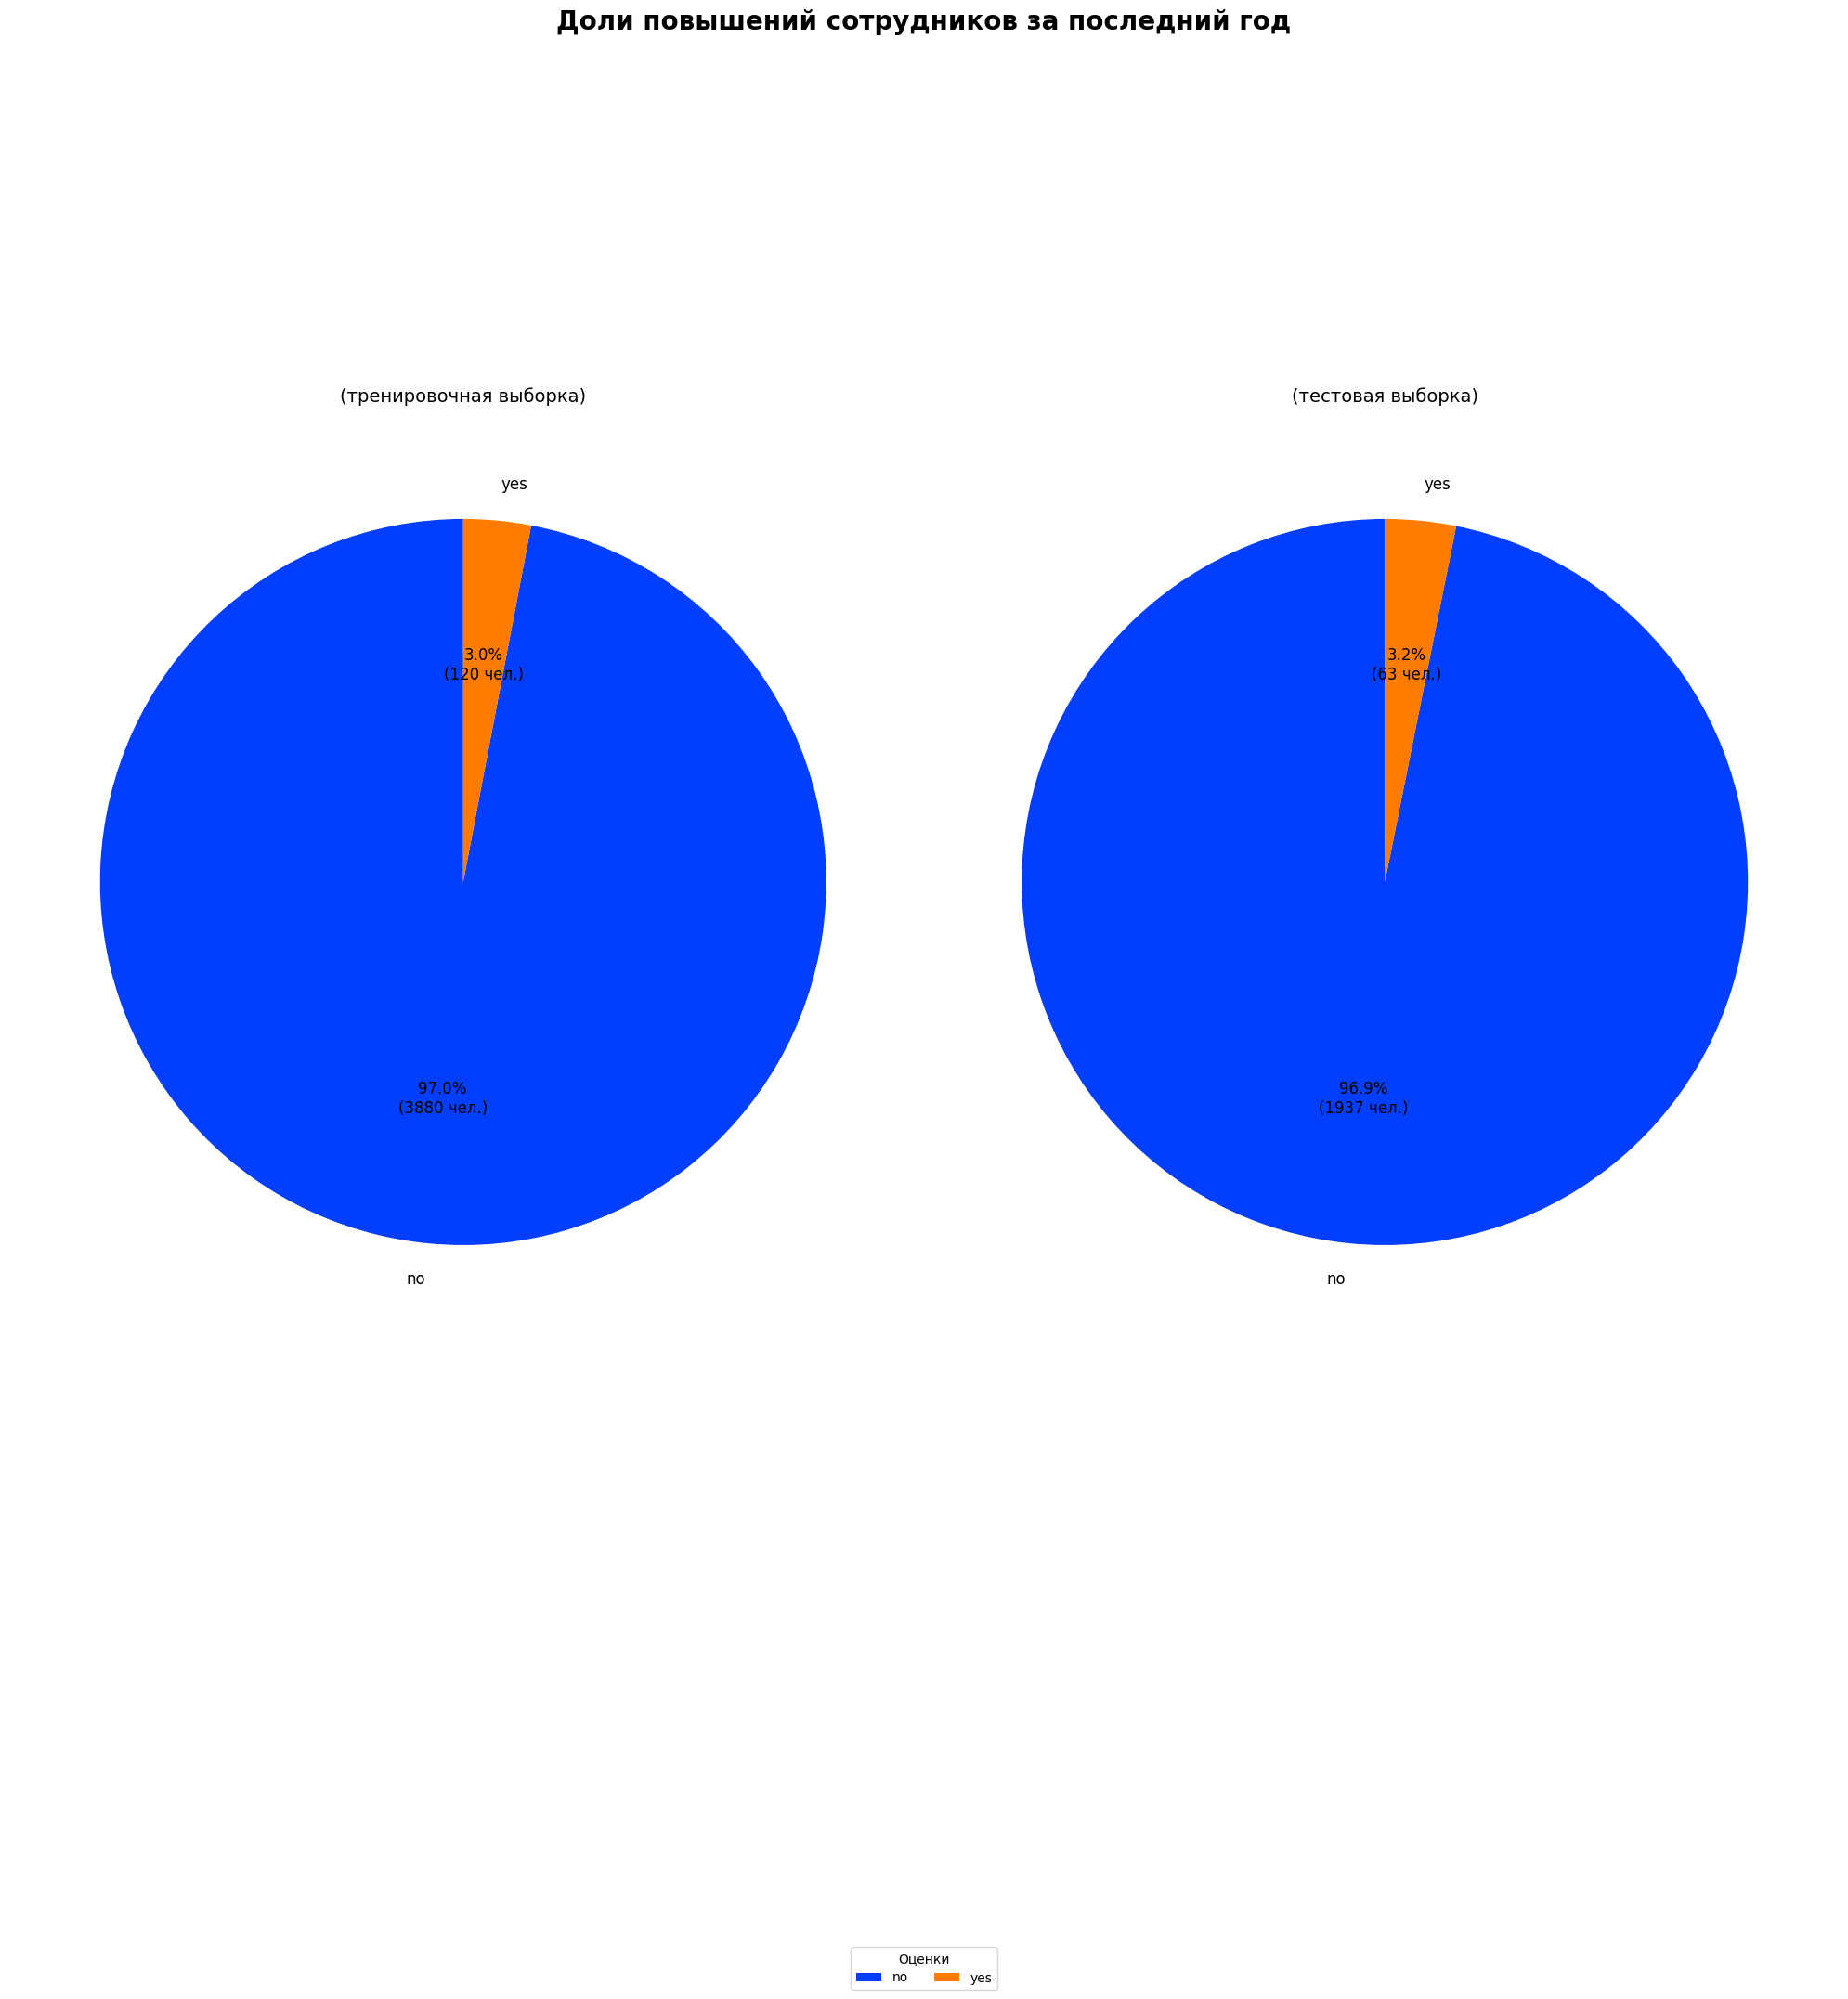

In [52]:

# Создаем фигуру с двумя subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 20))

# Цветовая палитра
palette_color = sns.color_palette('bright')

# Первая диаграмма (тренировочные данные)
train_counts = train_1['last_year_promo'].value_counts()
ax1.pie(train_counts,
        labels=train_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(train_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax1.set_title('(тренировочная выборка)', pad=20, fontsize=14)

# Вторая диаграмма (тестовая выборка)
test_counts = X_test_1['last_year_promo'].value_counts()
ax2.pie(test_counts,
        labels=test_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(test_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax2.set_title('(тестовая выборка)', pad=20, fontsize=14)

# Общий заголовок
plt.suptitle('Доли повышений сотрудников за последний год', y=1.02, fontsize=20, weight='bold')

# Добавляем легенду
fig.legend(train_counts.index,
           title='Оценки',
           loc='lower center',
           ncol=len(train_counts),
           bbox_to_anchor=(0.5, -0.05))

# Настройка отступов
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.25)
plt.show()

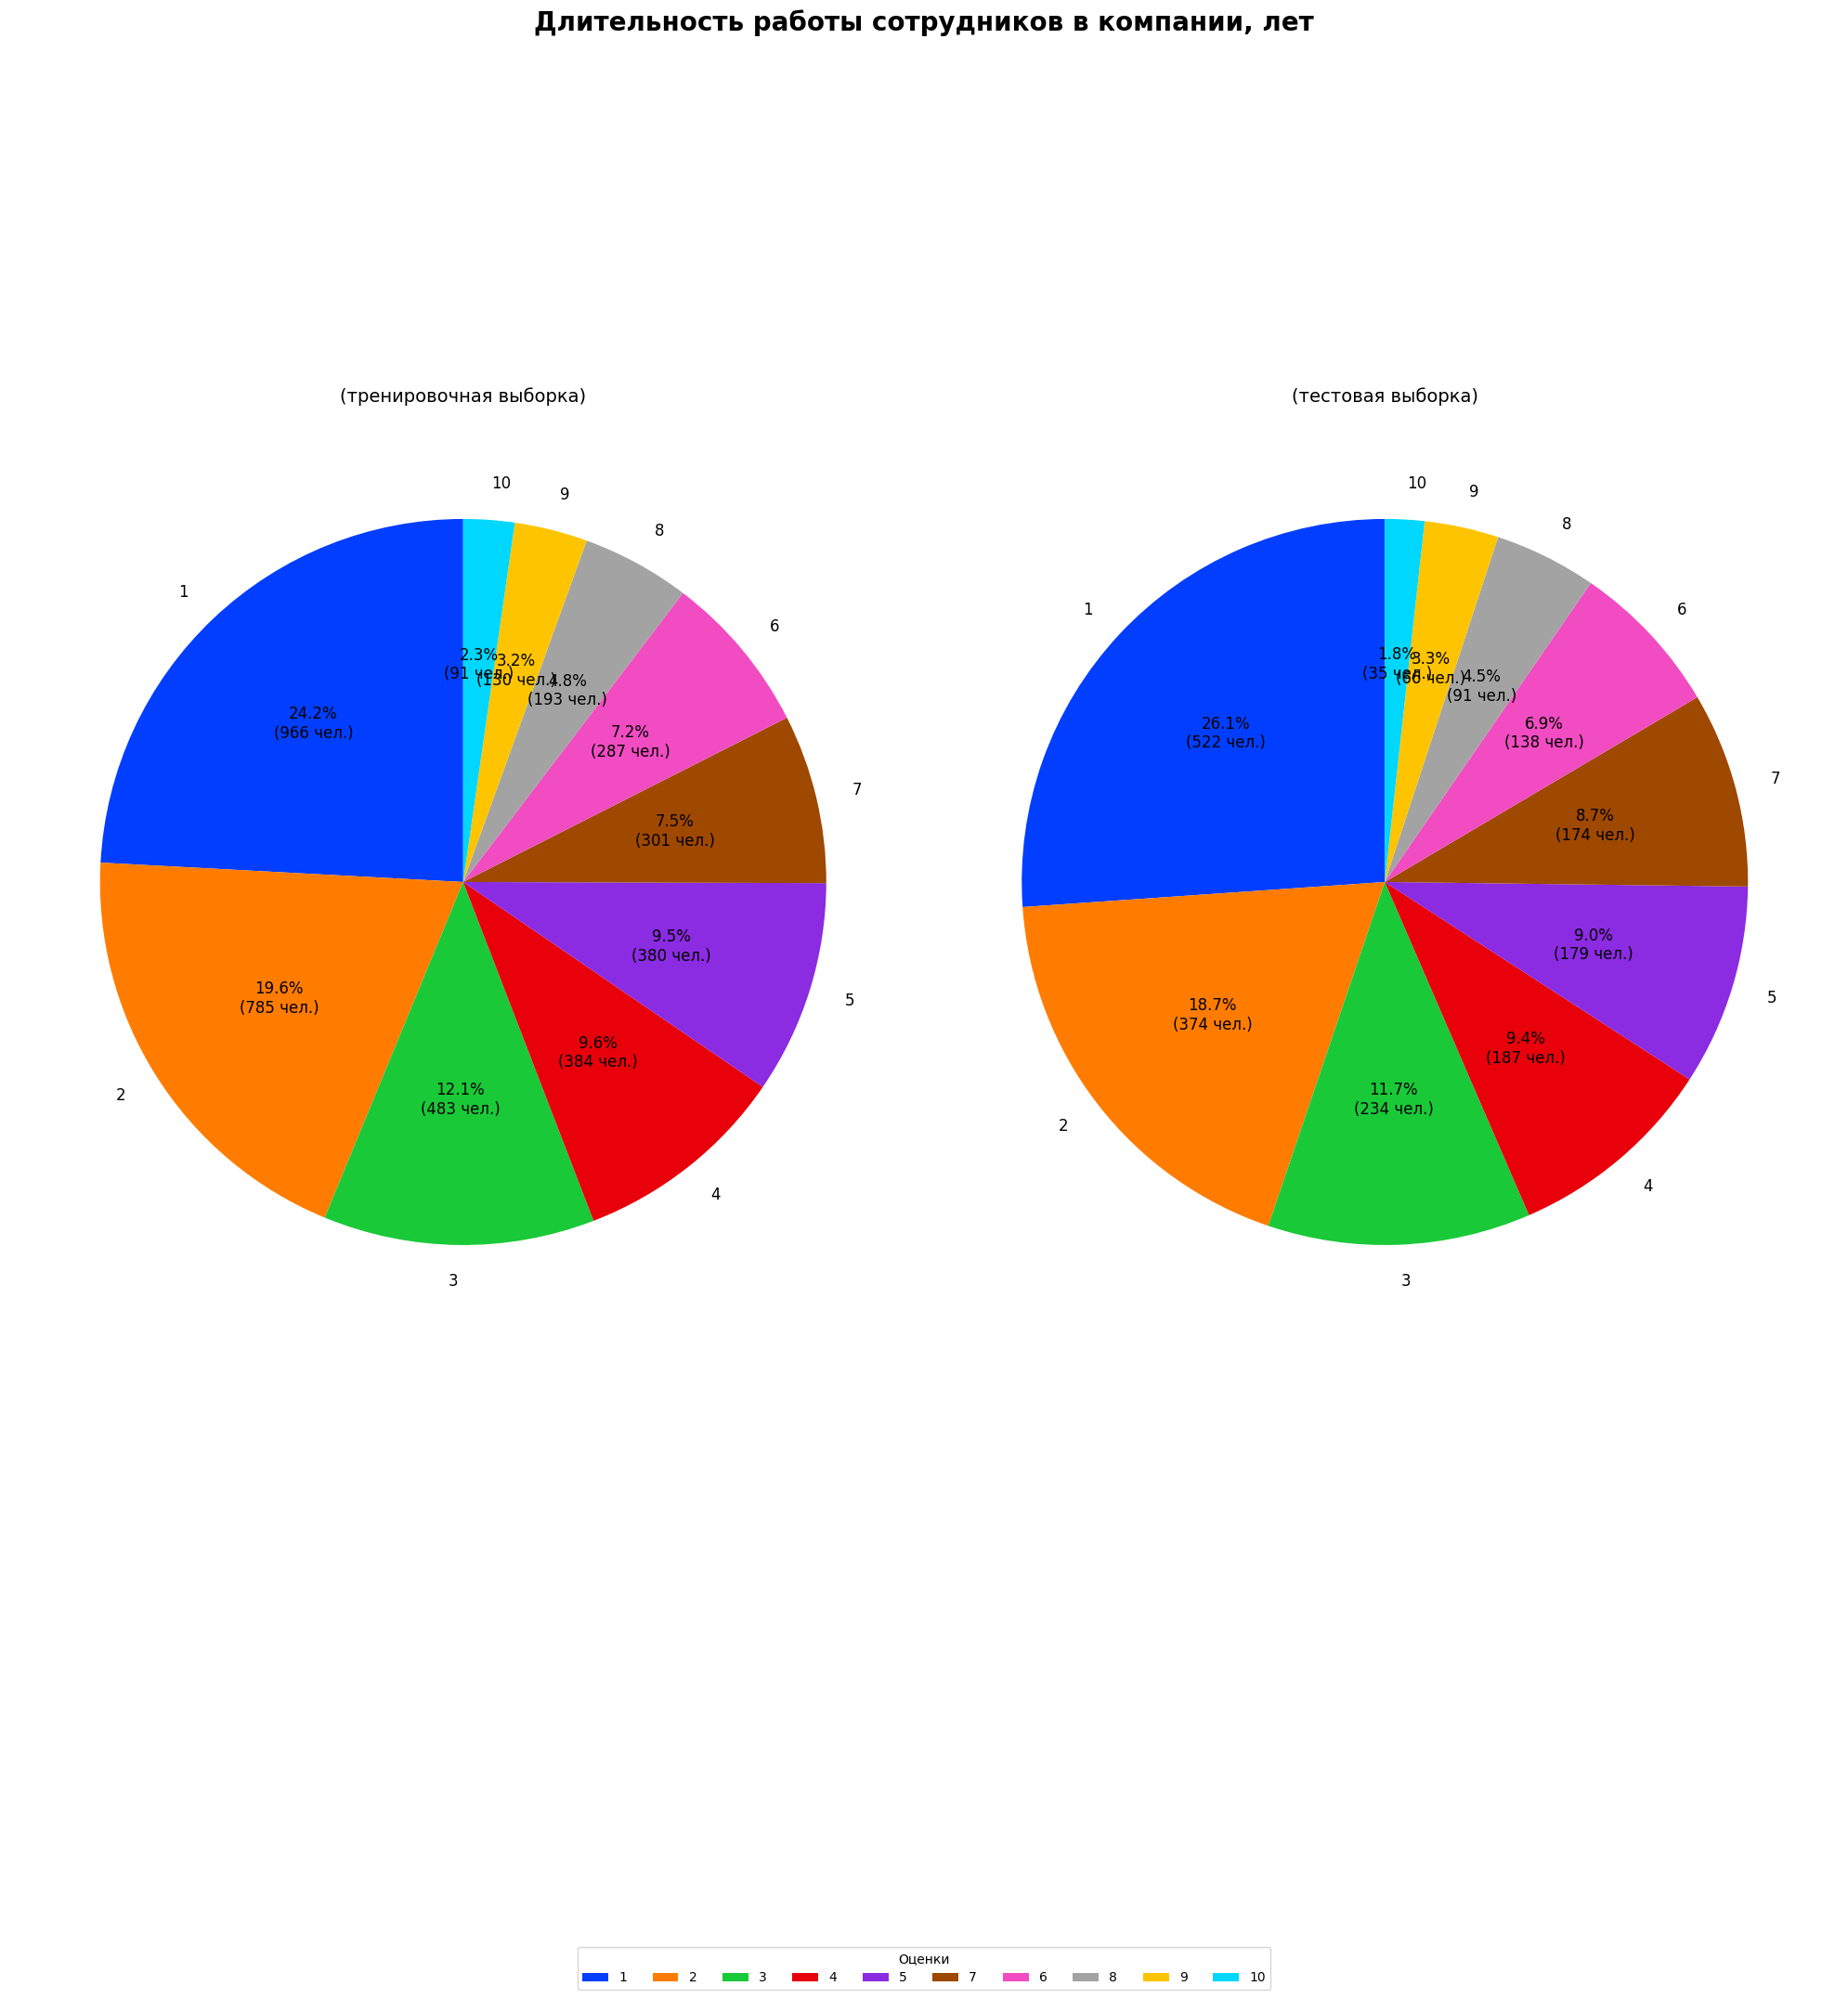

In [53]:
# Создаем фигуру с двумя subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 20))

# Цветовая палитра
palette_color = sns.color_palette('bright')

# Первая диаграмма (тренировочные данные)
train_counts = train_1['employment_years'].value_counts()
ax1.pie(train_counts,
        labels=train_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(train_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax1.set_title('(тренировочная выборка)', pad=20, fontsize=14)

# Вторая диаграмма (тестовая выборка)
test_counts = X_test_1['employment_years'].value_counts()
ax2.pie(test_counts,
        labels=test_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(test_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax2.set_title('(тестовая выборка)', pad=20, fontsize=14)

# Общий заголовок
plt.suptitle('Длительность работы сотрудников в компании, лет', y=1.02, fontsize=20, weight='bold')

# Добавляем легенду
fig.legend(train_counts.index,
           title='Оценки',
           loc='lower center',
           ncol=len(train_counts),
           bbox_to_anchor=(0.5, -0.05))

# Настройка отступов
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.25)
plt.show()


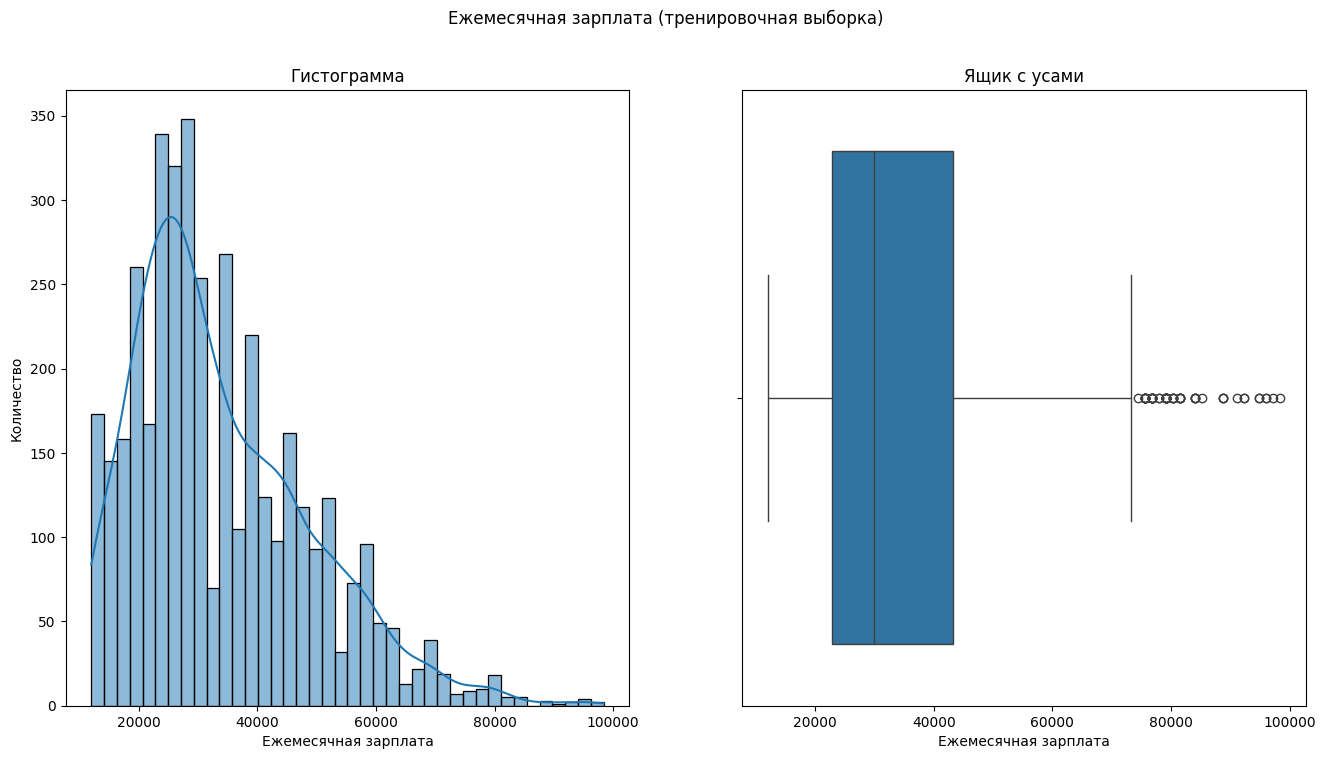

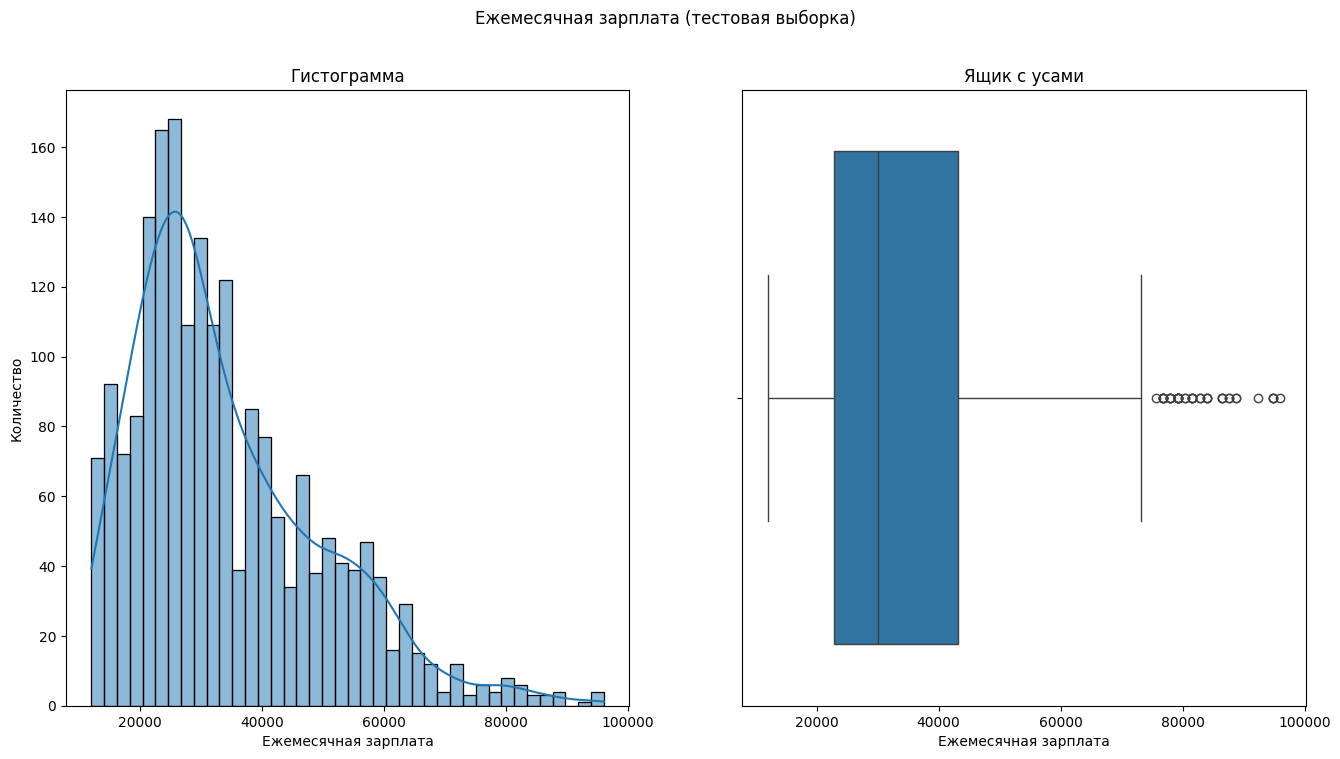

In [54]:
# Ежемесячная зарплата сотрудников трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sn.histplot(data = train_1,x = 'salary', ax=axs[0], bins = 40, kde=True)
axs[0].set_xlabel('Ежемесячная зарплата')
axs[0].set_ylabel('Количество')
axs[0].set_title('Гистограмма')
sn.boxplot(data = train_1,x = 'salary', ax=axs[1])
axs[1].set_xlabel('Ежемесячная зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Ежемесячная зарплата (тренировочная выборка)')
plt.show()

# Ежемесячная зарплата сотрудников тест
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sn.histplot(data = X_test_1,x = 'salary', ax=axs[0], bins = 40, kde=True)
axs[0].set_xlabel('Ежемесячная зарплата')
axs[0].set_ylabel('Количество')
axs[0].set_title('Гистограмма')
sn.boxplot(data = X_test_1,x = 'salary', ax=axs[1])
axs[1].set_xlabel('Ежемесячная зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Ежемесячная зарплата (тестовая выборка)')
plt.show()

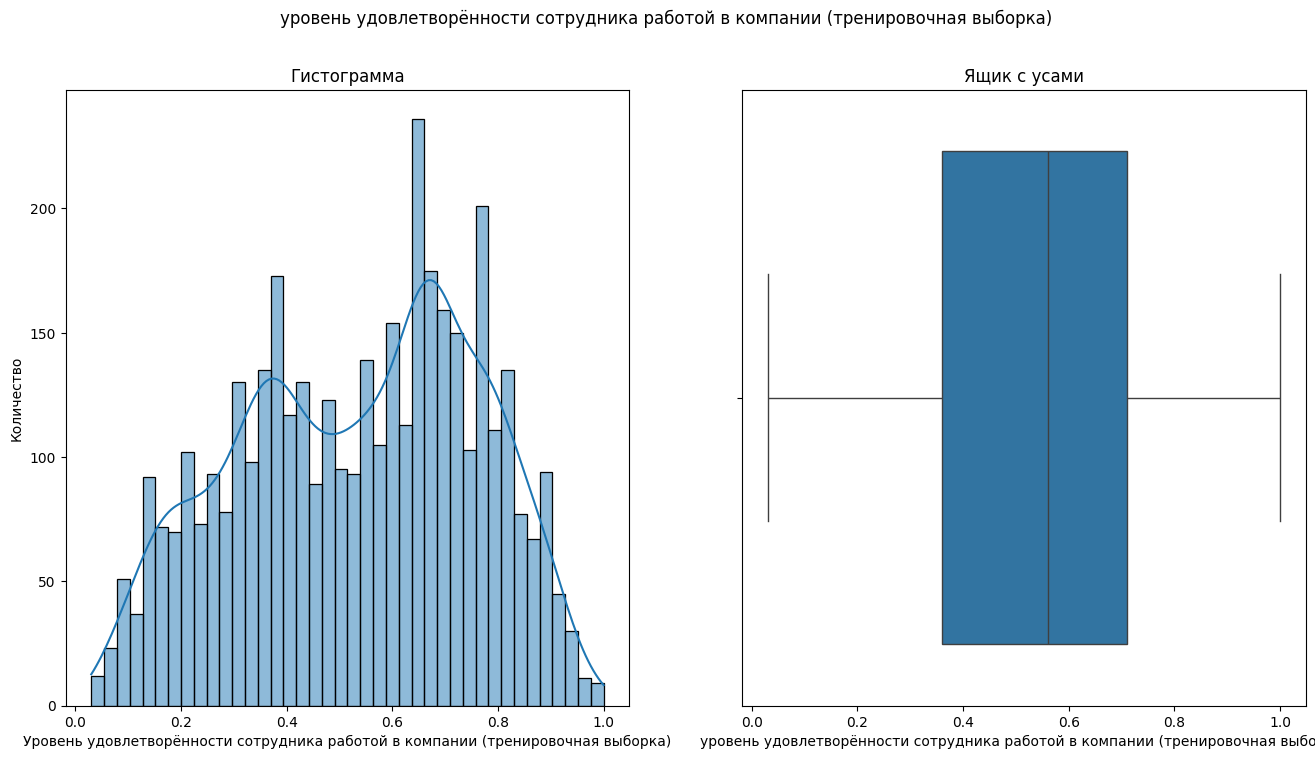

In [55]:
# Ежемесячная зарплата сотрудников трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sn.histplot(data = train_1,x = 'job_satisfaction_rate', ax=axs[0], bins = 40, kde=True)
axs[0].set_xlabel('Уровень удовлетворённости сотрудника работой в компании (тренировочная выборка)')
axs[0].set_ylabel('Количество')
axs[0].set_title('Гистограмма')
sn.boxplot(data = train_1,x = 'job_satisfaction_rate', ax=axs[1])
axs[1].set_xlabel('уровень удовлетворённости сотрудника работой в компании (тренировочная выборка)')
axs[1].set_title('Ящик с усами')
fig.suptitle('уровень удовлетворённости сотрудника работой в компании (тренировочная выборка)')
plt.show()

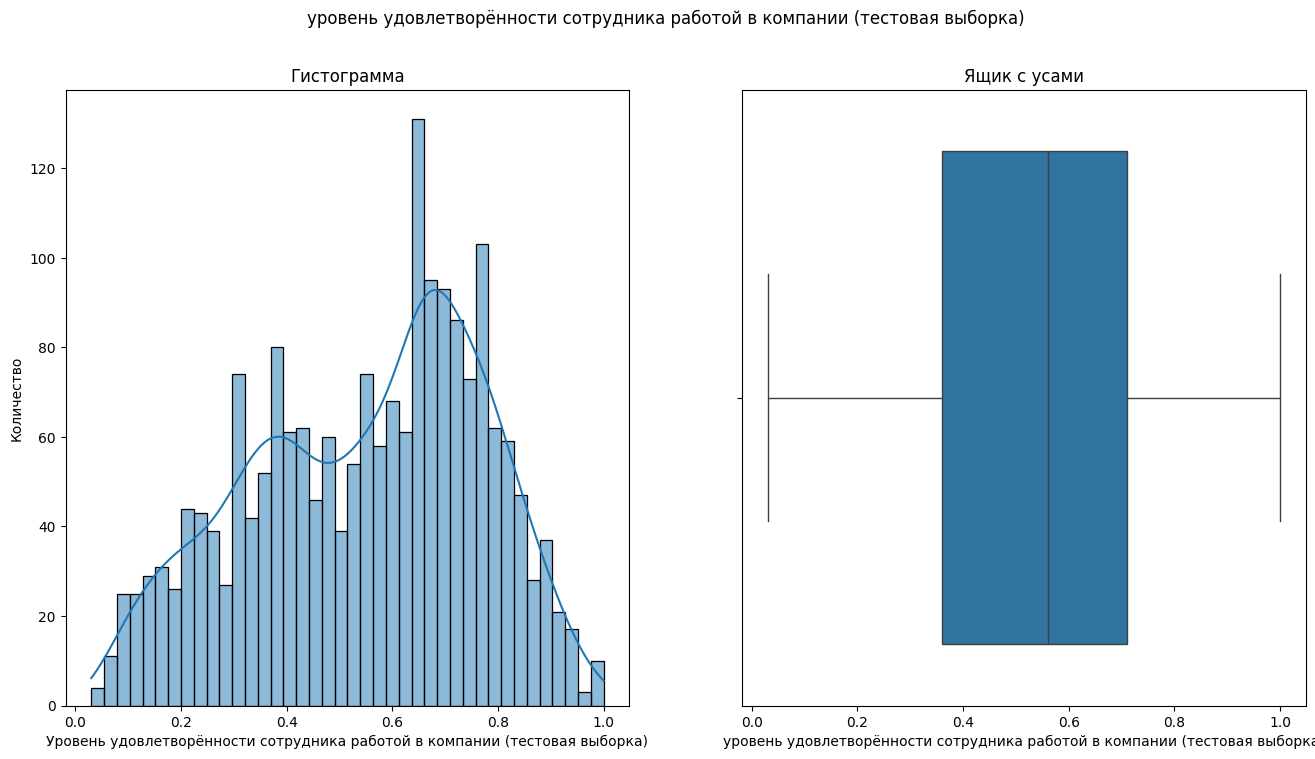

In [56]:
# Ежемесячная зарплата сотрудников тecn
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sn.histplot(data = y_test_1, x = 'job_satisfaction_rate', ax=axs[0], bins = 40, kde=True)
axs[0].set_xlabel('Уровень удовлетворённости сотрудника работой в компании (тестовая выборка)')
axs[0].set_ylabel('Количество')
axs[0].set_title('Гистограмма')
sn.boxplot(data = train_1,x = 'job_satisfaction_rate', ax=axs[1])
axs[1].set_xlabel('уровень удовлетворённости сотрудника работой в компании (тестовая выборка)')
axs[1].set_title('Ящик с усами')
fig.suptitle('уровень удовлетворённости сотрудника работой в компании (тестовая выборка)')
plt.show()

In [57]:
train_1.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76


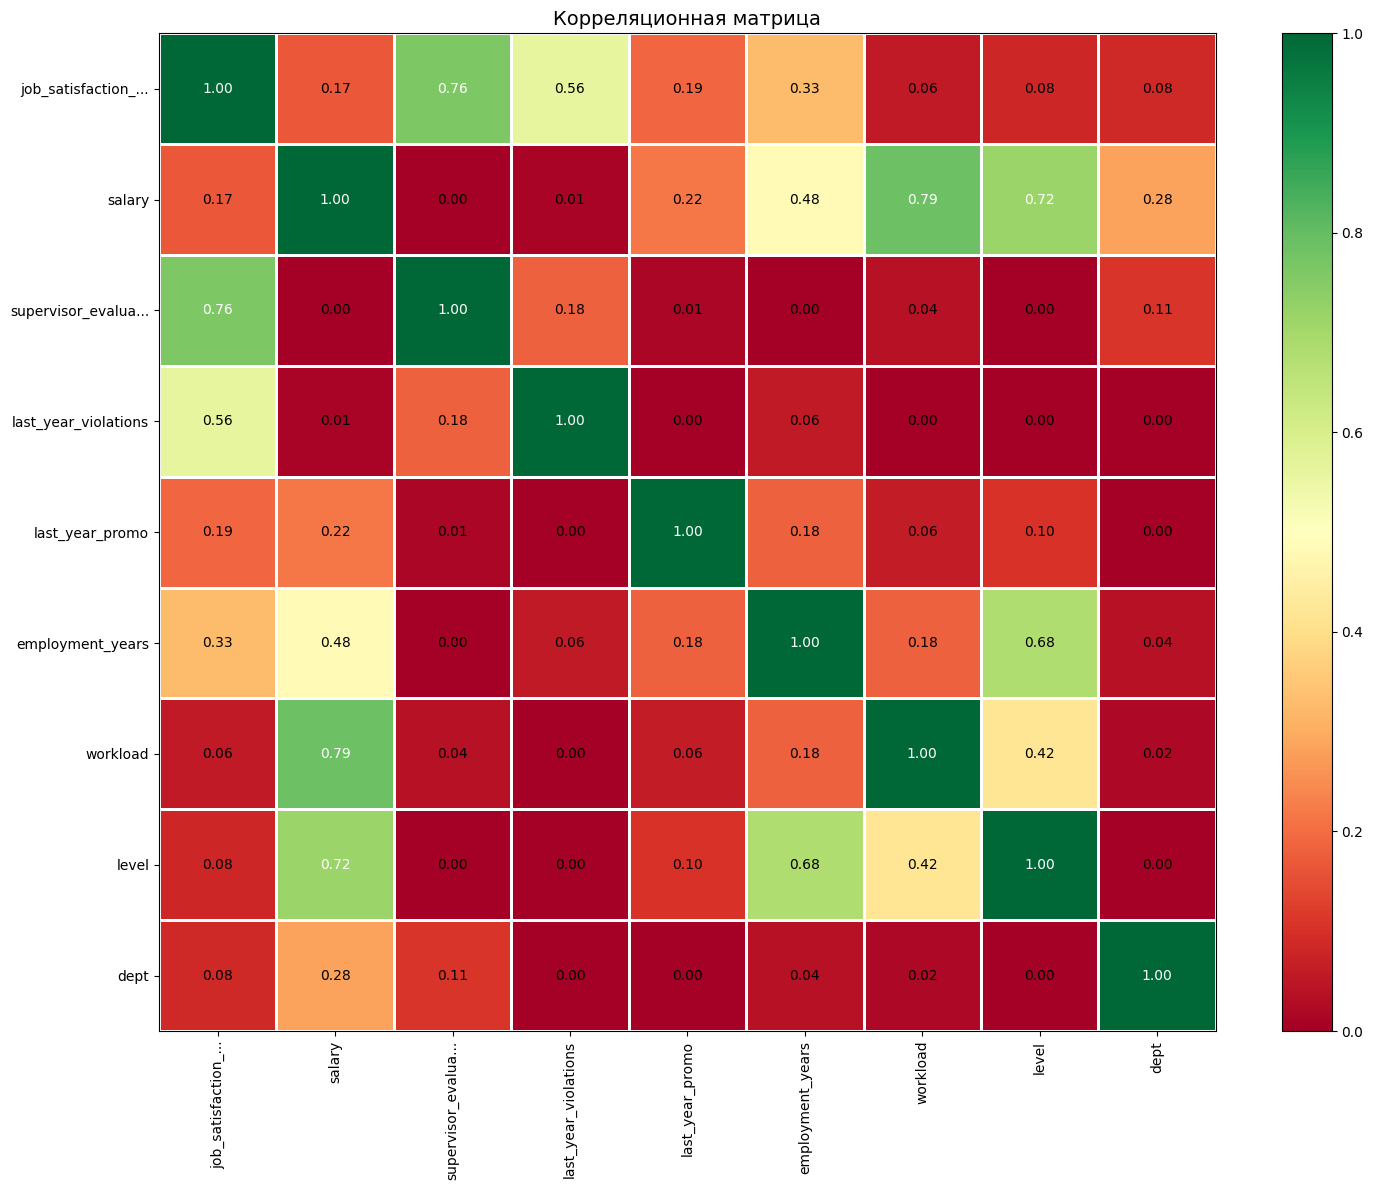

In [58]:
# Чисолвые непрерывные признаки
numeric_features = ['salary', 'job_satisfaction_rate']

# Категориальные признаки
categorical_features = ['dept']

# Оценочные признаки
ordinal_features = ['level', 'workload', 'last_year_violations', 'last_year_promo']

# Непрерывные признаки
interval_cols = numeric_features

# Корелляционная матрица трэйн выборки
phik_train = train_1.phik_matrix(interval_cols=interval_cols)
plot_correlation_matrix(phik_train.values,
                       x_labels=phik_train.columns,
                       y_labels=phik_train.index,
                       vmin=0, vmax=1,
                       title='Корреляционная матрица',
                       figsize=(15, 12))

In [59]:
X_test_1.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000


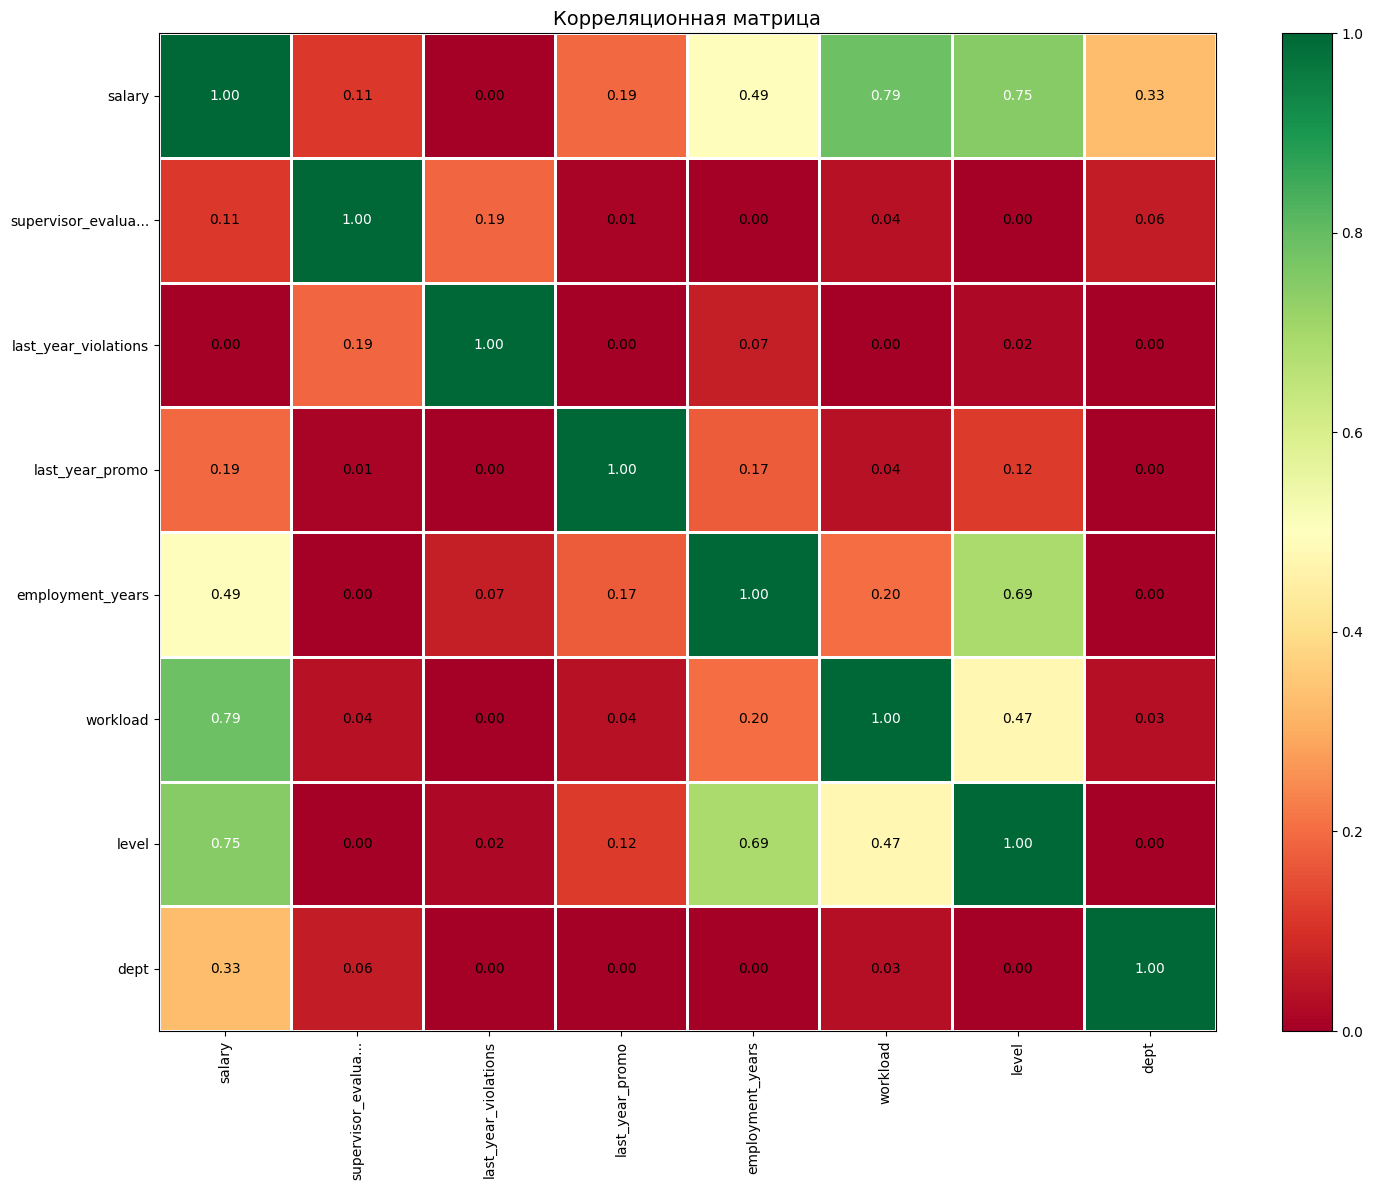

In [60]:
# Чисолвые непрерывные признаки
numeric_features = ['salary']

# Категориальные признаки
categorical_features = ['dept']

# Оценочные признаки
ordinal_features = ['level', 'workload', 'last_year_violations', 'last_year_promo']

# Непрерывные признаки
interval_cols = numeric_features

# Корелляционная матрица
phik_test = X_test_1.phik_matrix(interval_cols=interval_cols)
plot_correlation_matrix(phik_test.values,
                       x_labels=phik_test.columns,
                       y_labels=phik_test.index,
                       vmin=0, vmax=1,
                       title='Корреляционная матрица',
                       figsize=(15, 12))

**Вывод по исследовательскому анализу**

- Медианная зарплата составляет 30000 р.
- Медианное количество лет работы в компе=ании 3 года. Доля отработавших 1 год - 24% - это бОльшая часть сотрудников. Далее 2, далее 3 года - больше сотрудники стараются не работать. Компания тратит большие ресурсы - временные, финансовые, компетентностные на обучение и вовлечение новых сотрудников, а сотрудники уходят. Хорошо, что компания видит эту проблему и хочет ее решить.
- в большинстве случаев руководство оценивает своих сотрудников, как середнячков, оценка руководства, судя по данным, никак или мало влияет не влияет на зарплату, загрузку, количество лет, повышение.
-зарплата сильно зависит от уровня занимаемой должности и загруженности, а также - от количества лет в компании. Также есть слабая связь с отделом , в котором работает сотрудник.
- уровень сильно зависит от количества лет в компании.
- загруженность зависит от количества лет в компании.

В корелляционной матрице присутствует мультиколлиниарность (корелляция признаокв более 70-90%). Но в задании введен бОльший уровень корелляции. признаки не удаляем.

### Подготовка данных

In [61]:
# Удаление явных дубликатов
train_1 = train_1.drop_duplicates()

In [62]:
train_1.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
155278,sales,junior,medium,2,no,no,1,24000,0.58
653870,hr,junior,high,2,no,no,5,38400,0.76


In [63]:
y_test_1

,job_satisfaction_rate
id,
130604,0.74
825977,0.75
418490,0.60
555320,0.72
826430,0.08
...,...
405257,0.28
370925,0.21
857722,0.39


In [64]:
X_test_1.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000


In [65]:
ohe_columns = ['dept', 'last_year_promo',  'last_year_violations']
ord_columns = ['level', 'workload']
num_columns = ['supervisor_evaluation', 'employment_years', 'salary']
RANDOM_STATE = 50

y = train_1['job_satisfaction_rate']
X = train_1.drop(['job_satisfaction_rate'], axis = 1)

ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe',
            OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output =False)
        )
    ]
)

ord_pipe = Pipeline(
    [
        (
            'simpleImputer_before_ord',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'senior'],
                    ['low', 'medium', 'high']
                ],
                handle_unknown='use_encoded_value',
                unknown_value=-1
            )
        ),
        (
            'simpleImputer_after_ord',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)


In [66]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', MinMaxScaler(), num_columns)
    ],
    remainder='passthrough'
)

### Обучение моделей

In [67]:
pipe_final= Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])

param_distributions = [
    {
        'models': [DecisionTreeRegressor(random_state=RANDOM_STATE)],
        'models__max_depth': [None] + [i for i in range(2, 7)],
        'models__min_samples_split': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
    {
        'models': [LinearRegression()],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
    {
        'models': [Ridge(random_state = RANDOM_STATE)],
        'models__solver': ['saga', 'auto'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    }
]

def smape_score(y_true, y_pred):
    return 100/len(y_true) * np.sum(np.abs(y_true-y_pred)/((np.abs(y_true) + np.abs(y_pred))/2))

smape_scorer = make_scorer(smape_score, greater_is_better = False)

In [68]:
grid_search = GridSearchCV(
    pipe_final,
    param_distributions,
    cv = 5,
    scoring=smape_scorer,
    n_jobs=-1
)
grid_search.fit(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         Pipeline(steps=[('simpleImputer_ohe',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('ohe',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['dept',
                                                                          'last_year_promo',
                                                                          'last_year_violations']),
                                                                        ('ord',
                                                                         Pipeline(...
                         {'models': [LinearRegression()],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(), RobustScaler(),
                                                'passthrough']},
                         {'models': [Ridge(random_state=50)],
                          'models__solver': ['saga', 'auto'],
                          'preprocessor__num': [StandardScaler(),
                                                MinMaxScaler(), RobustScaler(),
                                                'passthrough']}],
             scoring=make_scorer(smape_score, greater_is_better=False, response_method='predict'))

In [69]:
grid_search.best_estimator_


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_befor...
                                                                   OrdinalEncoder(categories=[['junior',
                                                                                               'middle',
                                                                                               'senior'],
                                                                                              ['low',
                                                                                               'medium',
                                                                                               'high']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1)),
                                                                  ('simpleImputer_after_ord',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['level', 'workload']),
                                                 ('num', MinMaxScaler(),
                                                  ['supervisor_evaluation',
                                                   'employment_years',
                                                   'salary'])])),
                ('models',
                 DecisionTreeRegressor(min_samples_split=8, random_state=50))])

In [70]:
print(f'Метрика лучшей модели на кросс-валидации: {-grid_search.best_score_}')


Метрика лучшей модели на кросс-валидации: 14.964210147314947


In [71]:
y_test_1 = y_test_1.sort_index()
X_test_1 = X_test_1.sort_index()

In [72]:
y_predict = grid_search.predict(X_test_1)
smape_score(np.array(y_test_1['job_satisfaction_rate']), y_predict)

13.56284455219568

In [73]:
y_test_1

,job_satisfaction_rate
id,
100298,0.80
100480,0.84
100503,0.79
100610,0.75
100692,0.69
...,...
997290,0.79
998548,0.76
998762,0.48


In [74]:
y_predict

array([0.82      , 0.852     , 0.74666667, ..., 0.49      , 0.46428571,
       0.30714286])

Значение метрики smape_score = 13.991. Это меньше 15, значит модель работает хорошо.

### Оформление выводов

В задаче 1 подготовлены данные, предложены модели МО, созданы пайплайны, модели обучены по предоставленным данным, целевой призкак - удовлетворенность сотрудников работой. Была предложена метрика smape. Она выбрана лучшей. МО посчитала лучшей моделью DecisionTreeRegressor. Значение метрики на тестовой выборке получилось меньше заданного порога: 13.991 < 15. Данная модель справилась лучше линейной регрессии, тк зависимости между признаками имеют нелинейный характер. Найдены предсказываемые вероятности удовлетворенности сотрудниками своей работой.

## Задача 2: предсказание увольнения сотрудника из компании

### Загрузка данных

In [76]:
train_quit = pd.read_csv('https://code.s3.yandex.net/datasets/train_quit.csv', index_col=0)
train_quit.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no
814010,sales,junior,medium,2,no,no,4,27600,no


In [77]:
test_features = pd.read_csv('https://code.s3.yandex.net/datasets/test_features.csv', index_col=0)
test_features.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000


In [78]:
test_target_quit = pd.read_csv('https://code.s3.yandex.net/datasets/test_target_quit.csv', index_col=0)
test_target_quit.head(2)

,quit
id,
999029,yes
372846,no


In [79]:
train_2 = train_quit
train_2.isna().sum()

dept                     0
level                    0
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
quit                     0
dtype: int64

In [80]:
X_test_2 = test_features
X_test_2.isna().sum()

dept                     2
level                    1
workload                 0
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
dtype: int64

In [81]:
y_test_2 = test_target_quit
y_test_2.isna().sum()

quit    0
dtype: int64

Есть пропуски в X_test_2. Заполним их в пайплайне.

In [82]:
train_2['dept'].unique()

array(['sales', 'purchasing', 'marketing', 'technology', 'hr'],
      dtype=object)

In [83]:
train_2['level'].unique()

array(['middle', 'junior', 'sinior'], dtype=object)

In [84]:
train_2['workload'].unique()

array(['high', 'medium', 'low'], dtype=object)

In [85]:
train_2['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [86]:
train_2['last_year_violations'].unique()

array(['no', 'yes'], dtype=object)

In [87]:
train_2['quit'].unique()

array(['no', 'yes'], dtype=object)

In [88]:
X_test_2['dept'].unique()

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan, ' '],
      dtype=object)

In [89]:
X_test_2['level'].unique()

array(['junior', 'middle', 'sinior', nan], dtype=object)

In [90]:
X_test_2['workload'].unique()

array(['medium', 'low', 'high', ' '], dtype=object)

In [91]:
X_test_2['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [92]:
X_test_2['last_year_promo'].unique()

array(['no', 'yes'], dtype=object)

In [93]:
train_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4000 entries, 723290 to 853842
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   4000 non-null   object
 1   level                  4000 non-null   object
 2   workload               4000 non-null   object
 3   employment_years       4000 non-null   int64 
 4   last_year_promo        4000 non-null   object
 5   last_year_violations   4000 non-null   object
 6   supervisor_evaluation  4000 non-null   int64 
 7   salary                 4000 non-null   int64 
 8   quit                   4000 non-null   object
dtypes: int64(3), object(6)
memory usage: 312.5+ KB


In [94]:
X_test_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 485046 to 771859
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   dept                   1998 non-null   object
 1   level                  1999 non-null   object
 2   workload               2000 non-null   object
 3   employment_years       2000 non-null   int64 
 4   last_year_promo        2000 non-null   object
 5   last_year_violations   2000 non-null   object
 6   supervisor_evaluation  2000 non-null   int64 
 7   salary                 2000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 140.6+ KB


In [95]:
y_test_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2000 entries, 999029 to 460332
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   quit    2000 non-null   object
dtypes: object(1)
memory usage: 31.2+ KB


In [96]:
y_test_2.head(2)

,quit
id,
999029,yes
372846,no


### Предобработка данных

In [97]:
X_test_2['last_year_violations'].unique()

array(['no', 'yes'], dtype=object)

In [98]:
train_2.loc[train_2['level'] == 'sinior', 'level'] = 'senior'

In [99]:
train_2['level'].unique()

array(['middle', 'junior', 'senior'], dtype=object)

In [100]:
train_2.duplicated().sum()

1413

In [101]:
train_2.shape[0]

4000

In [102]:
X_test_2.loc[X_test_2['dept'] == ' ', 'dept'] = np.nan
X_test_2.loc[X_test_2['level'] == 'sinior', 'level'] = 'senior'
X_test_2.loc[X_test_2['workload'] == ' ', 'workload'] = np.nan

In [103]:
X_test_2['dept'].unique()

array(['marketing', 'hr', 'sales', 'purchasing', 'technology', nan],
      dtype=object)

In [104]:
X_test_2['level'].unique()

array(['junior', 'middle', 'senior', nan], dtype=object)

In [105]:
X_test_2['workload'].unique()

array(['medium', 'low', 'high', nan], dtype=object)

- исправлены опечатки,
- пробелы и пропуски земенены на корректные пропуски np.nan, с которыми можно работать далее.

### Исследовательский анализ данных

In [106]:
train_2.describe().round(2)

,employment_years,supervisor_evaluation,salary
count,4000.00,4000.00,4000.00
mean,3.70,3.47,33805.80
std,2.54,1.00,15152.42
min,1.00,1.00,12000.00
25%,2.00,3.00,22800.00
50%,3.00,4.00,30000.00
75%,6.00,4.00,43200.00
max,10.00,5.00,96000.00


In [107]:
X_test_2.describe().round(2)

,employment_years,supervisor_evaluation,salary
count,2000.00,2000.00,2000.00
mean,3.67,3.53,34066.80
std,2.54,1.00,15398.44
min,1.00,1.00,12000.00
25%,1.00,3.00,22800.00
50%,3.00,4.00,30000.00
75%,6.00,4.00,43200.00
max,10.00,5.00,96000.00


In [108]:
y_test_2.describe()

,quit
count,2000
unique,2
top,no
freq,1436


In [109]:
train_2.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no
814010,sales,junior,medium,2,no,no,4,27600,no


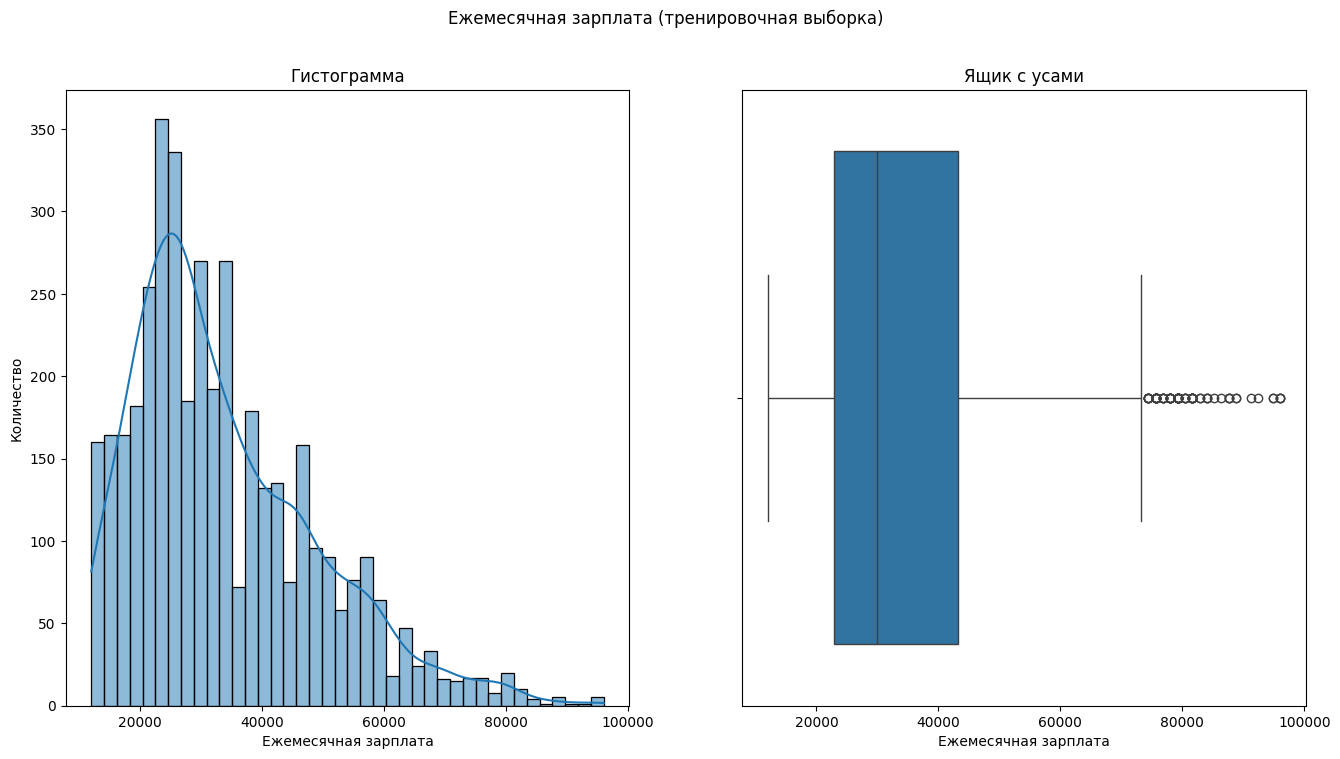

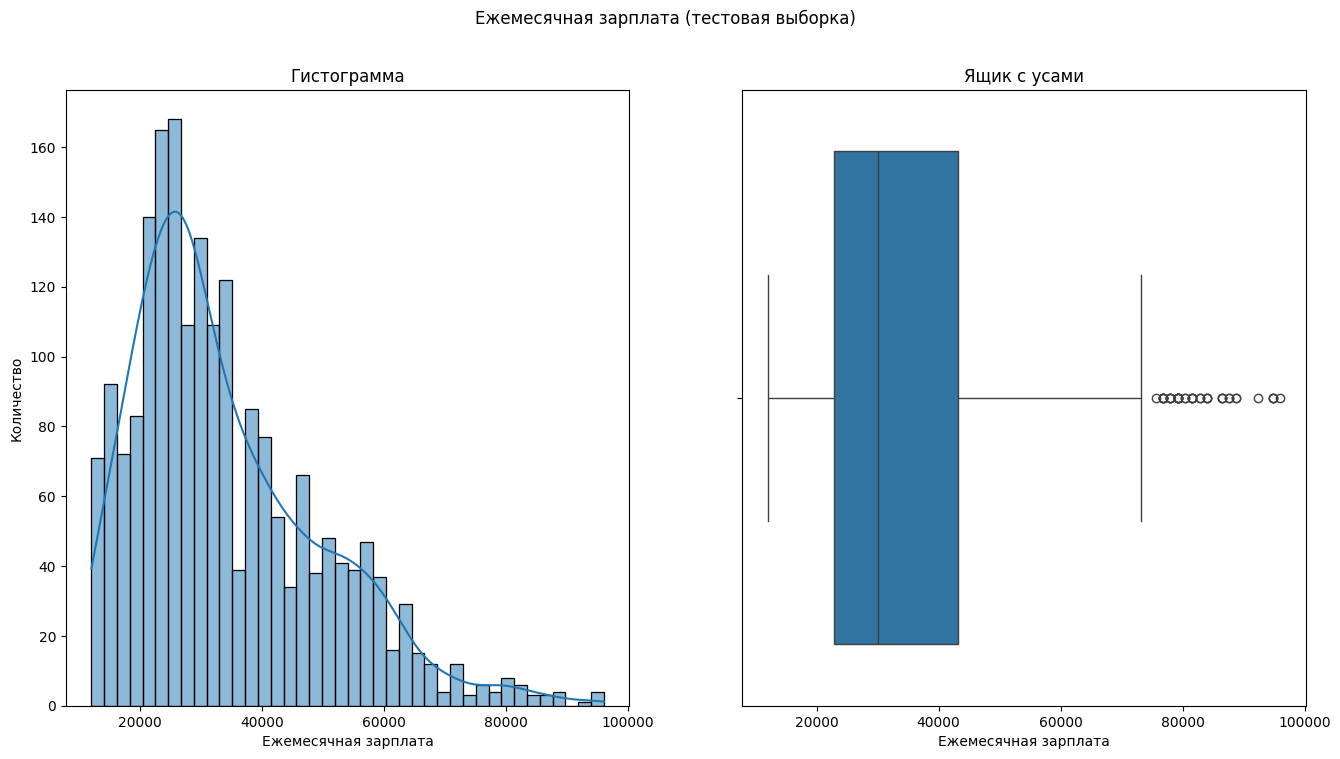

In [110]:
# Ежемесячная зарплата сотрудников трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sn.histplot(data = train_2,x = 'salary', ax=axs[0], bins = 40, kde=True)
axs[0].set_xlabel('Ежемесячная зарплата')
axs[0].set_ylabel('Количество')
axs[0].set_title('Гистограмма')
sn.boxplot(data = train_2,x = 'salary', ax=axs[1])
axs[1].set_xlabel('Ежемесячная зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Ежемесячная зарплата (тренировочная выборка)')
plt.show()

# Ежемесячная зарплата сотрудников тест
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sn.histplot(data = X_test_2,x = 'salary', ax=axs[0], bins = 40, kde=True)
axs[0].set_xlabel('Ежемесячная зарплата')
axs[0].set_ylabel('Количество')
axs[0].set_title('Гистограмма')
sn.boxplot(data = X_test_2,x = 'salary', ax=axs[1])
axs[1].set_xlabel('Ежемесячная зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Ежемесячная зарплата (тестовая выборка)')
plt.show()

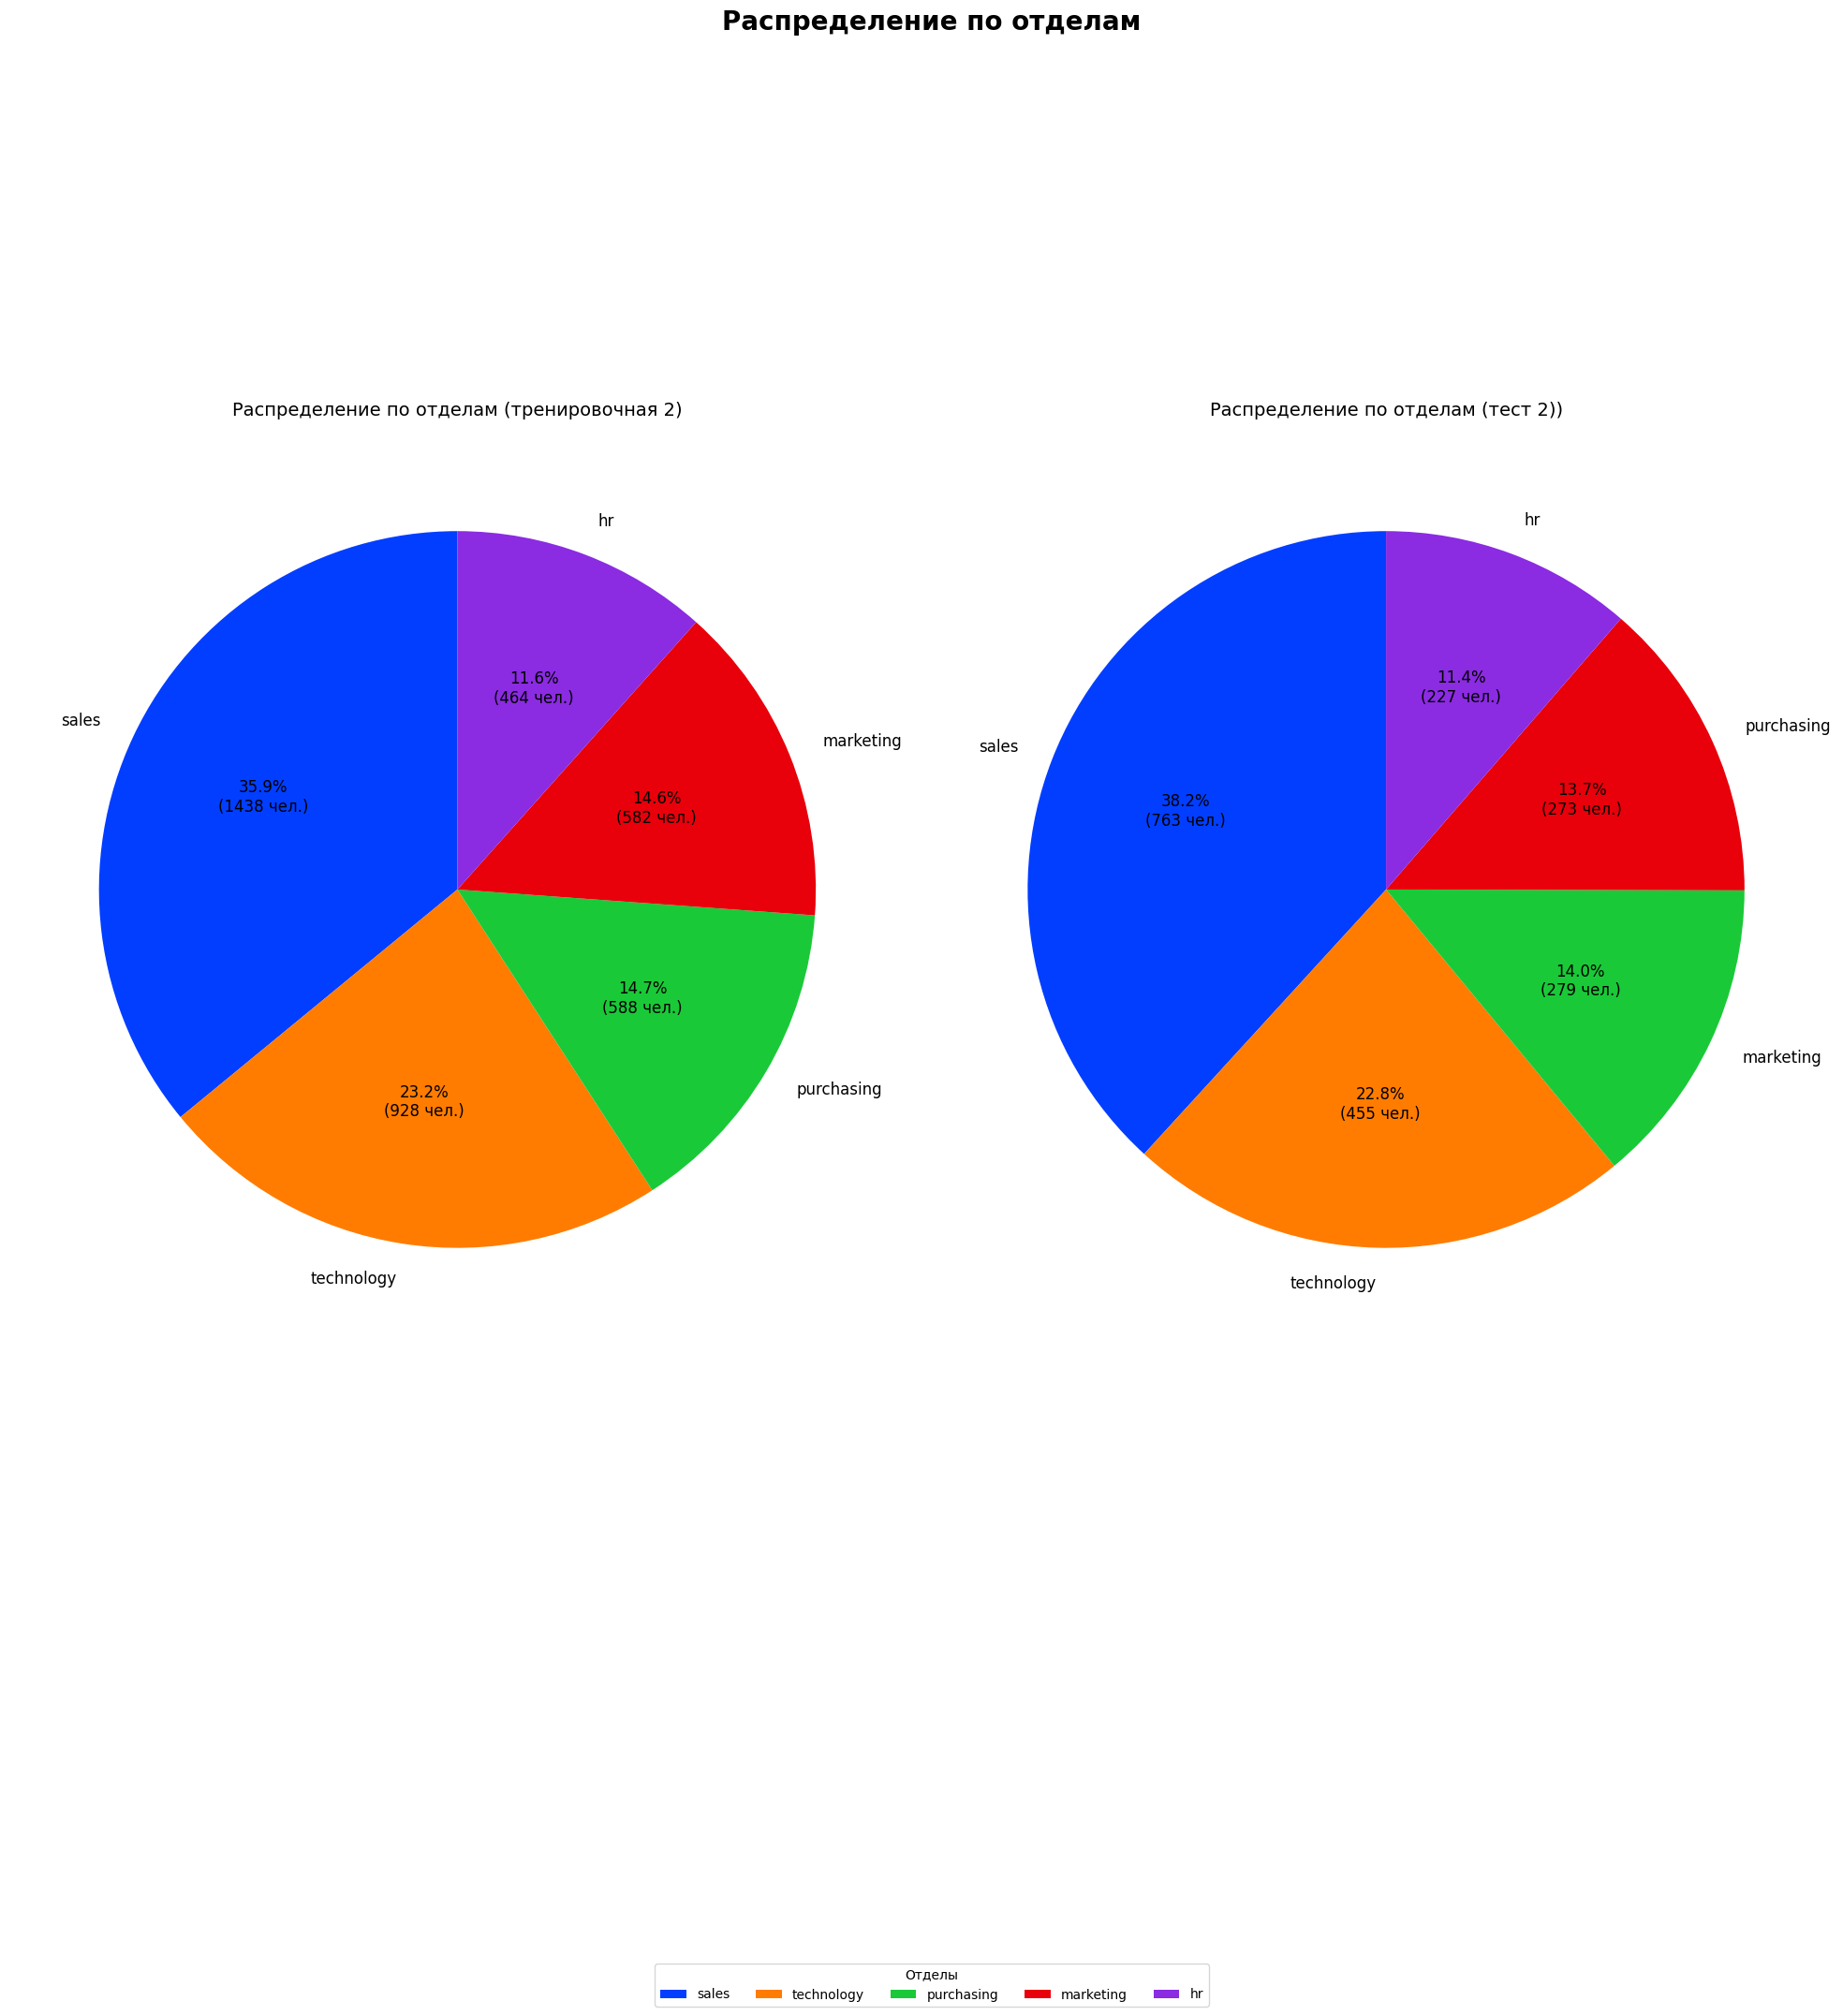

In [111]:
# Создаем фигуру с двумя subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 20))

# Цветовая палитра
palette_color = sns.color_palette('bright')

# Первая диаграмма (тренировочные данные)
train_counts = train_2['dept'].value_counts()
ax1.pie(train_counts,
        labels=train_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(train_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax1.set_title('Распределение по отделам (тренировочная 2)', pad=20, fontsize=14)

# Вторая диаграмма (тестовая выборка)
test_counts = X_test_2['dept'].value_counts()
ax2.pie(test_counts,
        labels=test_counts.index,
        autopct=lambda p: f'{p:.1f}%\n({p*sum(test_counts)/100:.0f} чел.)',
        colors=palette_color,
        startangle=90,
        textprops={'fontsize': 12})
ax2.set_title('Распределение по отделам (тест 2))', pad=20, fontsize=14)

# Общий заголовок
plt.suptitle('Распределение по отделам', y=1.02, fontsize=20, weight='bold')

# Добавляем легенду
fig.legend(train_counts.index,
           title='Отделы',
           loc='lower center',
           ncol=len(train_counts),
           bbox_to_anchor=(0.5, -0.05))

# Настройка отступов
plt.tight_layout()
plt.subplots_adjust(top=0.85, bottom=0.25)  # Регулируем для легенды
plt.show()


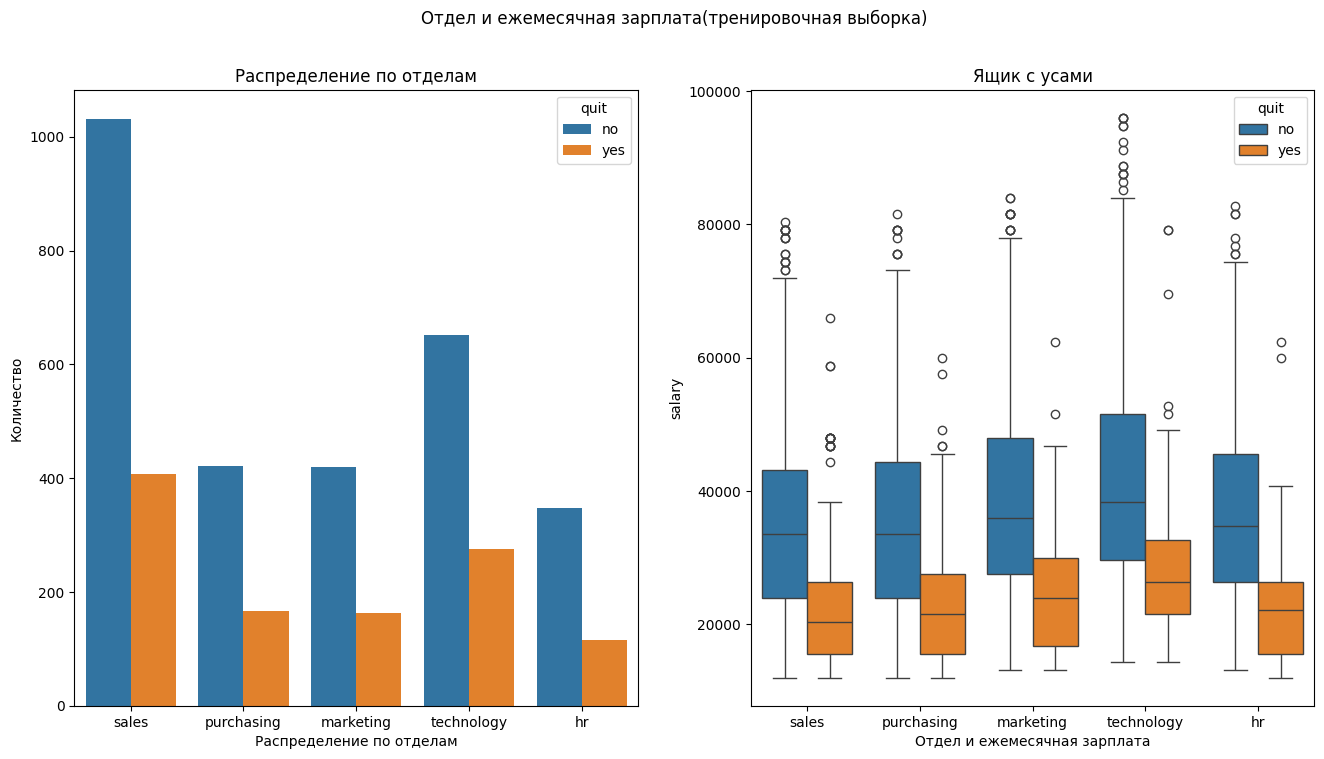

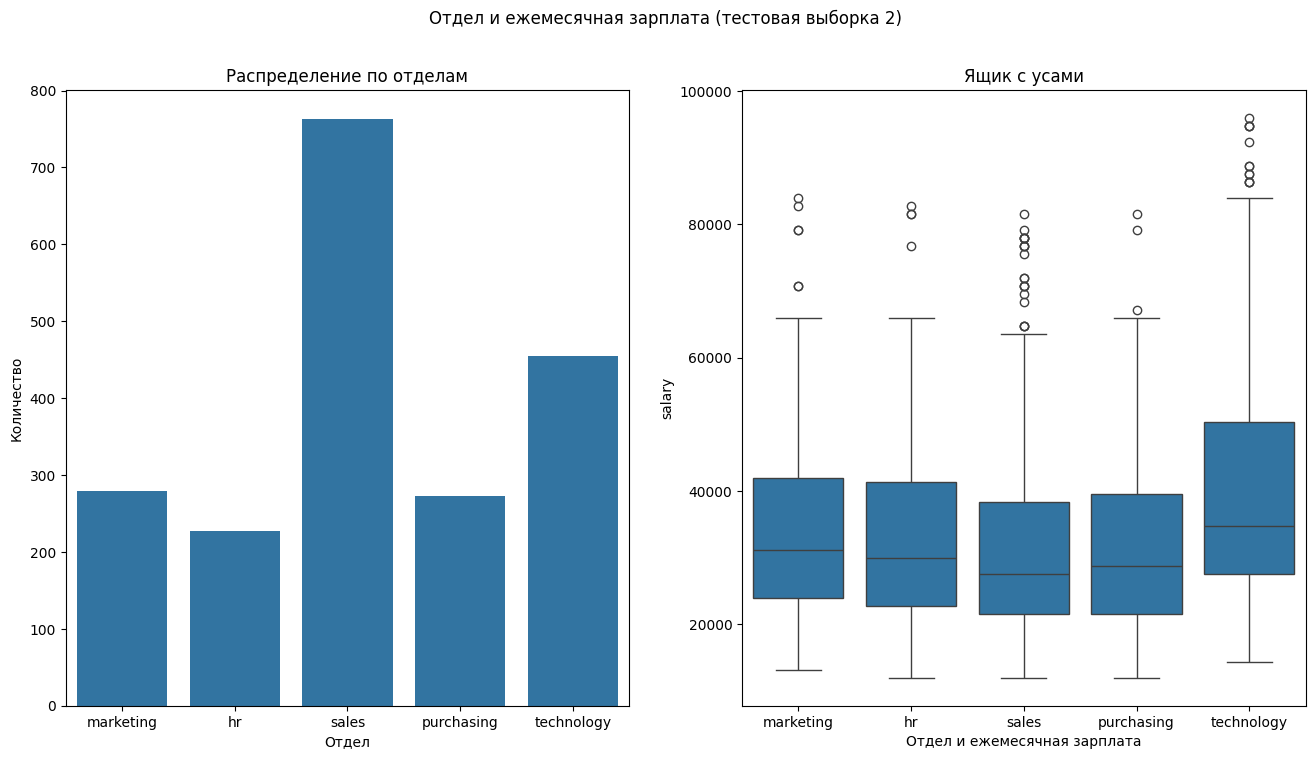

In [112]:
# Ежемесячная зарплата сотрудников трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=train_2, x="dept", hue="quit", ax=axs[0])
axs[0].set_xlabel('Распределение по отделам')
axs[0].set_ylabel('Количество')
axs[0].set_title('Распределение по отделам')
sn.boxplot(data = train_2, x = 'dept', y='salary', hue='quit')
axs[1].set_xlabel('Отдел и ежемесячная зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Отдел и ежемесячная зарплата(тренировочная выборка)')
plt.show()

# Ежемесячная зарплата сотрудников тест
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=X_test_2, x="dept", ax=axs[0])
axs[0].set_xlabel('Отдел')
axs[0].set_ylabel('Количество')
axs[0].set_title('Распределение по отделам')
sn.boxplot(data = X_test_2, x = 'dept', y='salary')
axs[1].set_xlabel('Отдел и ежемесячная зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Отдел и ежемесячная зарплата (тестовая выборка 2)')
plt.show()

Графики показывают, что в разных отделах разное количество человек.

По количеству они примерно совпадают в тестовой и тренеровочной выборках.

Уходит сотрудников в соотношении с количеством народа в отделах - одинаковые доли в отделах.

Из графика барплот видно - уходят сотрудники с минимальными зарплатами.

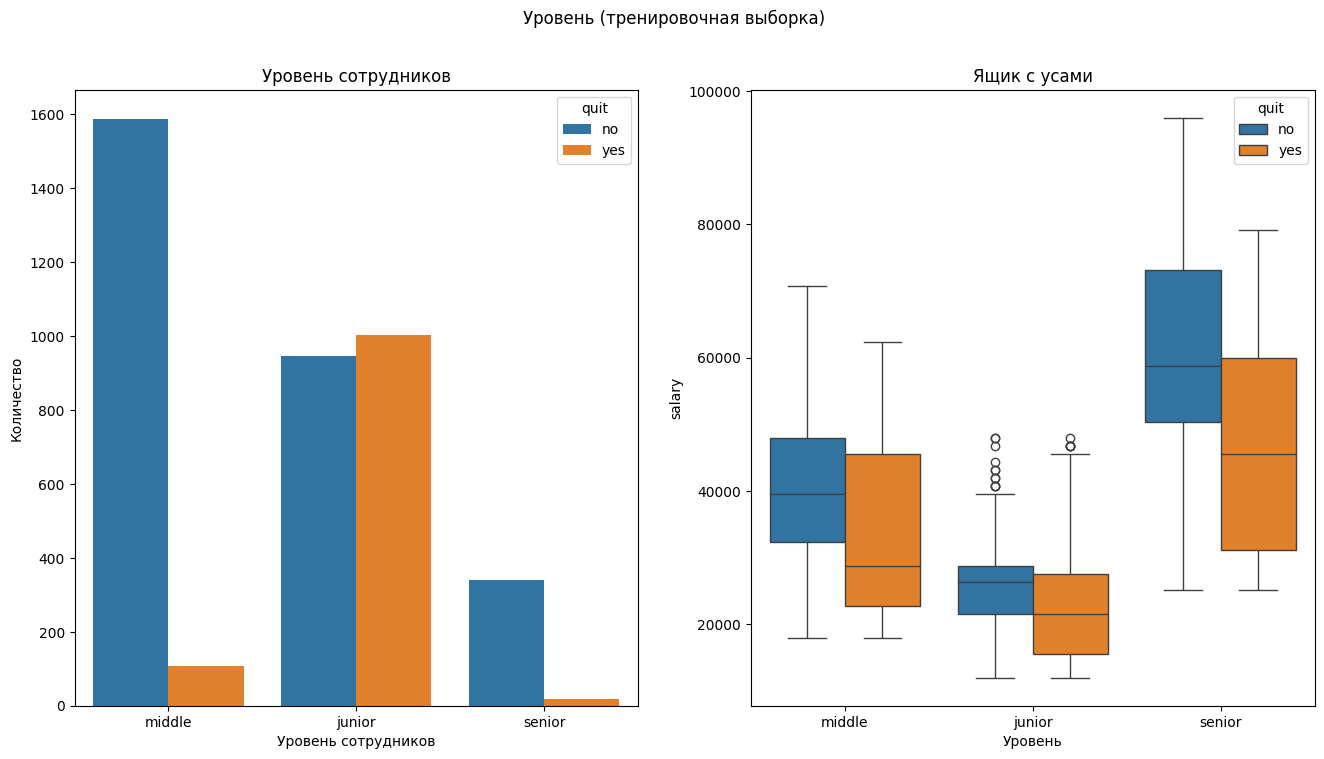

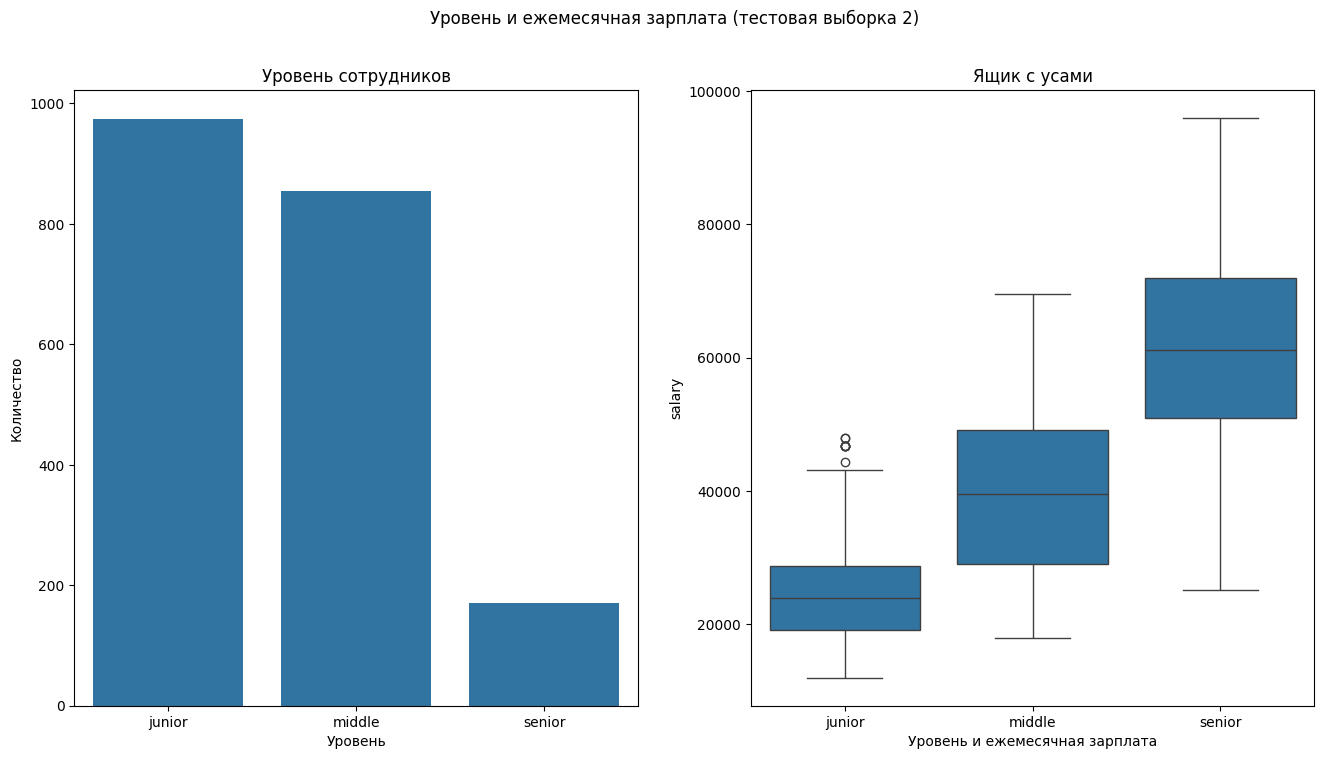

In [113]:
# Уровень сотрудников трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=train_2, x="level", hue="quit", ax=axs[0])
axs[0].set_xlabel('Уровень сотрудников')
axs[0].set_ylabel('Количество')
axs[0].set_title('Уровень сотрудников')
sn.boxplot(data = train_2, x = 'level', y='salary', hue='quit')
axs[1].set_xlabel('Уровень')
axs[1].set_title('Ящик с усами')
fig.suptitle('Уровень (тренировочная выборка)')
plt.show()

# Ежемесячная зарплата сотрудников тест
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=X_test_2, x="level", ax=axs[0])
axs[0].set_xlabel('Уровень')
axs[0].set_ylabel('Количество')
axs[0].set_title('Уровень сотрудников')
sn.boxplot(data = X_test_2, x = 'level', y='salary')
axs[1].set_xlabel('Уровень и ежемесячная зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Уровень и ежемесячная зарплата (тестовая выборка 2)')
plt.show()

Графики показывают, что уходят восновном джуны, медианный уровень зарплаты которых на уровне 25 перцентиля от зарплат неуходящих. То есть сотрудники джуны с зп на нижней границе.

Мало, но уходят и мидл. Они также уходят по причине низкой зарплаты - когда ее медианное значение сопоставимо с джунами, мидлы уходят.

Когда разница между зарплатами джун, мидл, сеньер большая, как показано на ящике с усами тестовой выборки, сотрудники остаются.

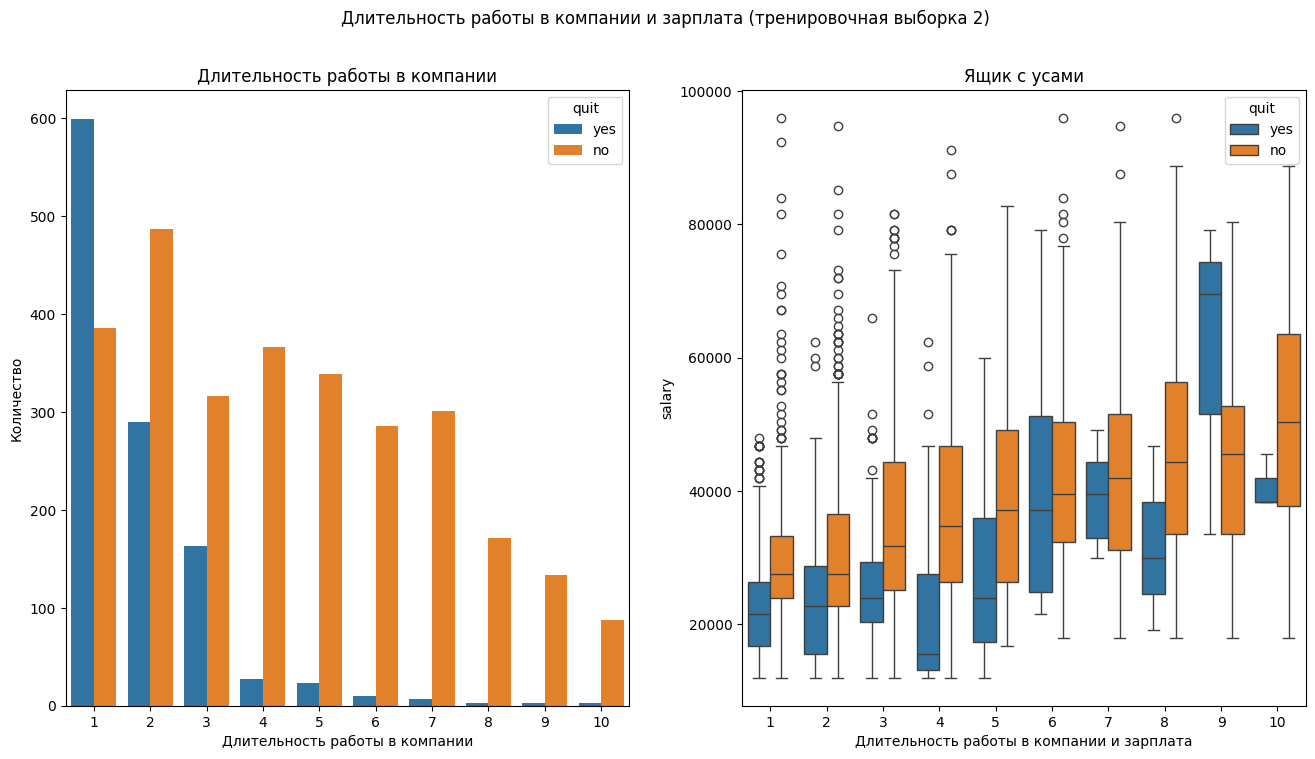

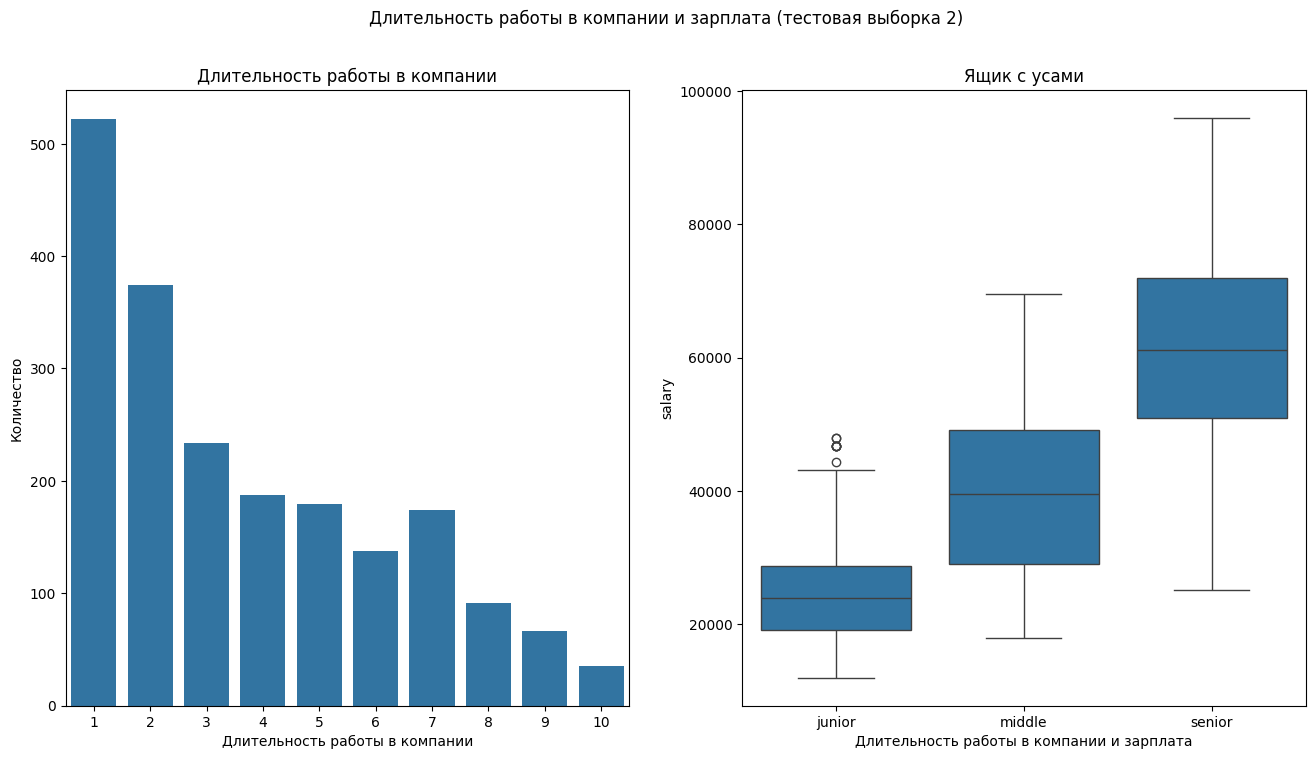

In [114]:
# Длительность работы в компании трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=train_2, x="employment_years", hue="quit", ax=axs[0])
axs[0].set_xlabel('Длительность работы в компании')
axs[0].set_ylabel('Количество')
axs[0].set_title('Длительность работы в компании')
sn.boxplot(data = train_2, x = 'employment_years', y='salary', hue='quit')
axs[1].set_xlabel('Длительность работы в компании и зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Длительность работы в компании и зарплата (тренировочная выборка 2)')
plt.show()

# Длительность работы в компании тест
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=X_test_2, x="employment_years", ax=axs[0])
axs[0].set_xlabel('Длительность работы в компании')
axs[0].set_ylabel('Количество')
axs[0].set_title('Длительность работы в компании')
sn.boxplot(data = X_test_2, x = 'level', y='salary')
axs[1].set_xlabel('Длительность работы в компании и зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Длительность работы в компании и зарплата (тестовая выборка 2)')
plt.show()

Уходят сотрудники, чья зарплата совсем сильно отличается от сотрудников, проработавших столько же лет.

Также из графиков сидно, что наиболее часто из компании уходят сотрудники с минимальным количеством отработанного времени.

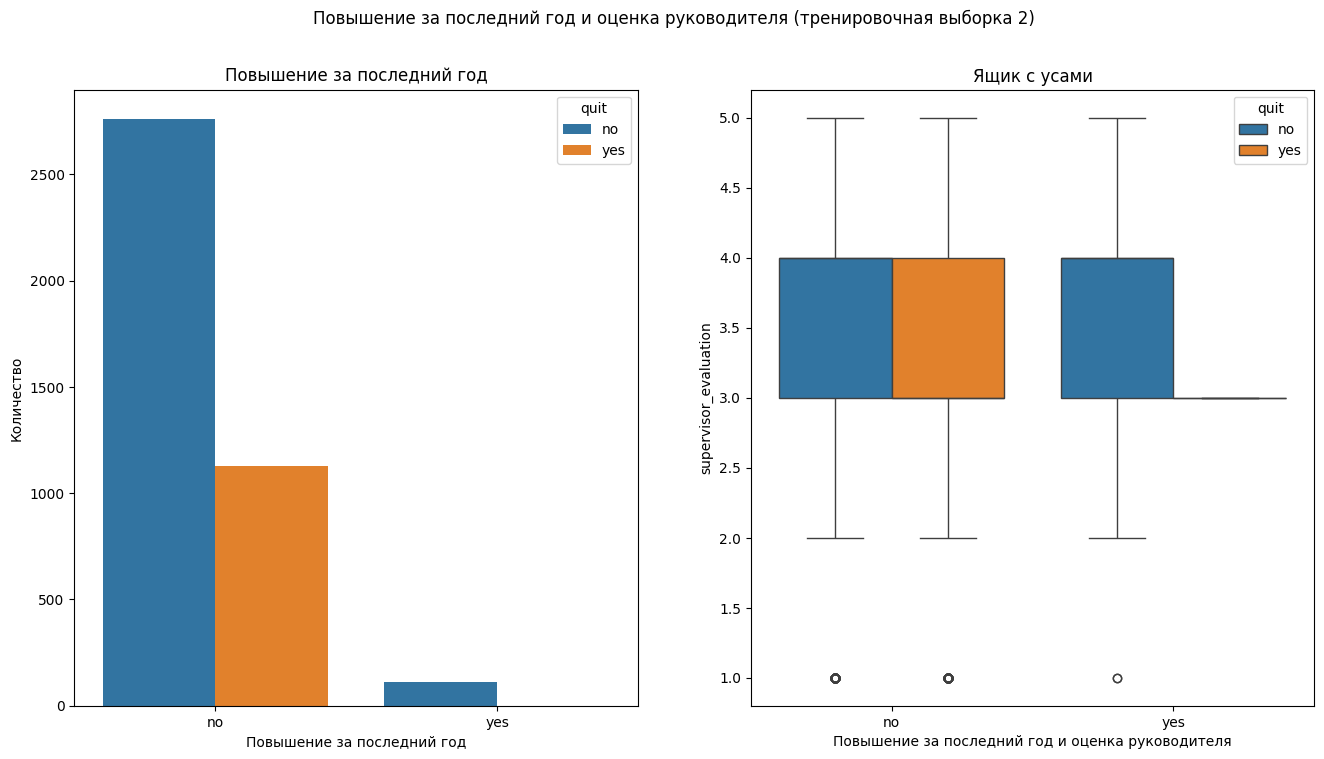

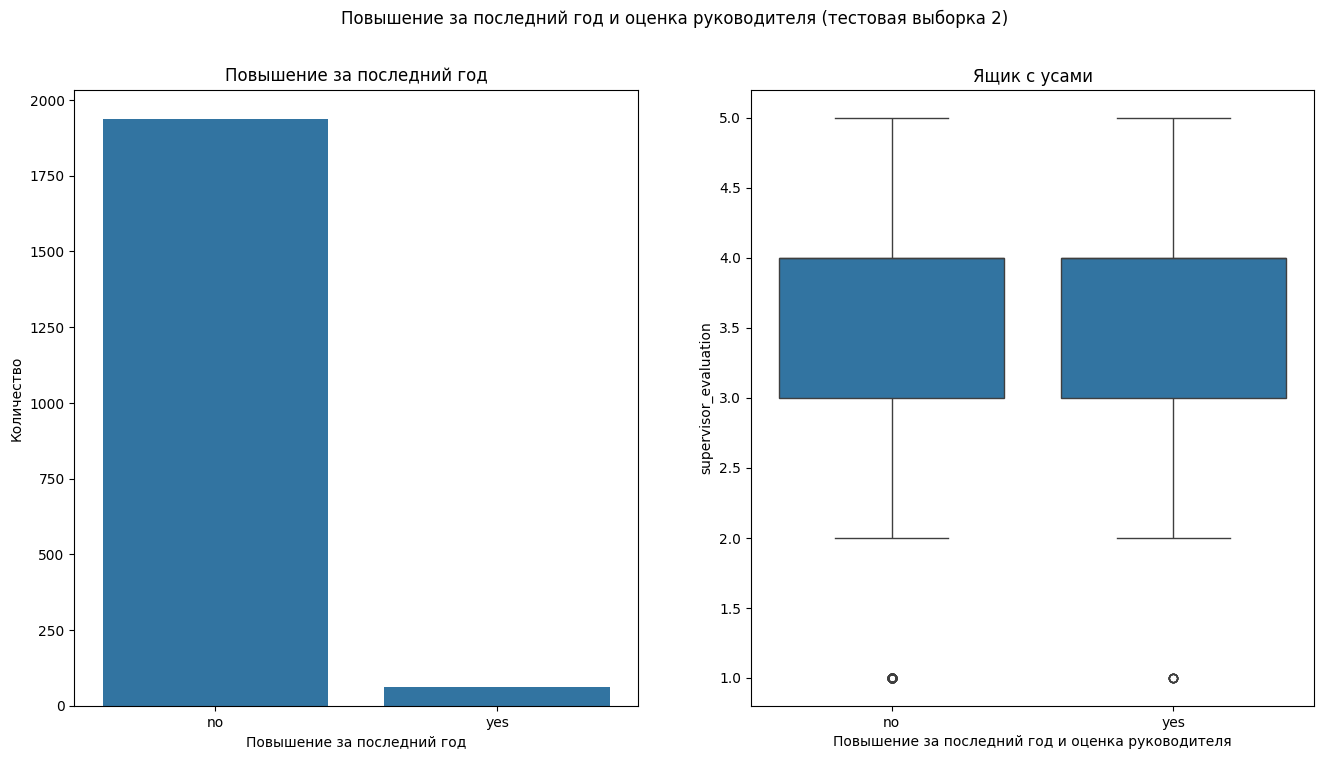

In [115]:
# Уровень сотрудников трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=train_2, x="last_year_promo", hue="quit", ax=axs[0])
axs[0].set_xlabel('Повышение за последний год')
axs[0].set_ylabel('Количество')
axs[0].set_title('Повышение за последний год')
sn.boxplot(data = train_2, x = 'last_year_promo', y='supervisor_evaluation', hue='quit')
axs[1].set_xlabel('Повышение за последний год и оценка руководителя')
axs[1].set_title('Ящик с усами')
fig.suptitle('Повышение за последний год и оценка руководителя (тренировочная выборка 2)')
plt.show()

# Ежемесячная зарплата сотрудников тест
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=X_test_2, x="last_year_promo", ax=axs[0])
axs[0].set_xlabel('Повышение за последний год')
axs[0].set_ylabel('Количество')
axs[0].set_title('Повышение за последний год')
sn.boxplot(data = X_test_2, x = 'last_year_promo', y='supervisor_evaluation')
axs[1].set_xlabel('Повышение за последний год и оценка руководителя')
axs[1].set_title('Ящик с усами')
fig.suptitle('Повышение за последний год и оценка руководителя (тестовая выборка 2)')
plt.show()

Если повышения не было, то оценка руководства не влияет на уход. Уходят и остаются одинаково.

Если повышение было, то сотрудники практически не уходят.

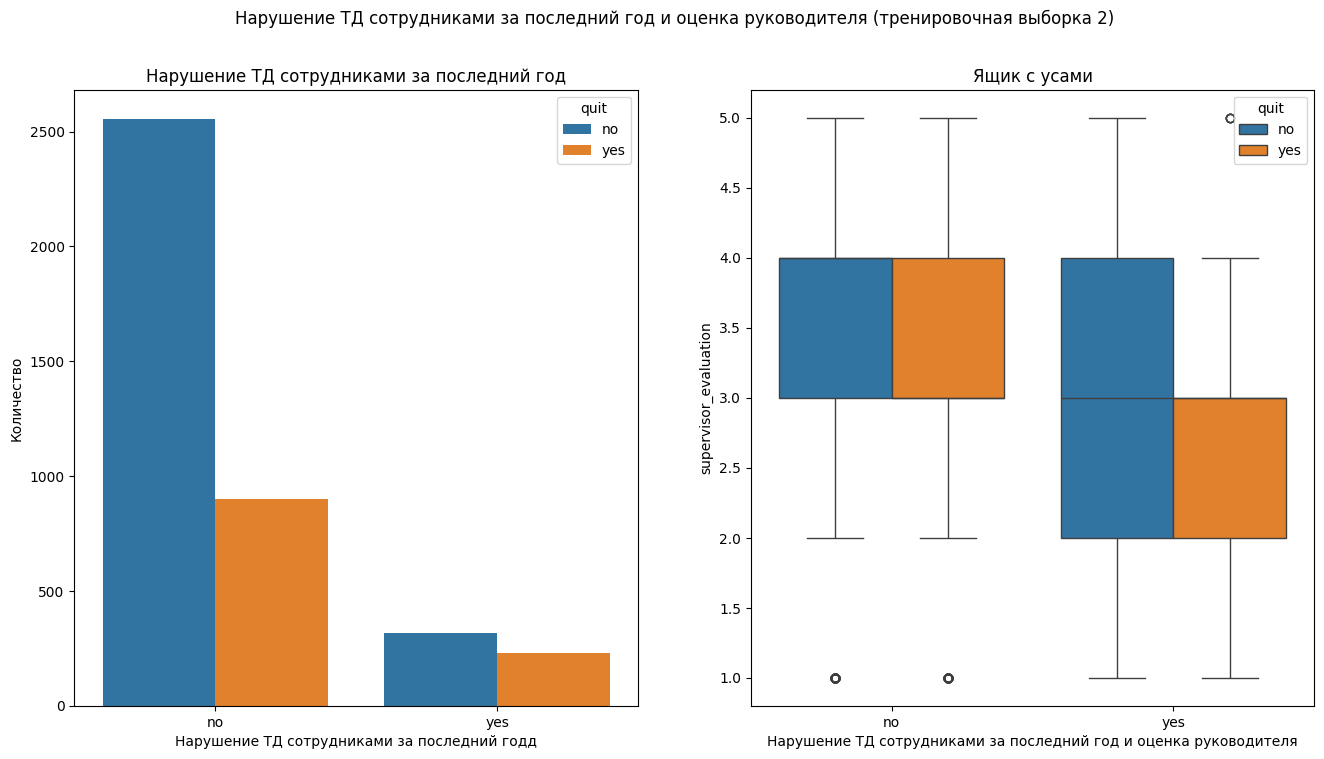

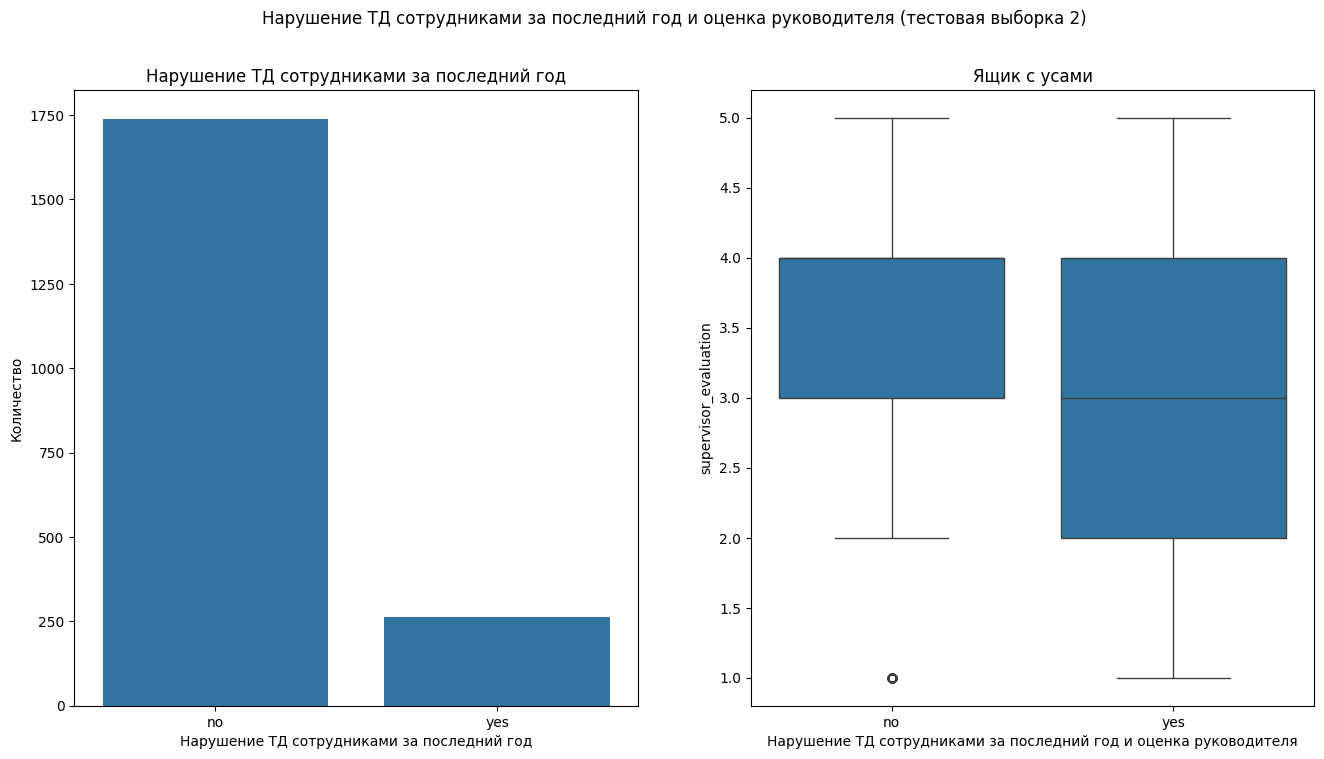

In [116]:
# Нарушение ТД сотрудниками за последний год трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=train_2, x="last_year_violations", hue="quit", ax=axs[0])
axs[0].set_xlabel('Нарушение ТД сотрудниками за последний годд')
axs[0].set_ylabel('Количество')
axs[0].set_title('Нарушение ТД сотрудниками за последний год')
sn.boxplot(data = train_2, x = 'last_year_violations', y='supervisor_evaluation', hue='quit')
axs[1].set_xlabel('Нарушение ТД сотрудниками за последний год и оценка руководителя')
axs[1].set_title('Ящик с усами')
fig.suptitle('Нарушение ТД сотрудниками за последний год и оценка руководителя (тренировочная выборка 2)')
plt.show()

# Нарушение ТД сотрудниками за последний год тест
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=X_test_2, x="last_year_violations",  ax=axs[0])
axs[0].set_xlabel('Нарушение ТД сотрудниками за последний год')
axs[0].set_ylabel('Количество')
axs[0].set_title('Нарушение ТД сотрудниками за последний год')
sn.boxplot(data = X_test_2, x = 'last_year_violations', y='supervisor_evaluation')
axs[1].set_xlabel('Нарушение ТД сотрудниками за последний год и оценка руководителя')
axs[1].set_title('Ящик с усами')
fig.suptitle('Нарушение ТД сотрудниками за последний год и оценка руководителя (тестовая выборка 2)')
plt.show()

In [117]:
train_2.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no
814010,sales,junior,medium,2,no,no,4,27600,no


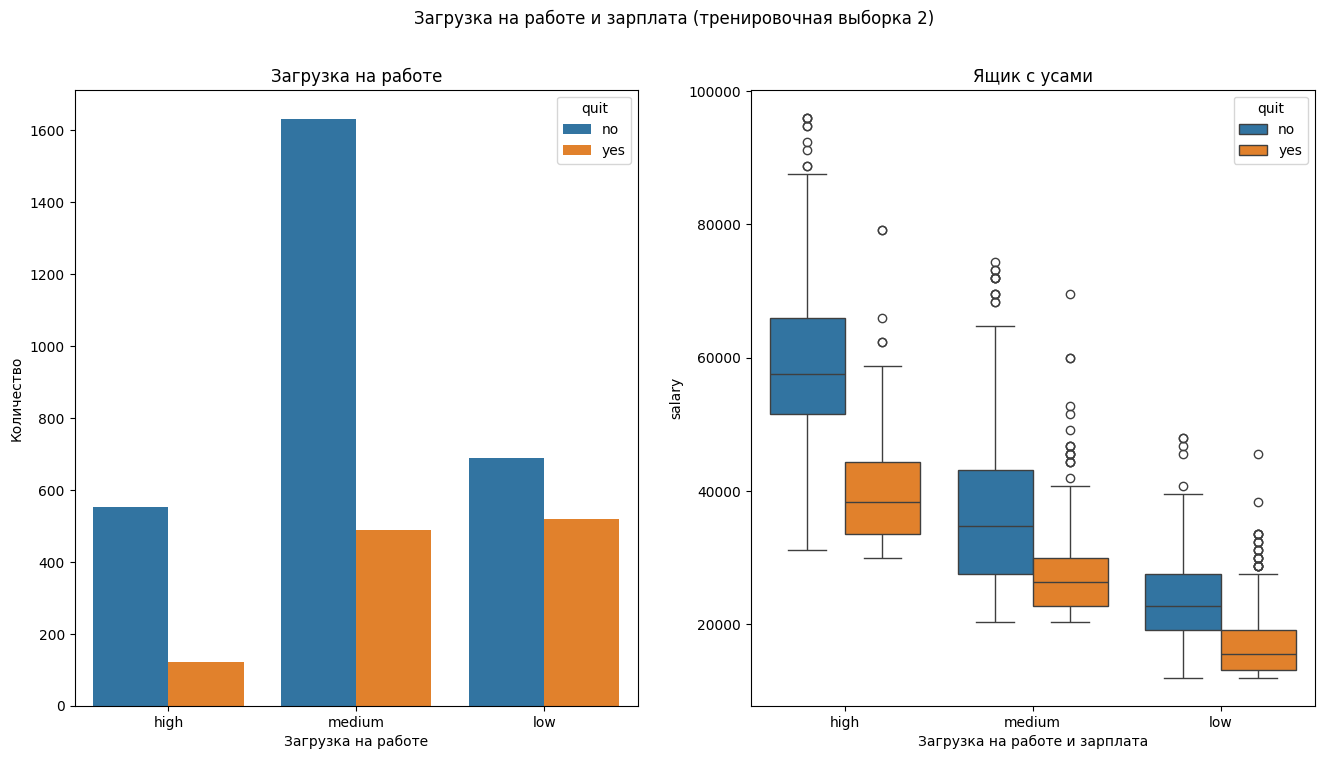

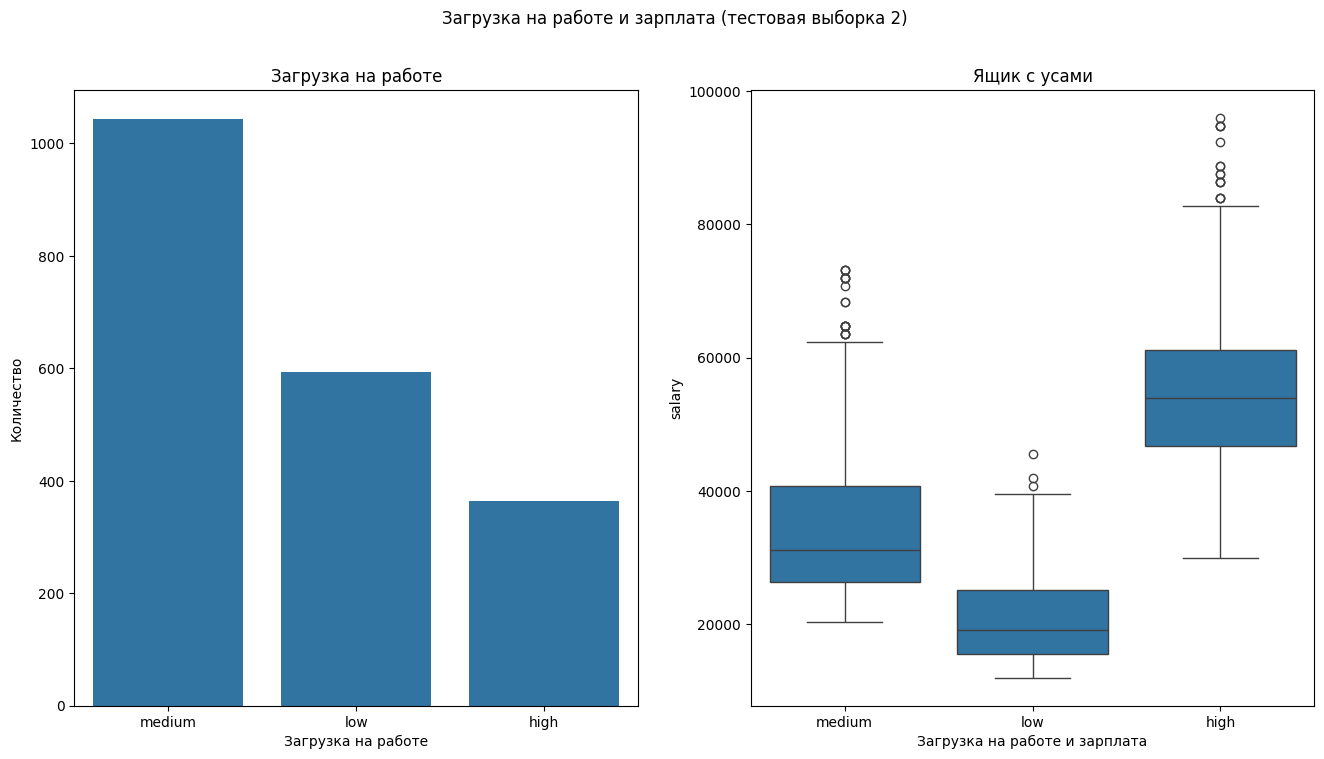

In [118]:
# Загрузка на работе трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=train_2, x="workload", hue="quit", ax=axs[0])
axs[0].set_xlabel('Загрузка на работе')
axs[0].set_ylabel('Количество')
axs[0].set_title('Загрузка на работе')
sn.boxplot(data = train_2, x = 'workload', y='salary', hue='quit')
axs[1].set_xlabel('Загрузка на работе и зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Загрузка на работе и зарплата (тренировочная выборка 2)')
plt.show()

# Загрузка на работе тест
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=X_test_2, x="workload", ax=axs[0])
axs[0].set_xlabel('Загрузка на работе')
axs[0].set_ylabel('Количество')
axs[0].set_title('Загрузка на работе')
sn.boxplot(data = X_test_2, x = 'workload', y='salary')
axs[1].set_xlabel('Загрузка на работе и зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Загрузка на работе и зарплата (тестовая выборка 2)')
plt.show()

Уходят сотрудники с сильно большой разницей между зарплатами и одинаковой нагрузкой.

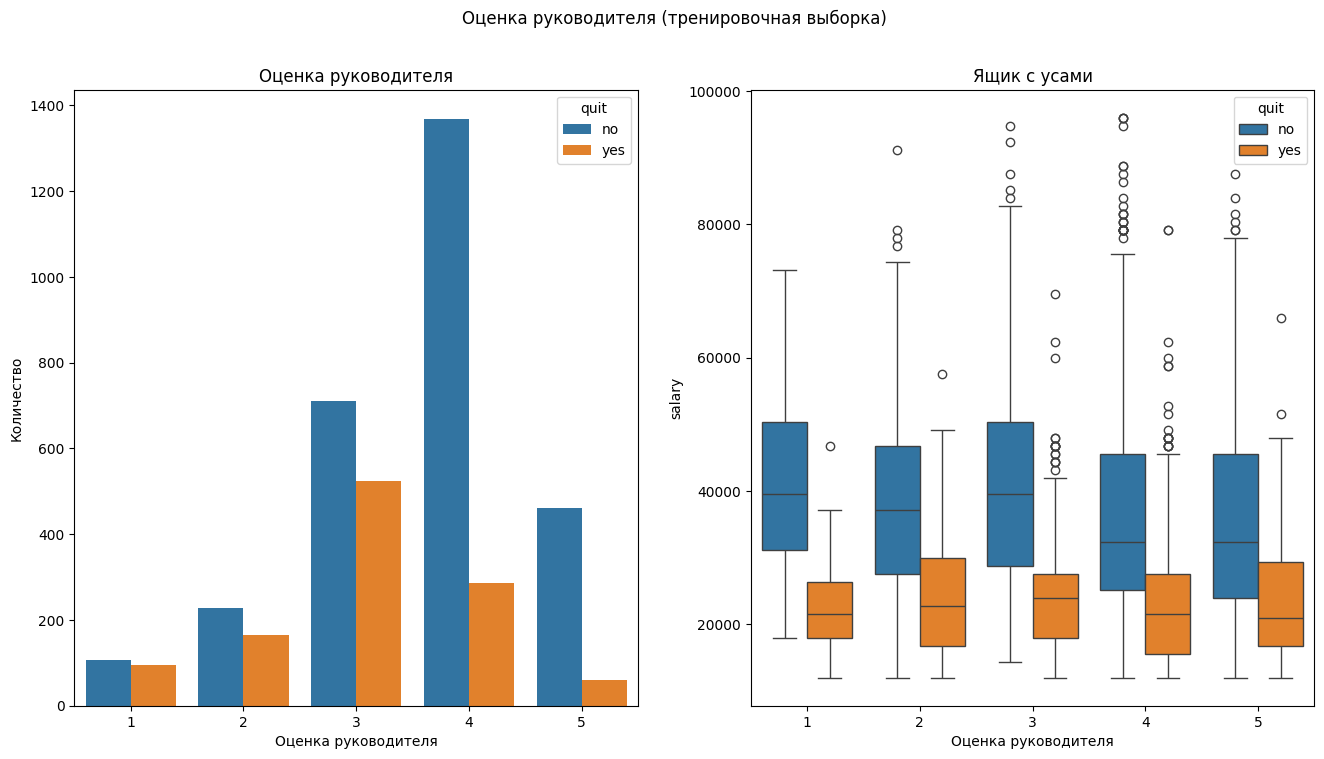

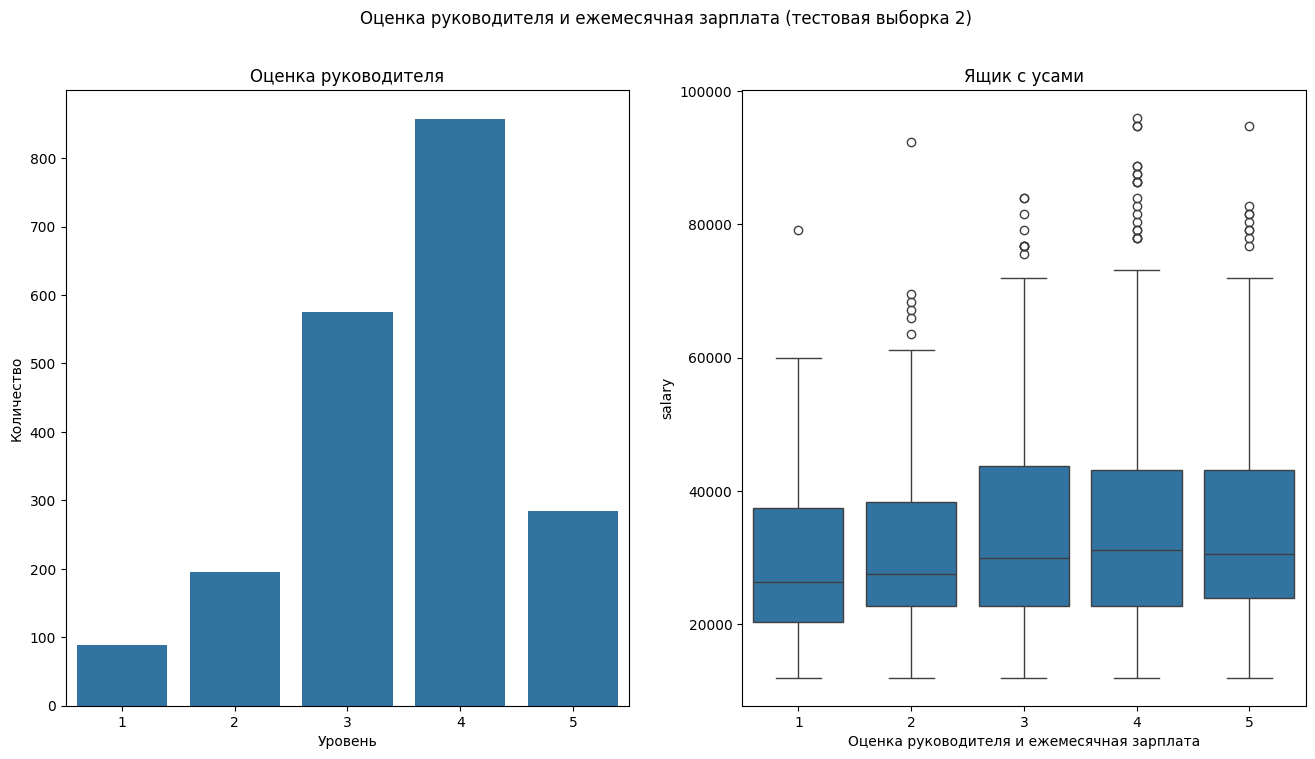

In [119]:
# оценка руководителя отдельно трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=train_2, x="supervisor_evaluation", hue="quit", ax=axs[0])
axs[0].set_xlabel('Оценка руководителя')
axs[0].set_ylabel('Количество')
axs[0].set_title('Оценка руководителя')
sn.boxplot(data = train_2, x = 'supervisor_evaluation', y='salary', hue='quit')
axs[1].set_xlabel('Оценка руководителя')
axs[1].set_title('Ящик с усами')
fig.suptitle('Оценка руководителя (тренировочная выборка)')
plt.show()

# оценка руководителя отдельно тест
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=X_test_2, x="supervisor_evaluation", ax=axs[0])
axs[0].set_xlabel('Уровень')
axs[0].set_ylabel('Количество')
axs[0].set_title('Оценка руководителя')
sn.boxplot(data = X_test_2, x = 'supervisor_evaluation', y='salary')
axs[1].set_xlabel('Оценка руководителя и ежемесячная зарплата')
axs[1].set_title('Ящик с усами')
fig.suptitle('Оценка руководителя и ежемесячная зарплата (тестовая выборка 2)')
plt.show()

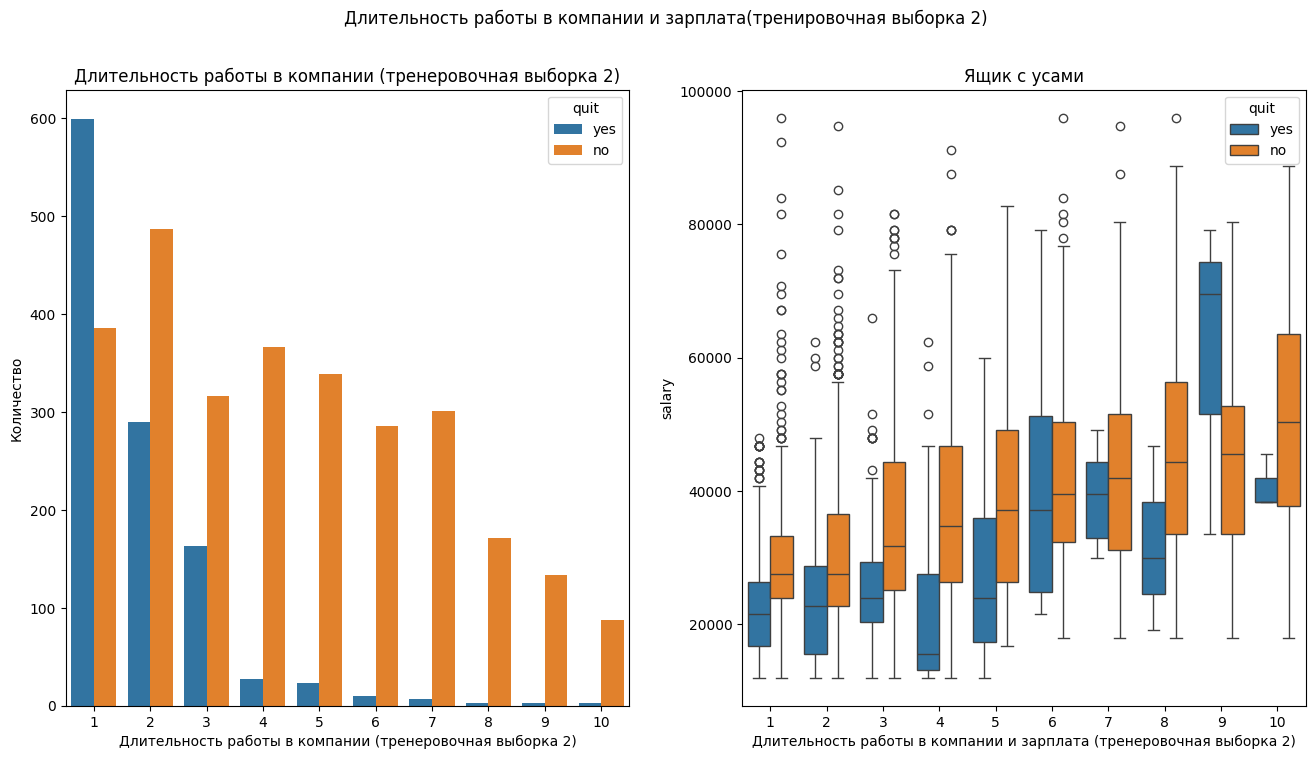

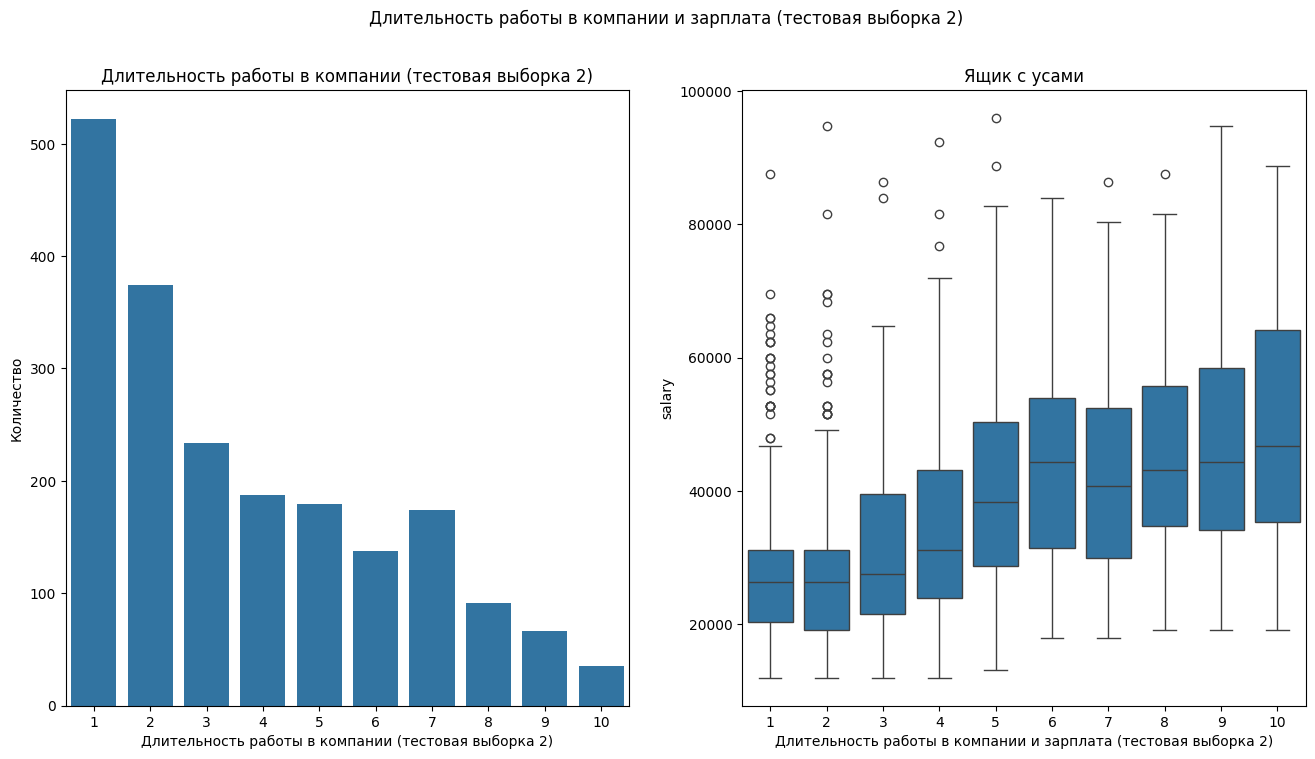

In [120]:
# Загрузка на работе трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=train_2, x="employment_years", hue="quit", ax=axs[0])
axs[0].set_xlabel('Длительность работы в компании (тренеровочная выборка 2)')
axs[0].set_ylabel('Количество')
axs[0].set_title('Длительность работы в компании (тренеровочная выборка 2)')
sn.boxplot(data = train_2, x = 'employment_years', y='salary', hue='quit')
axs[1].set_xlabel('Длительность работы в компании и зарплата (тренеровочная выборка 2)')
axs[1].set_title('Ящик с усами')
fig.suptitle('Длительность работы в компании и зарплата(тренировочная выборка 2)')
plt.show()

# Загрузка на работе тест
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=X_test_2, x="employment_years", ax=axs[0])
axs[0].set_xlabel('Длительность работы в компании (тестовая выборка 2)')
axs[0].set_ylabel('Количество')
axs[0].set_title('Длительность работы в компании (тестовая выборка 2)')
sn.boxplot(data = X_test_2, x = 'employment_years', y='salary')
axs[1].set_xlabel('Длительность работы в компании и зарплата (тестовая выборка 2)')
axs[1].set_title('Ящик с усами')
fig.suptitle('Длительность работы в компании и зарплата (тестовая выборка 2)')
plt.show()

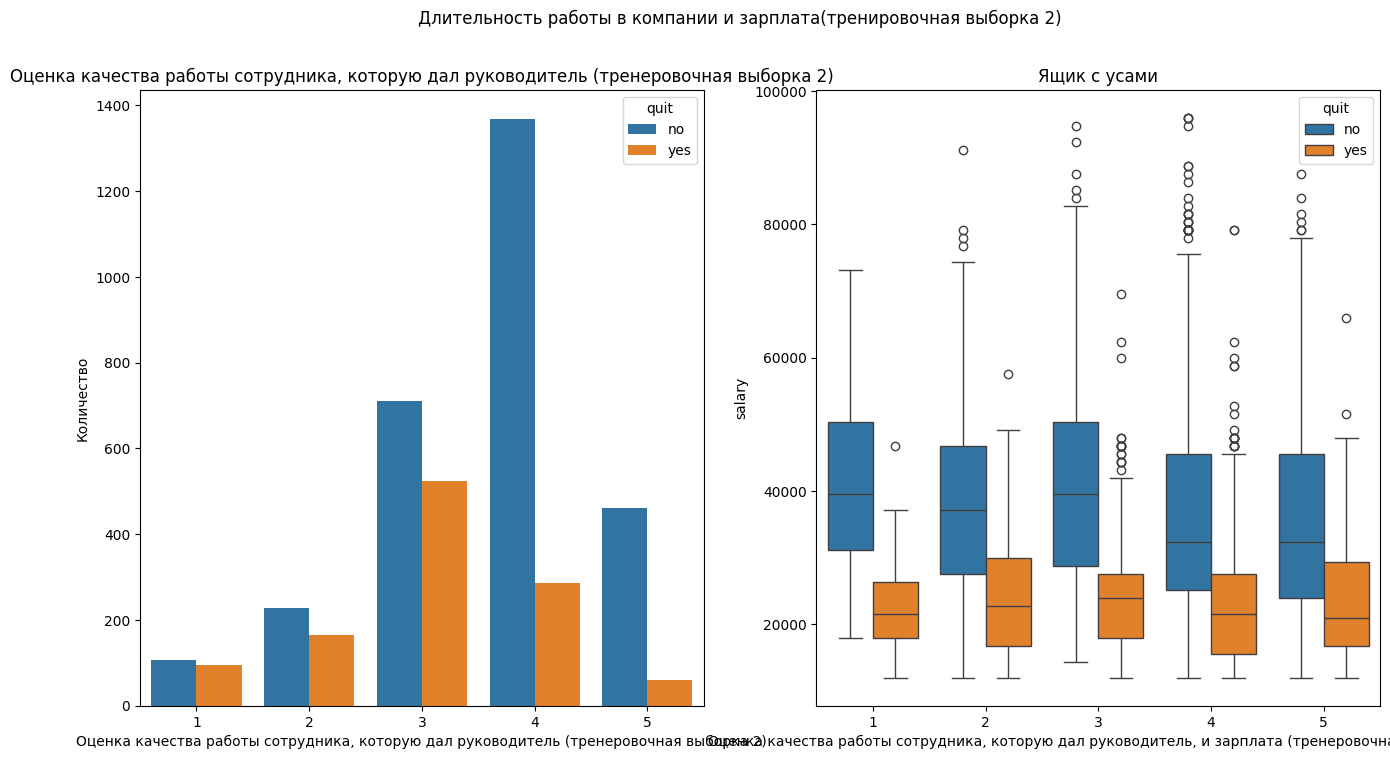

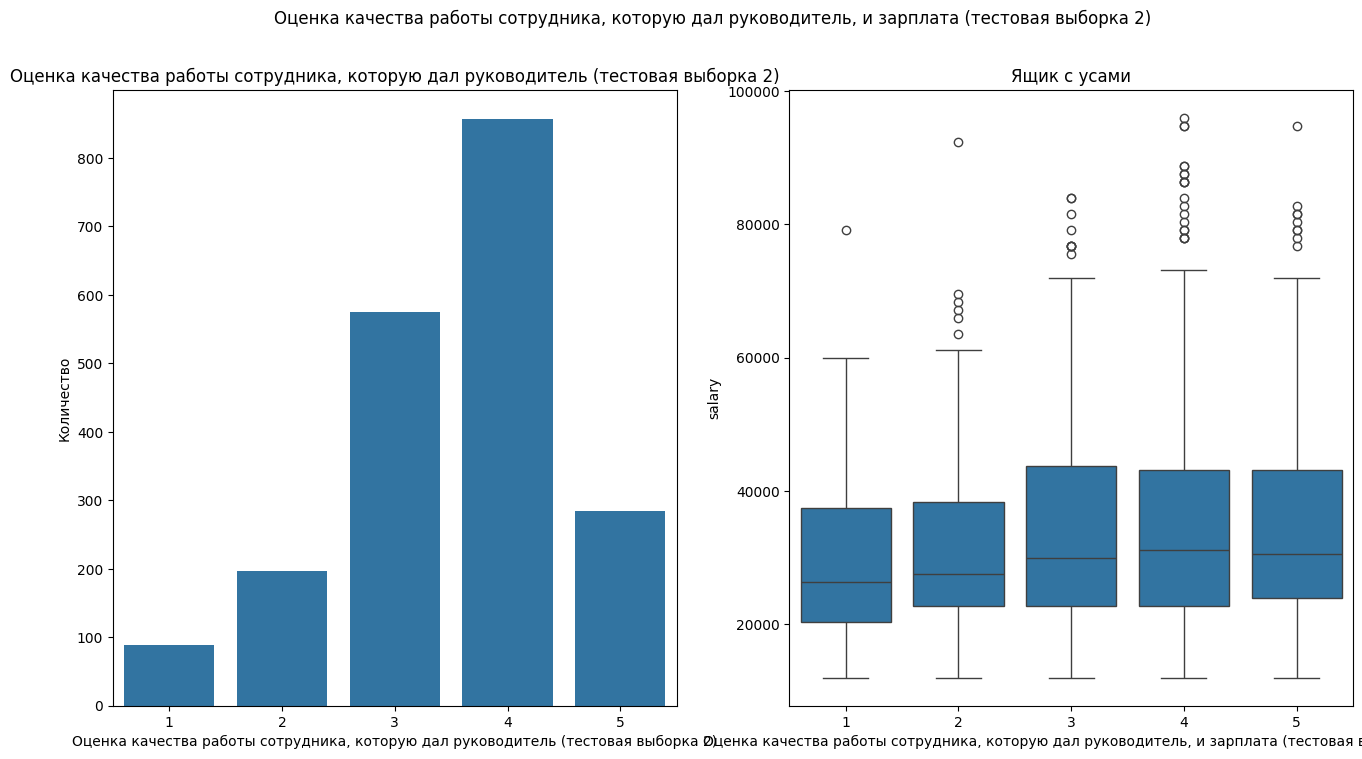

In [121]:
# Загрузка на работе трэйн
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=train_2, x="supervisor_evaluation", hue="quit", ax=axs[0])
axs[0].set_xlabel('Оценка качества работы сотрудника, которую дал руководитель (тренеровочная выборка 2)')
axs[0].set_ylabel('Количество')
axs[0].set_title('Оценка качества работы сотрудника, которую дал руководитель (тренеровочная выборка 2)')
sn.boxplot(data = train_2, x = 'supervisor_evaluation', y='salary', hue='quit')
axs[1].set_xlabel('Оценка качества работы сотрудника, которую дал руководитель, и зарплата (тренеровочная выборка 2)')
axs[1].set_title('Ящик с усами')
fig.suptitle('Длительность работы в компании и зарплата(тренировочная выборка 2)')
plt.show()

# Загрузка на работе тест
fig, axs = plt.subplots(nrows= 1 , ncols= 2, figsize = (16,8))
sns.countplot(data=X_test_2, x="supervisor_evaluation", ax=axs[0])
axs[0].set_xlabel('Оценка качества работы сотрудника, которую дал руководитель (тестовая выборка 2)')
axs[0].set_ylabel('Количество')
axs[0].set_title('Оценка качества работы сотрудника, которую дал руководитель (тестовая выборка 2)')
sn.boxplot(data = X_test_2, x = 'supervisor_evaluation', y='salary')
axs[1].set_xlabel('Оценка качества работы сотрудника, которую дал руководитель, и зарплата (тестовая выборка 2)')
axs[1].set_title('Ящик с усами')
fig.suptitle('Оценка качества работы сотрудника, которую дал руководитель, и зарплата (тестовая выборка 2)')
plt.show()

Уходят сотрудники со всеми оценками руководителей. Доля ушедших тем больше, чем ниже оценка сотрудников руководителями. Также уход сотрудников связан с низким уровнем зарплаты относительно сотрудников с той же оценкой руководства, но остающихся в компании.

In [122]:
train_2.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no
814010,sales,junior,medium,2,no,no,4,27600,no


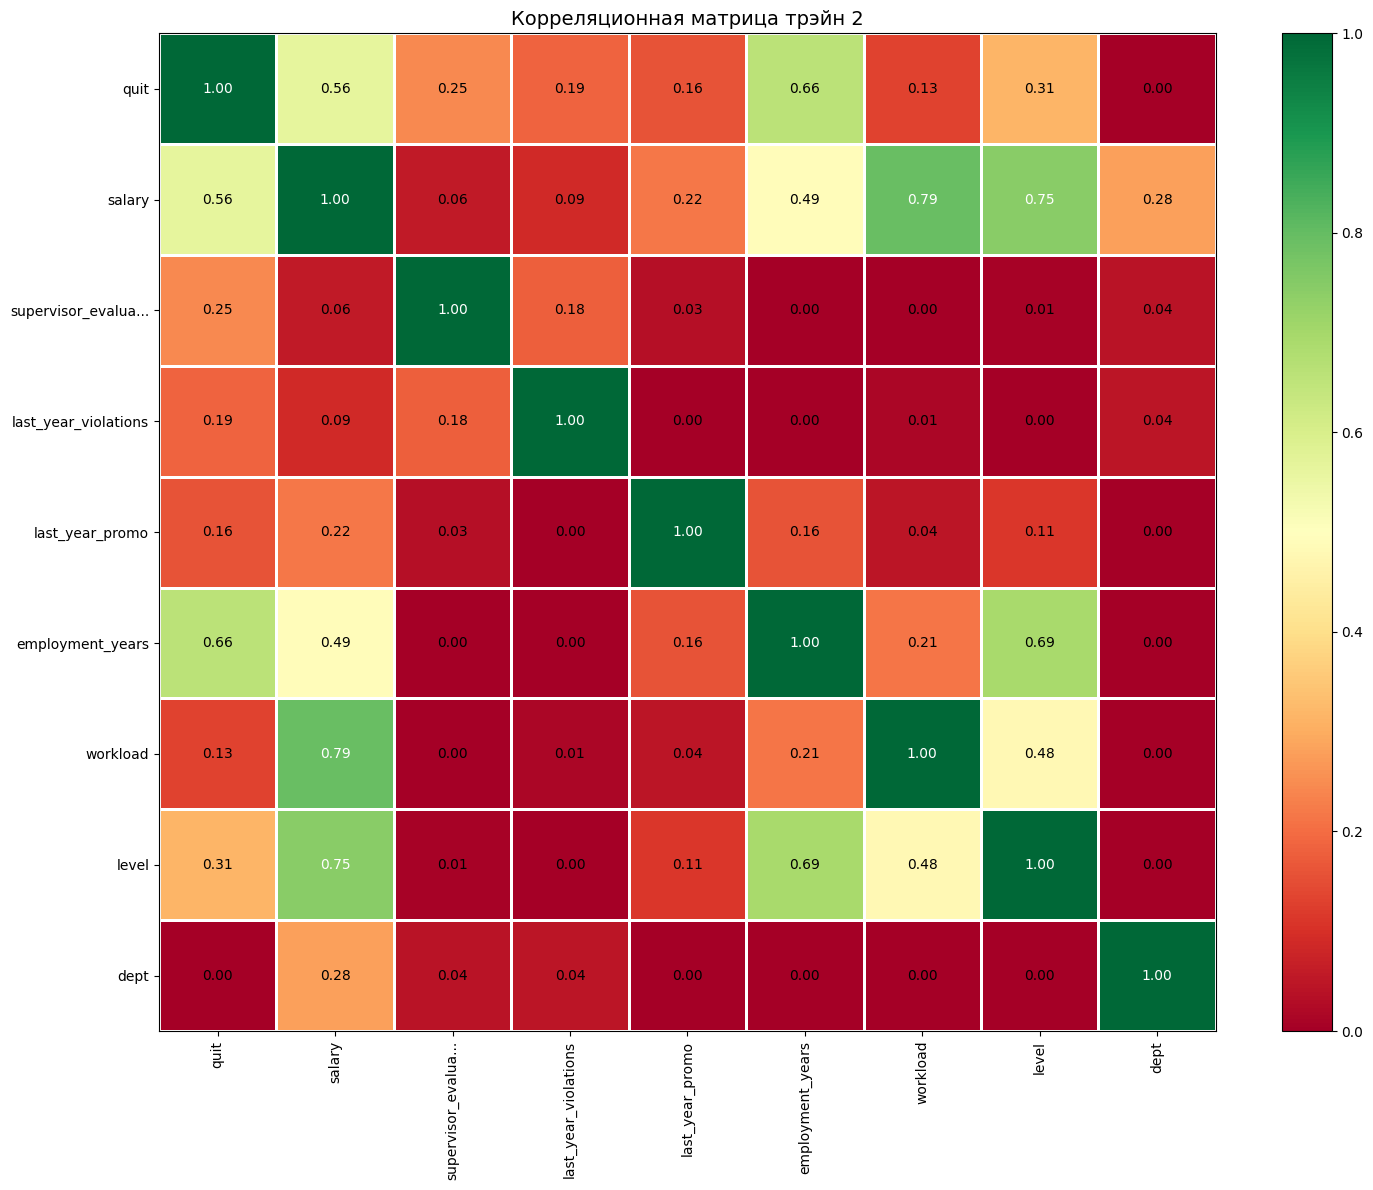

In [123]:
# Чисолвые непрерывные признаки
numeric_features = ['salary', 'job_satisfaction_rate']

# Категориальные признаки
categorical_features = ['dept']

# Оценочные признаки
ordinal_features = ['level', 'workload', 'last_year_violations', 'last_year_promo']

# Непрерывные признаки
interval_cols = numeric_features

# Корелляционная матрица трэйн выборки 2
phik_train = train_2.phik_matrix(interval_cols=interval_cols)
plot_correlation_matrix(phik_train.values,
                       x_labels=phik_train.columns,
                       y_labels=phik_train.index,
                       vmin=0, vmax=1,
                       title='Корреляционная матрица трэйн 2',
                       figsize=(15, 12))

In [124]:
X_test_2.head(1)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800


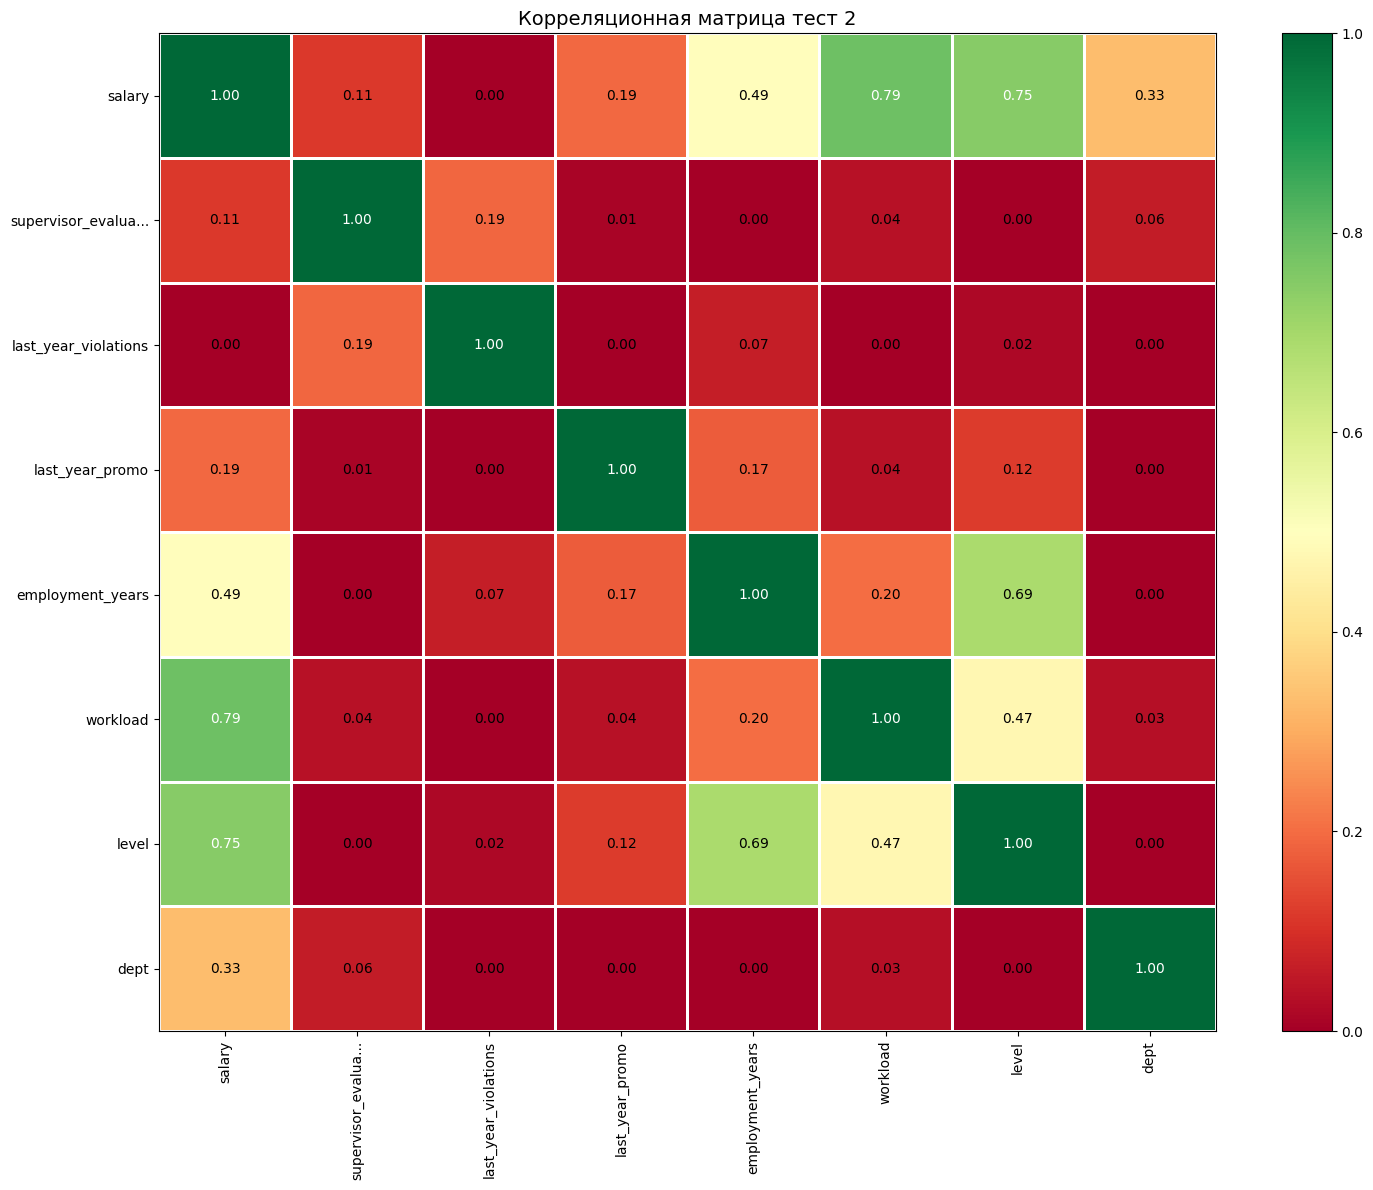

In [125]:
# Чисолвые непрерывные признаки
numeric_features = ['salary', 'job_satisfaction_rate']

# Категориальные признаки
categorical_features = ['dept']

# Оценочные признаки
ordinal_features = ['level', 'workload', 'last_year_violations', 'last_year_promo', 'quit']

# Непрерывные признаки
interval_cols = numeric_features

# Корелляционная матрица тест выборки 2
phik_train = X_test_2.phik_matrix(interval_cols=interval_cols)
plot_correlation_matrix(phik_train.values,
                       x_labels=phik_train.columns,
                       y_labels=phik_train.index,
                       vmin=0, vmax=1,
                       title='Корреляционная матрица тест 2',
                       figsize=(15, 12))

Выше 0.9 нет признаков. идем далее.

In [126]:
train_2.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no
814010,sales,junior,medium,2,no,no,4,27600,no


In [127]:
X_test_2.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary
id,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800
686555,hr,junior,medium,1,no,no,4,30000


In [128]:
y_test_2.head()

,quit
id,
999029,yes
372846,no
726767,no
490105,no
416898,yes


In [129]:
y_test_2.shape

(2000, 1)

In [130]:
y_test_1.shape

(2000, 1)

In [131]:
y_test_1

,job_satisfaction_rate
id,
100298,0.80
100480,0.84
100503,0.79
100610,0.75
100692,0.69
...,...
997290,0.79
998548,0.76
998762,0.48


In [132]:
y_predict

array([0.82      , 0.852     , 0.74666667, ..., 0.49      , 0.46428571,
       0.30714286])

#Cохраниv исходные индексы из тестовых данных
y_predict_series = pd.Series(y_predict, index=X_test_1.index, name='predicted_job_satisfaction')
y_predict_series = y_predict_series.round(3)
y_predict_series

In [133]:
# 1. Соединяем данные по ID из обеих задач
y_test_1_2 = pd.merge(y_test_2, y_test_1, on='id', how='right')
y_test_1_2.head(2)

,quit,job_satisfaction_rate
id,,
100298,no,0.80
100480,no,0.84


#Проверяем наличие столбца
if 'predicted_job_satisfaction' not in y_test_1_2.columns:
    # Добавляем столбец, если его нет (пример для модели)
    y_test_1_2['predicted_job_satisfaction'] = grid_search.predict(y_test_1_2.drop(['quit'], axis=1))

#Строим график
plt.figure(figsize=(10, 6))
sns.histplot(
    data=y_test_1_2,
    x="predicted_job_satisfaction",
    hue='quit',
    stat='density',
    common_norm=False,
    kde=True,
    alpha=0.5,
    palette=['green', 'red']
)
plt.xlabel('Уровень удовлетворённости работой')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределений удовлетворённости\nоставшихся и уволившихся сотрудников')
plt.legend(title='Уволился', labels=['да', 'нет'])
plt.show()

In [134]:
test_2_ = X_test_2
test_2_['job_satisfaction_rate'] = y_test_1['job_satisfaction_rate']
test_2_['quit'] = y_test_2['quit']

In [135]:
test_2_.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
id,,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.79,no
686555,hr,junior,medium,1,no,no,4,30000,0.72,no
467458,sales,middle,low,5,no,no,4,19200,0.64,no
418655,sales,middle,low,6,no,no,4,19200,0.60,no
789145,hr,middle,medium,5,no,no,5,40800,0.75,no


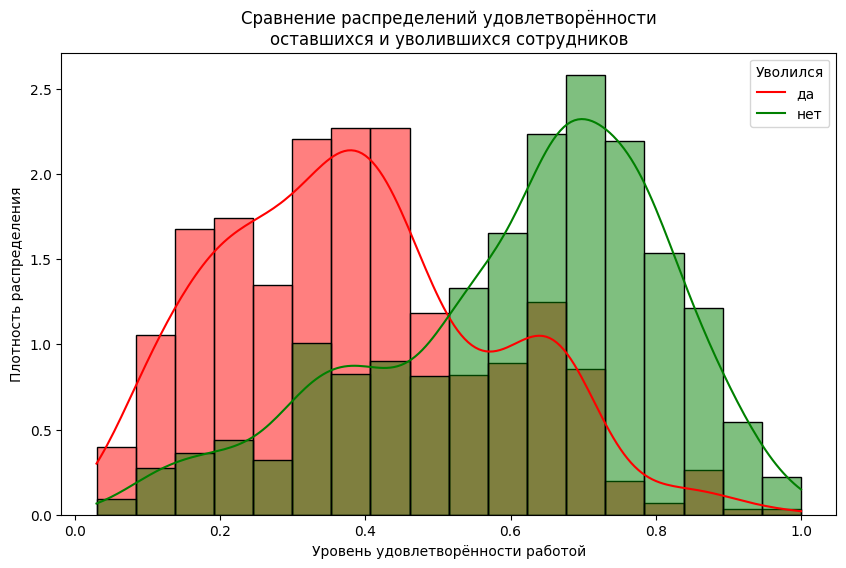

In [136]:
# Проверяем наличие столбца
if 'job_satisfaction_rate' not in test_2_.columns:
    # Добавляем столбец, если его нет (пример для модели)
    test_2_['job_satisfaction_rate'] = grid_search.predict(test_2_.drop(['quit'], axis=1))

# Строим график
plt.figure(figsize=(10, 6))
sns.histplot(
    data=test_2_,
    x="job_satisfaction_rate",
    hue='quit',
    stat='density',
    common_norm=False,
    kde=True,
    alpha=0.5,
    palette=['green', 'red']
)
plt.xlabel('Уровень удовлетворённости работой')
plt.ylabel('Плотность распределения')
plt.title('Сравнение распределений удовлетворённости\nоставшихся и уволившихся сотрудников')
plt.legend(title='Уволился', labels=['да', 'нет'])
plt.show()

Соответственно, уволившиеся сотрудники работой не удовлетворены.

Оставшиеся - удовлетворены.

Часть оставшихся не удовлетворены работой сравнимо с уже ушедшими, соответственно, данные сотрудники в скором времени могут также уйти.

### Портрет уволившегося сотрудника

In [137]:
train_2['quit']

id
723290     no
814010     no
155091     no
257132    yes
910140     no
         ... 
588809     no
672059     no
536432    yes
692133     no
853842    yes
Name: quit, Length: 4000, dtype: object

In [138]:
train_2_copy=train_2.copy()
train_2_copy.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no
814010,sales,junior,medium,2,no,no,4,27600,no
155091,purchasing,middle,medium,5,no,no,1,37200,no
257132,sales,junior,medium,2,no,yes,3,24000,yes
910140,marketing,junior,medium,2,no,no,5,25200,no


Вероятность увольнения по отделам (%):


dept
sales         36.1
technology    24.5
purchasing    14.7
marketing     14.5
hr            10.3
Name: proportion, dtype: float64


Распределение уровня загруженности уволившихся:


workload
low       0.46
medium    0.43
high      0.11
Name: proportion, dtype: float64


Средние зарплаты уволившихся:


...

last_year_violations
no     0.8
yes    0.2
Name: proportion, dtype: float64


Средняя оценка руководителем качества работы сотрудника (1-5):


,Уволившиеся
0,3.05



Распределение оценок руководителя уволившихся сотрудников (доли):


supervisor_evaluation
1    0.08
2    0.15
3    0.46
4    0.25
5    0.05
Name: proportion, dtype: float64

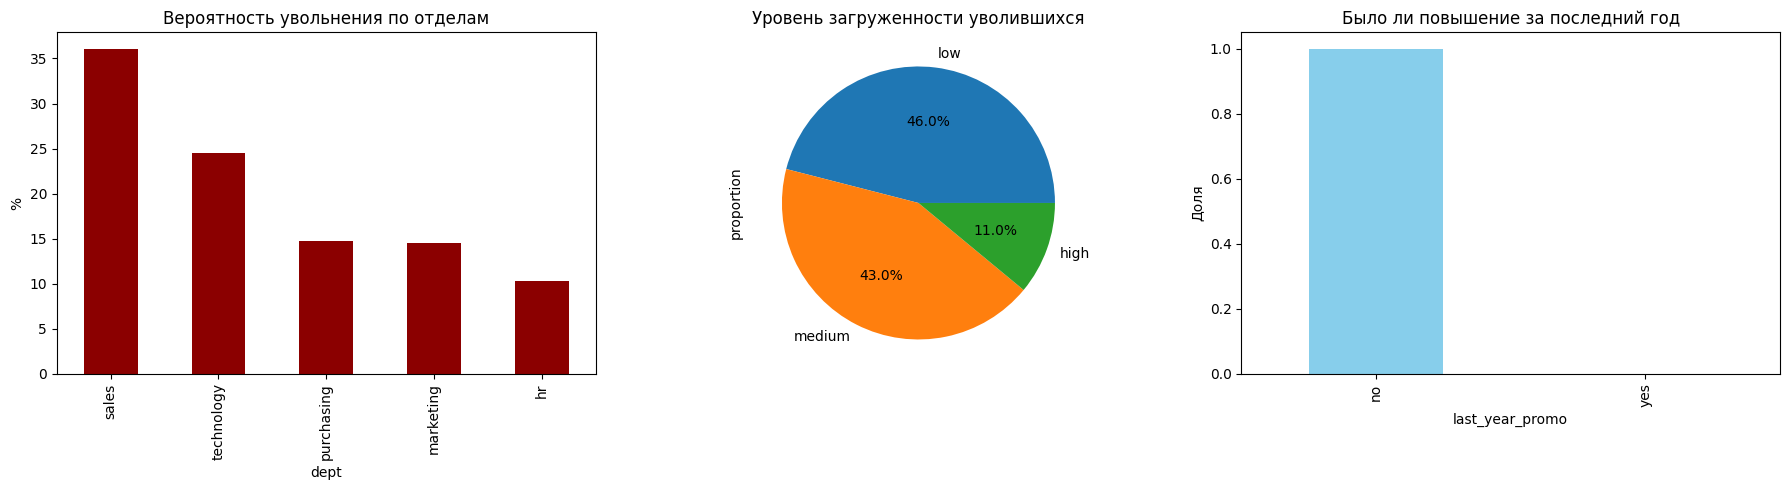

In [139]:
# Фильтруем только уволившихся сотрудников
left_employees = train_2_copy[train_2_copy['quit'] == 'yes']
work_employees = train_2_copy[train_2_copy['quit'] == 'no']

# 1. Анализ по отделам
dept_prob_left = (left_employees['dept'].value_counts(normalize=True) * 100).round(1)
print("Вероятность увольнения по отделам (%):")
display(dept_prob_left)

# 2. Уровень загруженности
workload_dist_left = left_employees['workload'].value_counts(normalize=True).round(2)
print("\nРаспределение уровня загруженности уволившихся:")
display(workload_dist_left)

# 3. Средние зарплаты
salary_comparison_left = pd.DataFrame({
    'Уволившиеся': [left_employees['salary'].mean()],
}).round(2)
print("\nСредние зарплаты уволившихся:")
display(salary_comparison_left)

salary_comparison_work = pd.DataFrame({
    'Оставшиеся': [work_employees['salary'].mean()],
}).round(2)
print("\nСредние зарплаты оставшихся:")
display(salary_comparison_work)

# 4. Уровень занимаемой должности
level_dist_left = left_employees['workload'].value_counts(normalize=True).round(2)
print("\nУровень занимаемой должности:")
display(level_dist_left)

# 5. Средняя длительность работы в компании (в годах)
employment_years_comparison_left = pd.DataFrame({
    'Уволившиеся': [left_employees['employment_years'].mean()],
}).round(2)
print("\nСредняя длительность работы в компании (в годах):")
display(employment_years_comparison_left)

employment_years_dist_left = left_employees['employment_years'].value_counts(normalize=True).sort_index().round(2)
print("\nРаспределение длительности работы уволившихся сотрудников в компании (в годах) (доли):")
display(employment_years_dist_left)

# 6. Было ли повышение за последний год
last_year_promo_dist_left = left_employees['last_year_promo'].value_counts(normalize=True).round(2)
print("\nРаспределение по признаку 'Было ли повышение за последний год' (доли):")
display(last_year_promo_dist_left)

# 7. Нарушал ли сотрудник трудовой договор за последний год
last_year_violations_dist_left = left_employees['last_year_violations'].value_counts(normalize=True).sort_index().round(2)
print("\nНарушал ли сотрудник трудовой договор за последний год (доли)':")
display(last_year_violations_dist_left)


# 8. Средняя оценка руководителем качества работы сотрудника (1-5)
supervisor_evaluation_comparison_left = pd.DataFrame({
    'Уволившиеся': [left_employees['supervisor_evaluation'].mean()],
}).round(2)
print("\nСредняя оценка руководителем качества работы сотрудника (1-5):")
display(supervisor_evaluation_comparison_left)
supervisor_eval_dist_left = left_employees['supervisor_evaluation'].value_counts(normalize=True).sort_index().round(2)
print("\nРаспределение оценок руководителя уволившихся сотрудников (доли):")
display(supervisor_eval_dist_left)


# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# График 1: Отделы
dept_prob_left.plot(kind='bar', ax=axes[0], color='darkred')
axes[0].set_title('Вероятность увольнения по отделам')
axes[0].set_ylabel('%')

# График 2: Загруженность
workload_dist_left.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
axes[1].set_title('Уровень загруженности уволившихся')

# График 3: Было ли повышение за последний год
last_year_promo_dist_left.plot(kind='bar', ax=axes[2], color='skyblue')
axes[2].set_title('Было ли повышение за последний год')
axes[2].set_ylabel('Доля')

plt.tight_layout()
plt.show()

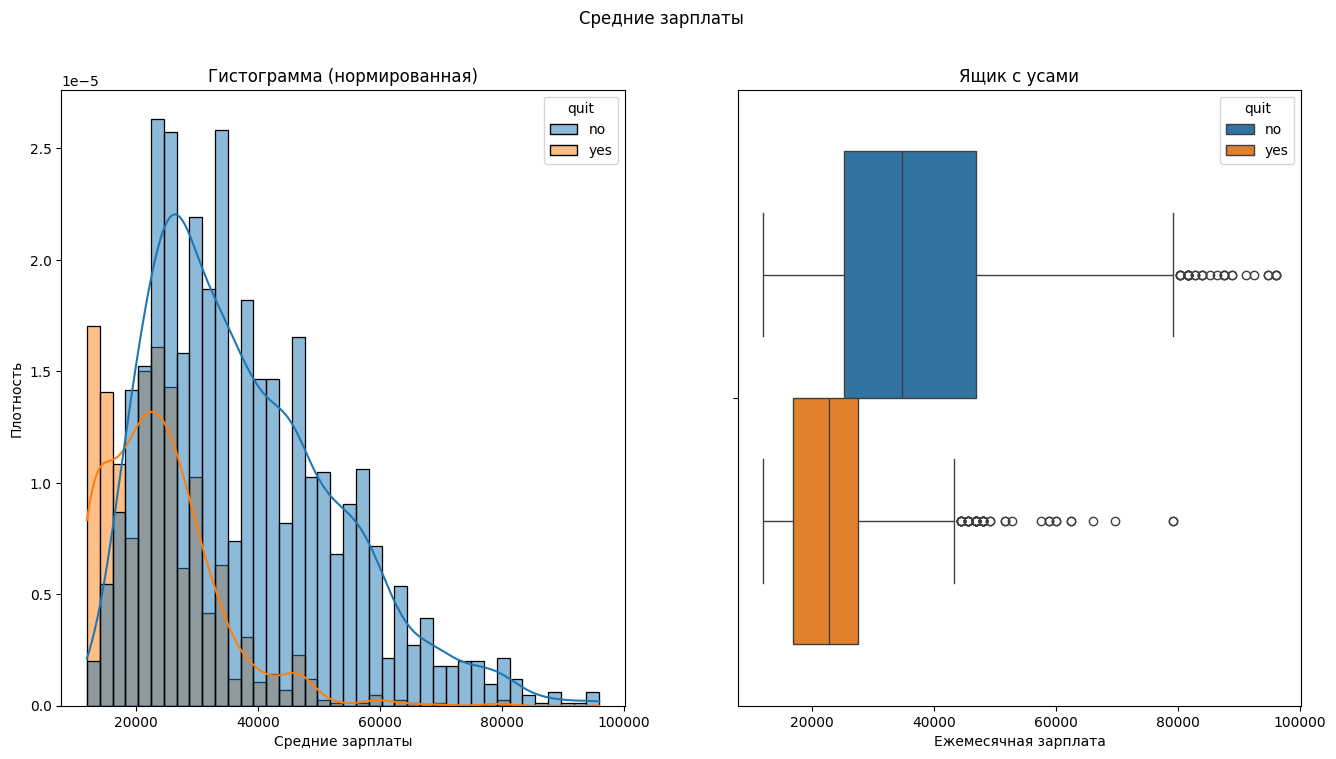

In [140]:
# График 4: Средняя зарплата
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16,8))

# Нормированная гистограмма (плотность)
sn.histplot(data=train_2_copy, x='salary', hue='quit', ax=axs[0], bins=40, kde=True, stat='density')
axs[0].set_xlabel('Средние зарплаты')
axs[0].set_ylabel('Плотность')
axs[0].set_title('Гистограмма (нормированная)')

# Ящик с усами
sn.boxplot(data=train_2_copy, x='salary', hue='quit', ax=axs[1])
axs[1].set_xlabel('Ежемесячная зарплата')
axs[1].set_title('Ящик с усами')

fig.suptitle('Средние зарплаты')
plt.show()

In [141]:
salary_dist_left = left_employees['salary'].value_counts(normalize=True).sort_index().round(2)
salary_dist_work = work_employees['salary'].value_counts(normalize=True).sort_index().round(2)

# Создаем DataFrame для уволившихся
salary_left_df = pd.DataFrame({'salary': salary_dist_left.index, 'share': salary_dist_left.values})

# Создаем DataFrame для оставшихся
salary_work_df = pd.DataFrame({'salary': salary_dist_work.index, 'share': salary_dist_work.values})

# Определяем диапазоны зарплат
bins = [0, 20000, 30000, 40000, 50000, float('inf')]
labels = ['до 20k', '20k-30k', '30k-40k', '40k-50k', 'более 50k']

# Для уволившихся
salary_left_df['salary_range'] = pd.cut(salary_left_df['salary'], bins=bins, labels=labels)
distribution_left_by_range = salary_left_df.groupby('salary_range')['share'].sum()

# Для работающих
salary_work_df['salary_range'] = pd.cut(salary_work_df['salary'], bins=bins, labels=labels)
distribution_work_by_range = salary_work_df.groupby('salary_range')['share'].sum()

# Объединяем в один DataFrame
result = pd.DataFrame({
    'Уволившиеся': distribution_left_by_range,
    'Оставшиеся': distribution_work_by_range
}).fillna(0)  # на случай отсутствия данных в каком-то диапазоне

print("Распределение зарплат по диапазонам (доли):")
display(result.round(2))

Распределение зарплат по диапазонам (доли):


/var/folders/nl/qb3_y6cj3lxgsxxz059t4t740000gn/T/ipykernel_3405/1196708108.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distribution_left_by_range = salary_left_df.groupby('salary_range')['share'].sum()
/var/folders/nl/qb3_y6cj3lxgsxxz059t4t740000gn/T/ipykernel_3405/1196708108.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  distribution_work_by_range = salary_work_df.groupby('salary_range')['share'].sum()


,Уволившиеся,Оставшиеся
salary_range,,
до 20k,0.38,0.08
20k-30k,0.47,0.30
30k-40k,0.12,0.23
40k-50k,0.06,0.16
более 50k,0.00,0.17


Увольняются восновном сотрудники, работающие в компании 1-2-3 года.

Увольняются изо всех отделов примерно в равных долях. При этом, увольнение наиболее вероятно из отдела продаж, меньше вероятность увольнения из технологического, еще меньше - у закупщиков и маркетинга, и самая маленькая вероятность, что уволятся из отдела кадров.

Увольняются при уровне зарплаты ниже отдельского на уровне сотрудника.

Увольняются при уровне зарплаты ниже, чем зарплаты на том же уровне в компании.

Увольняются при уровне зарплаты ниже, чем зарплаты у проработавших столько же лет.

Увольняются при при плохой оценке работы руководством.

Увольняются при зарплате ниже, чем на таком же уровне загрузки.

Повышения влияют на уход меньше, чем зарплата и оценка руководителя.

Загрузка у уволившихся больше у джунов и зарплата у них тоже ниже.

Средняя зарплата уволившихся на треть ниже, чем у неуволившихся сотрудников.

Увольняются сотрудники, имеющие удовлетворенность от своей работы ниже среднего балла.

**Резюме**

Увольняются сотрудники, обладающие на тех же условиях, меньшей зарплатой, низко оцениваемые своим руководством, не привлеченные к работе и не мотивированные интересом к ней.
Увольняются люди, для которых значения признаков из приведенного датасета хуже, чем у оставшихся работать.
В этом случае, я считаю, это большой промах руководства. Нанятых ими же сотрудников, они оценивают низко - обесценивают. Обесценивают сотрудников, а не свои компетенции по подбору кадров на собеседованиях, не свои руководительские навыки по заинтересованию и привлечению своих людей к работе. Высокий дисбаланс в зарплатах одинаковых сотрудников тоже кажется странно совмсетимым с вопросом "а почему уходят люди?".

### Добавление нового входного признака

In [142]:
train_2['job_satisfaction_rate'] = grid_search.best_estimator_.predict(train_2).round(2)
train_2.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
id,,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no,0.60
814010,sales,junior,medium,2,no,no,4,27600,no,0.85


In [143]:
X_test_2['job_satisfaction_rate'] = grid_search.best_estimator_.predict(X_test_2).round(2)
X_test_2.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
id,,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.88,no
686555,hr,junior,medium,1,no,no,4,30000,0.68,no


### Подготовка данных

In [144]:
train_2.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,quit,job_satisfaction_rate
id,,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,no,0.60
814010,sales,junior,medium,2,no,no,4,27600,no,0.85
155091,purchasing,middle,medium,5,no,no,1,37200,no,0.34
257132,sales,junior,medium,2,no,yes,3,24000,yes,0.34
910140,marketing,junior,medium,2,no,no,5,25200,no,0.69


In [145]:
train_2 = train_2.drop_duplicates()
train_2.shape[0]

2587

In [146]:
y_test_1

,job_satisfaction_rate
id,
100298,0.80
100480,0.84
100503,0.79
100610,0.75
100692,0.69
...,...
997290,0.79
998548,0.76
998762,0.48


In [147]:
y_test_2.head()

,quit
id,
999029,yes
372846,no
726767,no
490105,no
416898,yes


In [148]:
X_test_2.head(2)

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit
id,,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.88,no
686555,hr,junior,medium,1,no,no,4,30000,0.68,no


In [149]:
y_test_2.head(2)

,quit
id,
999029,yes
372846,no


В датасете присутствует дисбаланс классов.

In [150]:
X_test_2 = pd.concat([X_test_2, y_test_2], axis=1)
X_test_2.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate,quit,quit
id,,,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.88,no,no
686555,hr,junior,medium,1,no,no,4,30000,0.68,no,no
467458,sales,middle,low,5,no,no,4,19200,0.65,no,no
418655,sales,middle,low,6,no,no,4,19200,0.66,no,no
789145,hr,middle,medium,5,no,no,5,40800,0.81,no,no


In [151]:
X_test_2.isna().sum()

dept                     3
level                    1
workload                 1
employment_years         0
last_year_promo          0
last_year_violations     0
supervisor_evaluation    0
salary                   0
job_satisfaction_rate    0
quit                     0
quit                     0
dtype: int64

In [152]:
X_test_2.duplicated().sum()

504

In [153]:
X_test_2.shape

(2000, 11)

Пропуски удалим пайплайном. Дубликаты оставим - не повлю=ияют на обучение.

In [154]:
RANDOM_STATE = 42

# Создаём переменные для модели
y_train_2 = train_2['quit']
#y_test_2 = X_test_2['quit']
X_train_2 = train_2.drop(['quit'], axis=1)
X_test_2 = X_test_2.drop(['quit'], axis=1)

In [155]:
y_train_2

id
723290     no
814010     no
155091     no
257132    yes
910140     no
         ... 
778735    yes
106936     no
775320    yes
536432    yes
692133     no
Name: quit, Length: 2587, dtype: object

In [156]:
y_test_2

,quit
id,
999029,yes
372846,no
726767,no
490105,no
416898,yes
...,...
836109,yes
180999,yes
746018,no


In [157]:
X_train_2

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
723290,sales,middle,high,2,no,no,4,54000,0.60
814010,sales,junior,medium,2,no,no,4,27600,0.85
155091,purchasing,middle,medium,5,no,no,1,37200,0.34
257132,sales,junior,medium,2,no,yes,3,24000,0.34
910140,marketing,junior,medium,2,no,no,5,25200,0.69
...,...,...,...,...,...,...,...,...,...
778735,technology,junior,low,2,no,no,4,22800,0.84
106936,marketing,junior,low,1,no,no,5,18000,0.88
775320,technology,junior,high,1,no,no,4,42000,0.57


In [158]:
X_test_2

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.88
686555,hr,junior,medium,1,no,no,4,30000,0.68
467458,sales,middle,low,5,no,no,4,19200,0.65
418655,sales,middle,low,6,no,no,4,19200,0.66
789145,hr,middle,medium,5,no,no,5,40800,0.81
...,...,...,...,...,...,...,...,...,...
393147,marketing,junior,low,3,no,no,3,20400,0.51
109582,technology,middle,low,3,no,no,2,21600,0.15
305653,technology,junior,low,1,no,no,3,14400,0.17


In [159]:

# Используем кодировщик для целевого признака:
le = LabelEncoder()
y_train_2 = le.fit_transform(y_train_2)
y_test_2 = le.transform(y_test_2)

le.classes_ = np.array(['no', 'yes'])
classes = le.classes_
print("Соответствие классов и меток:")
print(dict(zip(le.classes_, le.transform(le.classes_))))

print(X_train_2.shape)
print(y_train_2.shape)
print(X_test_2.shape)
print(y_test_2.shape)

Соответствие классов и меток:
{'no': 0, 'yes': 1}
(2587, 9)
(2587,)
(2000, 9)
(2000,)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [160]:
# Создаём списки с названиями признаков
ohe_columns = ['dept', 'last_year_promo', 'last_year_violations'] # Признаки, которые невозможно упорядочить
ord_columns = ['level', 'workload'] # Признаки, которые можно ранжировать по какому-то критерию
num_columns = X_train_2.select_dtypes(include=['number']).columns

# Создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='ignore'))
    ]
    )

# Создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['junior', 'middle', 'sinior'],
                    ['high', 'low', 'medium'],
                ],
                handle_unknown='use_encoded_value', unknown_value=np.nan # Для обработки пропусков типа ' '
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

# Создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ],
    remainder='passthrough'
)

# Создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [161]:
# Проверяем, что все признаки обрабатываются корректно
X_transformed_2 = data_preprocessor.fit_transform(X_train_2)
print("Число признаков после обработки:", X_transformed_2.shape[1])
print("Пропуски после обработки:", np.isnan(X_transformed_2).sum())

Число признаков после обработки: 12
Пропуски после обработки: 0


### Обучение модели

Обучим три модели. Для двух из них подберем гиперпараметры. Проверим качество лучшей модели. Метрика оценки качества в этой задаче — ROC-AUC. Критерий успеха: ROC-AUC≥0.91 на тестовой выборке.

In [162]:
param_grid = [
    # Словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 5),
        'models__max_features': range(2, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },
    # Словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE,
            solver='liblinear',
            penalty='l1'
        )],
        'models__C': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },

    # Словарь для модели KNeighborsClassifier()
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(1, 5),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    },

    # Словарь для модели SVC()
    {
       'models': [SVC(random_state=RANDOM_STATE, probability=True)], # probability=True for predict_proba
       'models__C': range(1, 5),
       'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']
    }
]


In [163]:
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    n_iter=50,  # Количество комбинаций
    cv=5,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1
)


In [164]:
randomized_search.fit(X_train_2, y_train_2)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first',
                                                                                                              handle_unknown='ignore'))]),
                                                                               ['dept',
                                                                                'last_year_promo',
                                                                                'last_year_violations']),
                                                                              ('ord',
                                                                               Pipeline(steps=[('simpl...
                                                               'passthrough']},
                                        {'models': [KNeighborsClassifier()],
                                         'models__n_neighbors': range(1, 5),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']},
                                        {'models': [SVC(probability=True,
                                                        random_state=42)],
                                         'models__C': range(1, 5),
                                         'preprocessor__num': [StandardScaler(),
                                                               MinMaxScaler(),
                                                               RobustScaler(),
                                                               'passthrough']}],
                   random_state=42, scoring='roc_auc')

In [165]:
y_test_2.shape

(2000,)

In [166]:
X_test_2.shape

(2000, 9)

In [167]:
y_test_2

array([1, 0, 0, ..., 0, 0, 1])

In [168]:
X_test_2.head()

,dept,level,workload,employment_years,last_year_promo,last_year_violations,supervisor_evaluation,salary,job_satisfaction_rate
id,,,,,,,,,
485046,marketing,junior,medium,2,no,no,5,28800,0.88
686555,hr,junior,medium,1,no,no,4,30000,0.68
467458,sales,middle,low,5,no,no,4,19200,0.65
418655,sales,middle,low,6,no,no,4,19200,0.66
789145,hr,middle,medium,5,no,no,5,40800,0.81


In [169]:
# Проверяем на тестовой выборке
y_pred_test_2 = randomized_search.best_estimator_.predict_proba(X_test_2)[:, 1]
roc_auc = roc_auc_score(y_test_2, y_pred_test_2)

# Задаем условие roc_auc >= 0.91
if roc_auc >= 0.91:
    print(f"Успех! Roc_auc на тестовой выборке = {roc_auc:.3f}")
    print(f"Метрика лучшей модели на кросс-валидации: {randomized_search.best_score_:.3f}")
    print("Лучшая модель:", randomized_search.best_estimator_)
else:
    print(f"Неудача. Roc_auc на тестовой выборке = {roc_auc:.2f}. Продолжаем подбор...")
    print(f"Метрика лучшей модели на кросс-валидации: {randomized_search.best_score_:.3f}")
    print("Лучшая модель:", randomized_search.best_estimator_)

Неудача. Roc_auc на тестовой выборке = 0.49. Продолжаем подбор...
Метрика лучшей модели на кросс-валидации: 0.912
Лучшая модель: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['dept', 'last_year_promo',
                                                   'last_year_violations']),
                                                 ('ord',
                                 

Нет переобучения: Разница между кросс-валидацией и тестом всего 0.005 — модель обобщает данные, а не запоминает их.

In [170]:
# Обучение и оценка DummyClassifier
dummy_сlassifier = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)  # Или "most_frequent", "prior", "uniform"
dummy_сlassifier.fit(X_train_2, y_train_2)
dummy_pred_proba = dummy_сlassifier.predict_proba(X_test_2)[:,1]
auc_dummy = roc_auc_score(y_test_2, dummy_pred_proba)
print(f"AUC-ROC DummyClassifier: {auc_dummy}")

AUC-ROC DummyClassifier: 0.5049709595211285


Зачем нужен DummyClassifier?

Базовый уровень: сравнение с ним показывает, что модель действительно учится.

Отладка: проверка корректности пайплайна.

Тестирование: например, для проверки метрик на "простом" классификаторе.

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      1436
           1       0.28      0.28      0.28       564

    accuracy                           0.60      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.60      0.60      0.60      2000



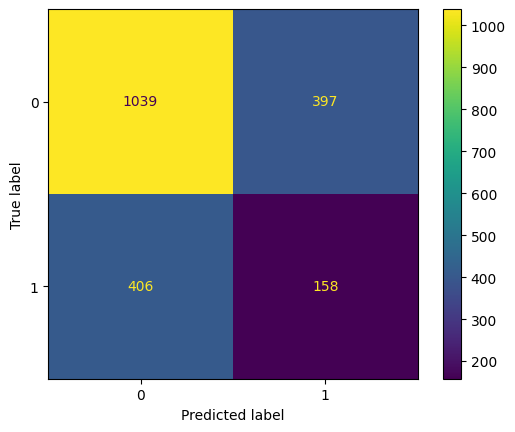

In [171]:
# Для бинарной классификации полезно посмотреть precision/recall
y_test_pred = randomized_search.best_estimator_.predict(X_test_2)
print(classification_report(y_test_2, y_test_pred))

# Матрица ошибок
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test_2, y_test_pred)
plt.show()

Уходящих сотрудников модель распознает в 457 случаях их 564. и в 98 случаях ошибется - сотрудник не уходит, но модель выберет его.

In [172]:
# Сохранение модели
import joblib
joblib.dump(randomized_search.best_estimator_, 'randomized_search.best_estimator_.pkl')

['randomized_search.best_estimator_.pkl']

**Лучшая модель** - LogisticRegression(C=3, penalty='l1', random_state=42)

**Лучшая метрика** = 0.917, что больше заданного критерия успеха - успех.

In [173]:
y_predict_proba = randomized_search.predict_proba(X_test_2)
y_predict_proba

array([[0.86675046, 0.13324954],
       [0.70933003, 0.29066997],
       [0.93595547, 0.06404453],
       ...,
       [0.05097483, 0.94902517],
       [0.95982215, 0.04017785],
       [0.90763417, 0.09236583]])

### Выводы

Найдена и обучена лучшая модель по предсказанию увольнения сотрудника. Значение метрики ROC-AUC на тестовой выборке = 0.917, что является успехом, тк критерий успеха: ROC-AUC ≥ 0.91 на тестовой.

**Обоснование выбора метрики**

**ROC-AUC** (Area Under the Receiver Operating Characteristic Curve) — метрика, которая оценивает модель по двум ключевым аспектам:

True Positive Rate, TPR — доля верно предсказанных "уволится".

False Positive Rate, FPR — доля ошибочных предсказаний для неувольняющихся.

**Преимущества:**

Устойчивость к дисбалансу классов. ROC-AUC не требует балансировки данных.

Оценка вероятностей. Метрика учитывает не только бинарные предсказания, но и вероятности (predict_proba), что важно для ранжирования работников по риску.

Интерпретируемость:

AUC = 0.5 — модель не лучше случайного угадывания.

AUC > 0.7 — хорошее качество.

**AUC > 0.9 — отличное качество.**

Модель получилась отличного качества.

Лучшая модель -   LogisticRegression(C=3, penalty='l1', random_state=42). Данная модель справилась лучше остальных.

## Общий вывод

**Оприсание задачи**

**Цель 1 выполнена** — построена модель, которая предсказывает уровень удовлетворённости сотрудника на основе данных заказчика.

В задаче 1 подготовлены данные, предложены модели МО, созданы пайплайны, модели обучены по предоставленным данным, целевой призкак - удовлетворенность сотрудников работой. Была предложена метрика smape. Она выбрана лучшей. МО посчитала лучшей моделью DecisionTreeRegressor. Значение метрики на тестовой выборке получилось меньше заданного порога: 13.991 < 15. Данная модель справилась лучше линейной регрессии, тк зависимости между признаками имеют нелинейный характер. Найдены предсказываемые вероятности удовлетворенности сотрудниками своей работой.

**Цель 2 выполнена** — построена модель, которая на основе данных заказчика предсказывает то, что сотрудник уволится из компании.

Найдена и обучена лучшая модель по предсказанию увольнения сотрудника. Лучшая модель -   LogisticRegression(C=3, penalty='l1', random_state=42). Данная модель справилась лучше остальных. Значение метрики ROC-AUC на тестовой выборке = 0.917, что является успехом, тк критерий успеха: ROC-AUC ≥ 0.91 на тестовой.

**Рекомендации бизнесу**
- кадрам и руководителям тщательнее отбирать сотрудников для последующей лучшей удовлетворенности сотрудниками и руководством друг другом.
- провести перераспределение зарплат сотрудников, не обделяя людей, работающих на одинаковом уровне, с одинаковой загрузкой.
- проводить повышения и индексацию.
- использовать в работе подход менеджмента качества 6 сигма, где после пвременных проимежутков беседовать с сотрудниками и руководителями что им нравится, что нет, чего хотелось бы - менять что не нравится в лучшую сторону, через временной промежуток снова проводить опрос.
- рекомендую смотреть и перенимать положительные подходы к работе в схожих компаниях и компаниях, в которых сотрудники удовлетворены работой - например, с тем же яндексом.
- рекомендую заинтересовывать сотрудников работой, а руководство рекомендую обучать управлению командами, дабы не оценивать своих сотрудников, как низкокачественных. Работать над собой и обучать сотрудников.
- рекомендую свыше спускать цель компании - создаем продукт Х... Для его создания нужно то, то и то, этой задачей занимается отдел... на входе в отдел ..., на выходе хотим получить ... и так по всем отделам и это должно быть услышано каждым сотрудником. Также - сроки и тд. Чтобы сотрудники не ковыряли минизадачу, а выполняли свой вклад для глобальной цели и чувствовали свою ценность, а также - правильно технически делали свою работу. нельзя лелать колесо просто, не зная глобальную цель - оно для велосипеда или для авто.
- всегда необходима система мотивации и человеческого отношения к сотрудникам.
- рекомендую качественнос работать с пришедшими сотрудниками, дабы обучать новых - это отнимать время у текущих, новые тоже не сразу начинают приносить бизнесу деньги. Сейчас бизнес теряет доходы - обучает новых сотрудников, они быстро уходят и тратят доходы на наем и обучение новых. Это не правильно.
- по выданным датафрэймам видно отсутствие повышений сотрудников. Каждый человек хочет развиваться как профессионально6 так и карьерно, денежно, подучать допкомпетенции - необходимо повышать и развивать своих сотрудников.